In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import nc_time_axis 
import cftime


In [2]:
import matplotlib.pyplot as plt
def grafico_linea_ts(xmin,xmax,xlab,ylab,title,ymin=None,ymax=None,legend=False):
    # especificar limites minimos y maximos del grafico
    plt.xlim([xmin,xmax])
    plt.ylim([ymin,ymax])
    # cuadrilla interna del grafico
    plt.grid(linestyle='--',alpha=0.66)
    plt.minorticks_on()
    # hacer las etiquetas de ambos ejes mas grandes
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    # poner las labels de los ejes y el titulo
    plt.xlabel(xlab,fontsize=10)
    plt.ylabel(ylab,fontsize=10)
    plt.title(title,fontsize=10)
    # checar si queremos leyenda, si sí, la ponemos y fancy
    if legend:
        plt.legend(fontsize=10,fancybox=True,shadow=True)

In [3]:
## Carga del archivo de X 1 de CO2
pr1= xr.open_dataset('pr_1xCO2_run_cesm1-lens_1850-1999.nc')

In [4]:
pr1


<xarray.Dataset> Size: 598MB
Dimensions:     (year: 150, lat: 192, lon: 288)
Coordinates:
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 1996 1997 1998 1999
  * lat         (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon         (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables:
    pr          (year, lat, lon) float64 66MB ...
    pr_djf      (year, lat, lon) float64 66MB ...
    pr_jja      (year, lat, lon) float64 66MB ...
    pr_max      (year, lat, lon) float64 66MB ...
    pr_max_djf  (year, lat, lon) float64 66MB ...
    pr_max_jja  (year, lat, lon) float64 66MB ...
    tas         (year, lat, lon) float64 66MB ...
    tas_djf     (year, lat, lon) float64 66MB ...
    tas_jja     (year, lat, lon) float64 66MB ...
    weight      (lat, lon) float64 442kB ...

In [5]:
pr1['year'] = [pd.Timestamp(str(t)) for t in pr1['year'].values]
pr1['pr']
##Cambio de float64 a float32 para una mejor lectura de los datos

pr1['pr'] = pr1['pr'].astype('float32')

year=pr1['year']


precip1=pr1.pr

### Cambio de longitud a un formato de -180 a 180
precip1 = precip1.assign_coords(lon=((precip1.lon + 180) % 360) - 180).sortby('lon')

# Delimitación del periodo de estudio
#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
precip1=precip1.sel(year=slice("1969-01-01", "1999-01-01"))
p1 = precip1.sel(lon=slice(-120, -90), lat=slice(15, 40))

ANUAL=p1.mean(("year"), skipna= True)

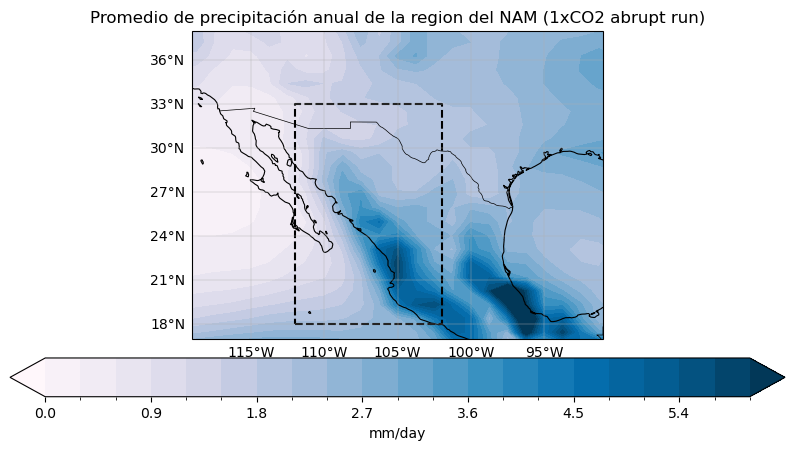

In [6]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = ANUAL.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip1.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual de la region del NAM (1xCO2 abrupt run)")
plt.show()

In [7]:
pr1['pr_jja'] = pr1['pr_jja'].astype('float32')
precip1_jja=pr1.pr_jja
precip1_jja = precip1_jja.assign_coords(lon=((precip1_jja.lon + 180) % 360) - 180).sortby('lon')


#precip1_jja= precip1_jja.where((year >= 1970) & (year <= 1999), drop=True)
precip1_jja=precip1_jja.sel(year=slice("1969-01-01", "1999-01-01"))
p1_jja = precip1_jja.sel(lon=slice(-120, -90), lat=slice(15, 40))
JJA_1=p1_jja.mean(("year"), skipna= True)

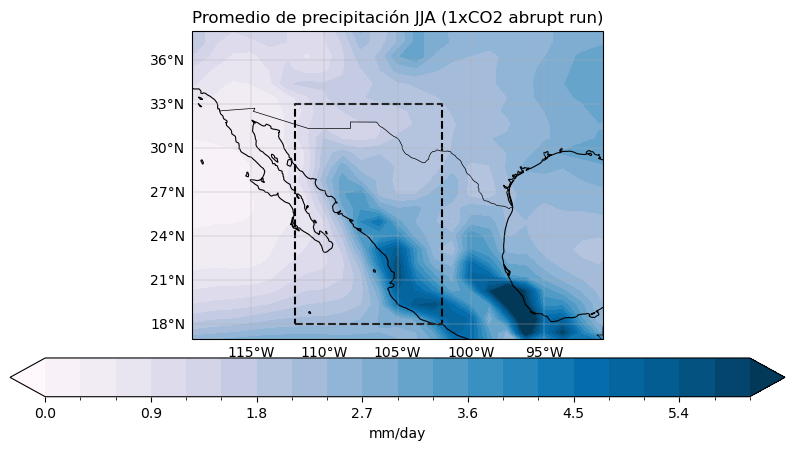

In [8]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = JJA_1.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=p1_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (1xCO2 abrupt run)")
plt.show()

In [9]:
pr2= xr.open_dataset('pr_2xCO2_run_cesm1-lens_1850-1999.nc')
pr2['year'] = [pd.Timestamp(str(t)) for t in pr2['year'].values]
pr2['pr']
##Cambio de float64 a float32 para una mejor lectura de los datos

pr2['pr'] = pr2['pr'].astype('float32')

year=pr2['year']


precip2=pr2.pr

### Cambio de longitud a un formato de -180 a 180
precip2 = precip2.assign_coords(lon=((precip2.lon + 180) % 360) - 180).sortby('lon')

# Delimitación del periodo de estudio
#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
precip2=precip2.sel(year=slice("1969-01-01", "1999-01-01"))
p2 = precip2.sel(lon=slice(-120, -90), lat=slice(16, 40))

ANUAL2=p2.mean(("year"), skipna= True)

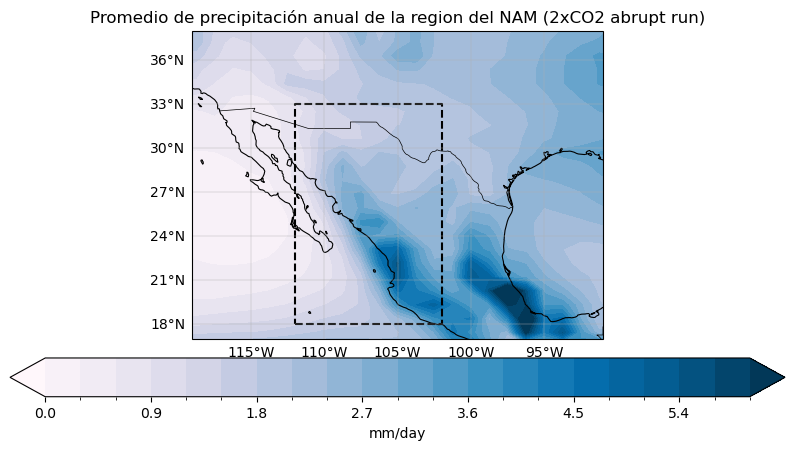

In [10]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = ANUAL2.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip2.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual de la region del NAM (2xCO2 abrupt run)")
plt.show()

In [11]:
pr2['pr_jja'] = pr2['pr_jja'].astype('float32')
precip2_jja=pr2.pr_jja
precip2_jja = precip2_jja.assign_coords(lon=((precip2_jja.lon + 180) % 360) - 180).sortby('lon')


#precip1_jja= precip1_jja.where((year >= 1970) & (year <= 1999), drop=True)
precip2_jja=precip2_jja.sel(year=slice("1969-01-01", "1999-01-01"))
p2_jja = precip2_jja.sel(lon=slice(-120, -90), lat=slice(16, 40))
JJA_2=p2_jja.mean(("year"), skipna= True)

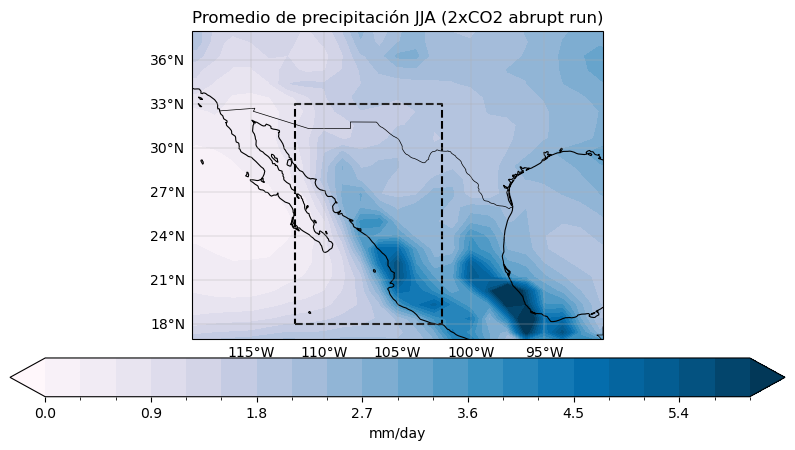

In [12]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = JJA_2.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=p2_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (2xCO2 abrupt run)")
plt.show()


In [13]:
pr3= xr.open_dataset('pr_3xCO2_run_cesm1-lens_1850-1999.nc')
pr3['year'] = [pd.Timestamp(str(t)) for t in pr3['year'].values]
pr3['pr']
##Cambio de float64 a float32 para una mejor lectura de los datos

pr3['pr'] = pr3['pr'].astype('float32')

year=pr3['year']


precip3=pr3.pr

### Cambio de longitud a un formato de -180 a 180
precip3 = precip3.assign_coords(lon=((precip3.lon + 180) % 360) - 180).sortby('lon')

# Delimitación del periodo de estudio
#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
precip3=precip3.sel(year=slice("1969-01-01", "1999-01-01"))
p3 = precip3.sel(lon=slice(-120, -90), lat=slice(16, 40))

ANUAL3=p3.mean(("year"), skipna= True)

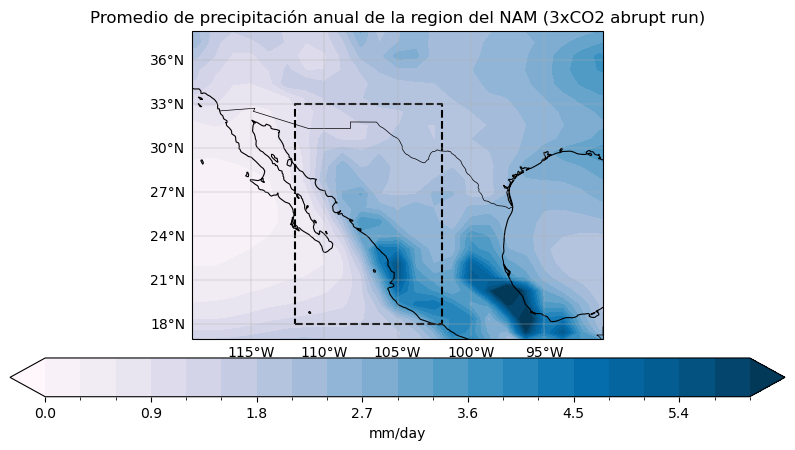

In [14]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = ANUAL3.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip3.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual de la region del NAM (3xCO2 abrupt run)")
plt.show()

In [15]:
pr3['pr_jja'] = pr3['pr_jja'].astype('float32')
precip3_jja=pr3.pr_jja
precip3_jja = precip3_jja.assign_coords(lon=((precip3_jja.lon + 180) % 360) - 180).sortby('lon')


#precip1_jja= precip1_jja.where((year >= 1970) & (year <= 1999), drop=True)
precip3_jja=precip3_jja.sel(year=slice("1969-01-01", "1999-01-01"))
p3_jja = precip3_jja.sel(lon=slice(-120, -90), lat=slice(16, 40))
JJA_3=p3_jja.mean(("year"), skipna= True)

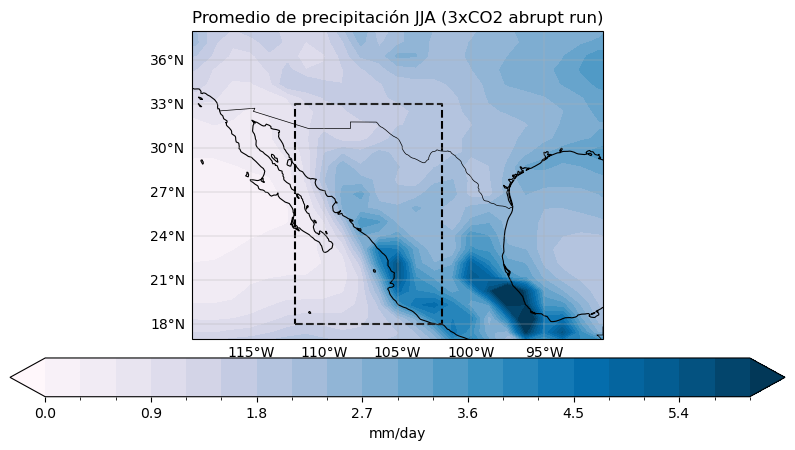

In [16]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = JJA_3.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=p3_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (3xCO2 abrupt run)")
plt.show()

In [17]:
pr4= xr.open_dataset('pr_4xCO2_run_cesm1-lens_1850-1999.nc')
pr4['year'] = [pd.Timestamp(str(t)) for t in pr4['year'].values]
pr4['pr']
##Cambio de float64 a float32 para una mejor lectura de los datos

pr4['pr'] = pr4['pr'].astype('float32')

precip4=pr4.pr

### Cambio de longitud a un formato de -180 a 180
precip4 = precip4.assign_coords(lon=((precip4.lon + 180) % 360) - 180).sortby('lon')

# Delimitación del periodo de estudio
#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
precip4=precip4.sel(year=slice("1969-01-01", "1999-01-01"))
p4 = precip4.sel(lon=slice(-120, -90), lat=slice(16, 40))

ANUAL4=p4.mean(("year"), skipna= True)

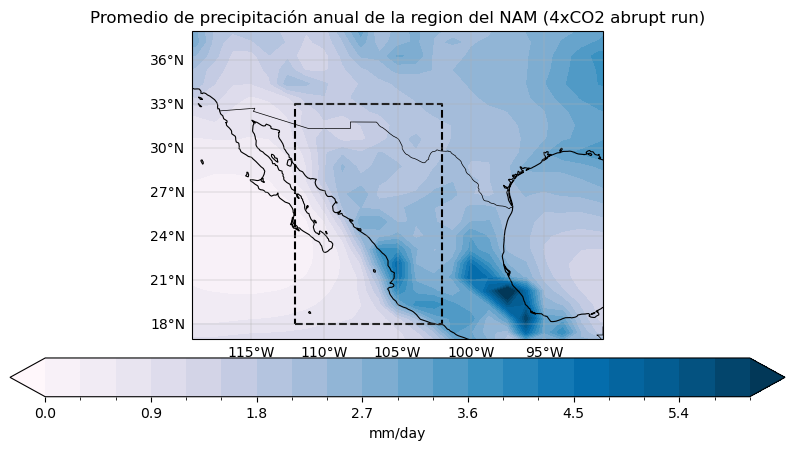

In [18]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = ANUAL4.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip4.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual de la region del NAM (4xCO2 abrupt run)")
plt.show()

In [19]:
pr4['pr_jja'] = pr4['pr_jja'].astype('float32')
precip4_jja=pr4.pr_jja
precip4_jja = precip4_jja.assign_coords(lon=((precip4_jja.lon + 180) % 360) - 180).sortby('lon')


#precip1_jja= precip1_jja.where((year >= 1970) & (year <= 1999), drop=True)
precip4_jja=precip4_jja.sel(year=slice("1969-01-01", "1999-01-01"))
p4_jja = precip4_jja.sel(lon=slice(-120, -90), lat=slice(16, 40))
JJA_4=p4_jja.mean(("year"), skipna= True)

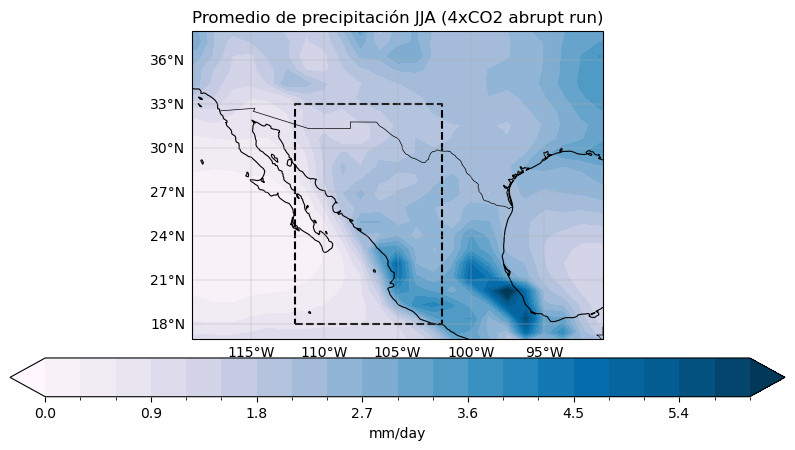

In [20]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = JJA_4.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=p4_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (4xCO2 abrupt run)")
plt.show()


In [21]:
pr5= xr.open_dataset('pr_5xCO2_run_cesm1-lens_1850-1999.nc')
pr5['year'] = [pd.Timestamp(str(t)) for t in pr5['year'].values]
pr5['pr']
##Cambio de float64 a float32 para una mejor lectura de los datos

pr5['pr'] = pr5['pr'].astype('float32')

precip5=pr5.pr

### Cambio de longitud a un formato de -180 a 180
precip5 = precip5.assign_coords(lon=((precip5.lon + 180) % 360) - 180).sortby('lon')

# Delimitación del periodo de estudio
#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
precip5=precip5.sel(year=slice("1969-01-01", "1999-01-01"))
p5 = precip5.sel(lon=slice(-120, -90), lat=slice(16, 40))

ANUAL5=p5.mean(("year"), skipna= True)

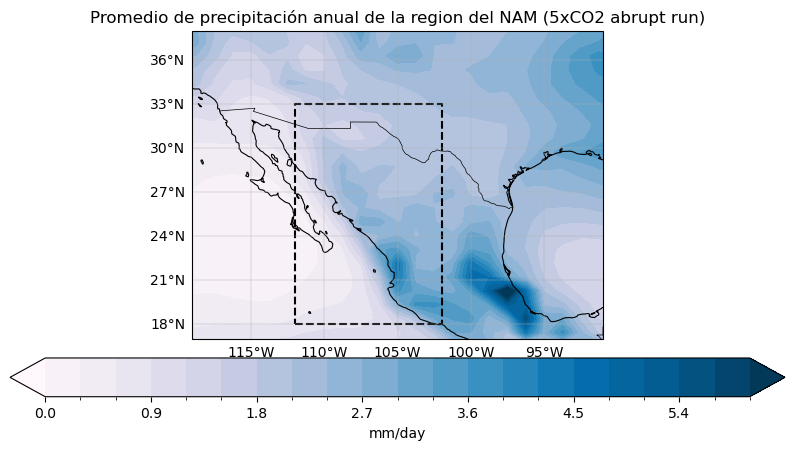

In [22]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = ANUAL5.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip5.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual de la region del NAM (5xCO2 abrupt run)")
plt.show()

In [23]:
pr5['pr_jja'] = pr5['pr_jja'].astype('float32')
precip5_jja=pr5.pr_jja
precip5_jja = precip5_jja.assign_coords(lon=((precip5_jja.lon + 180) % 360) - 180).sortby('lon')


#precip1_jja= precip1_jja.where((year >= 1970) & (year <= 1999), drop=True)
precip5_jja=precip5_jja.sel(year=slice("1969-01-01", "1999-01-01"))
p5_jja = precip5_jja.sel(lon=slice(-120, -90), lat=slice(16, 40))
JJA_5=p5_jja.mean(("year"), skipna= True)

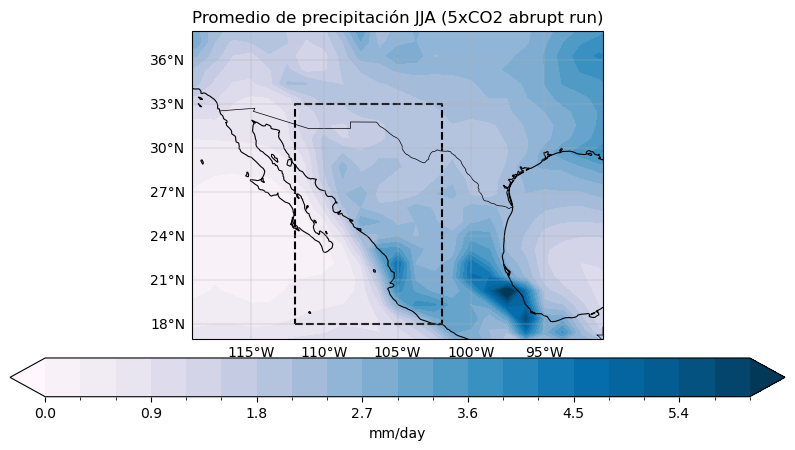

In [24]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = JJA_5.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=p5_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (5xCO2 abrupt run)")
plt.show()

In [25]:
pr6= xr.open_dataset('pr_6xCO2_run_cesm1-lens_1850-1999.nc')
pr6['year'] = [pd.Timestamp(str(t)) for t in pr6['year'].values]
pr6['pr']
##Cambio de float64 a float32 para una mejor lectura de los datos

pr6['pr'] = pr6['pr'].astype('float32')

precip6=pr6.pr

### Cambio de longitud a un formato de -180 a 180
precip6 = precip6.assign_coords(lon=((precip6.lon + 180) % 360) - 180).sortby('lon')

# Delimitación del periodo de estudio
#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
precip6=precip6.sel(year=slice("1969-01-01", "1999-01-01"))
p6 = precip6.sel(lon=slice(-120, -90), lat=slice(16, 40))

ANUAL6=p6.mean(("year"), skipna= True)

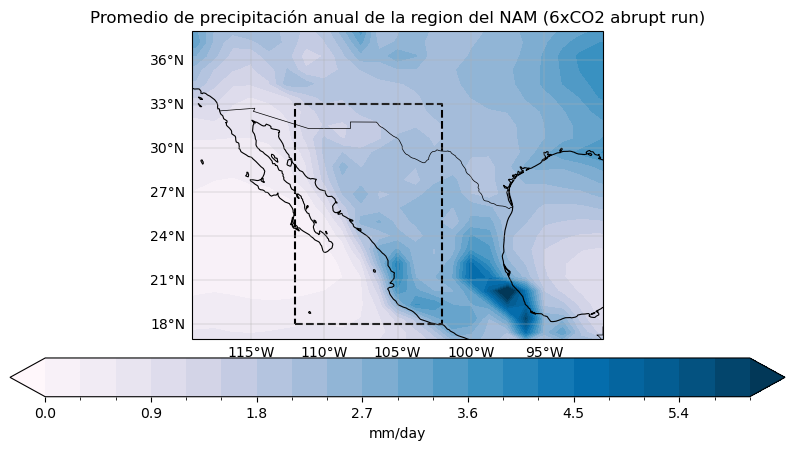

In [26]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = ANUAL6.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip6.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual de la region del NAM (6xCO2 abrupt run)")
plt.show()

In [27]:
pr6['pr_jja'] = pr6['pr_jja'].astype('float32')
precip6_jja=pr6.pr_jja
precip6_jja = precip6_jja.assign_coords(lon=((precip6_jja.lon + 180) % 360) - 180).sortby('lon')


#precip1_jja= precip1_jja.where((year >= 1970) & (year <= 1999), drop=True)
precip6_jja=precip6_jja.sel(year=slice("1969-01-01", "1999-01-01"))
p6_jja = precip6_jja.sel(lon=slice(-120, -90), lat=slice(16, 40))
JJA_6=p6_jja.mean(("year"), skipna= True)

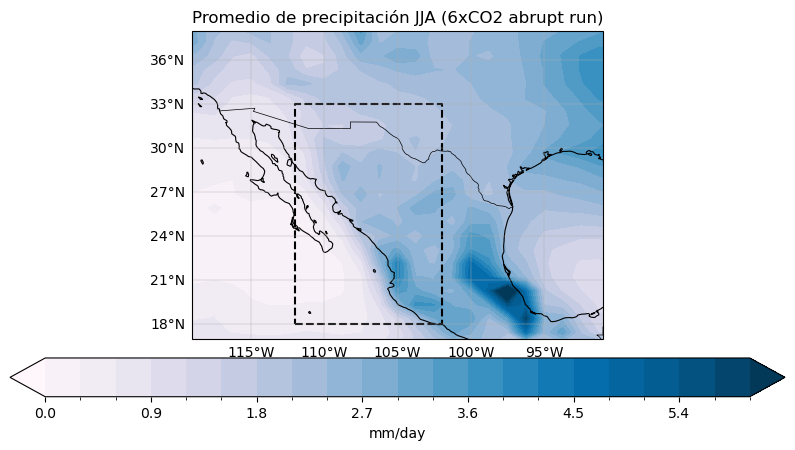

In [28]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = JJA_6.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=p6_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (6xCO2 abrupt run)")
plt.show()

In [29]:
pr7= xr.open_dataset('pr_7xCO2_run_cesm1-lens_1850-1999.nc')
pr7['year'] = [pd.Timestamp(str(t)) for t in pr7['year'].values]
pr7['pr']
##Cambio de float64 a float32 para una mejor lectura de los datos

pr7['pr'] = pr7['pr'].astype('float32')

precip7=pr7.pr

### Cambio de longitud a un formato de -180 a 180
precip7 = precip7.assign_coords(lon=((precip7.lon + 180) % 360) - 180).sortby('lon')

# Delimitación del periodo de estudio
#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
precip7=precip7.sel(year=slice("1969-01-01", "1999-01-01"))
p7 = precip7.sel(lon=slice(-120, -90), lat=slice(16, 40))

ANUAL7=p7.mean(("year"), skipna= True)

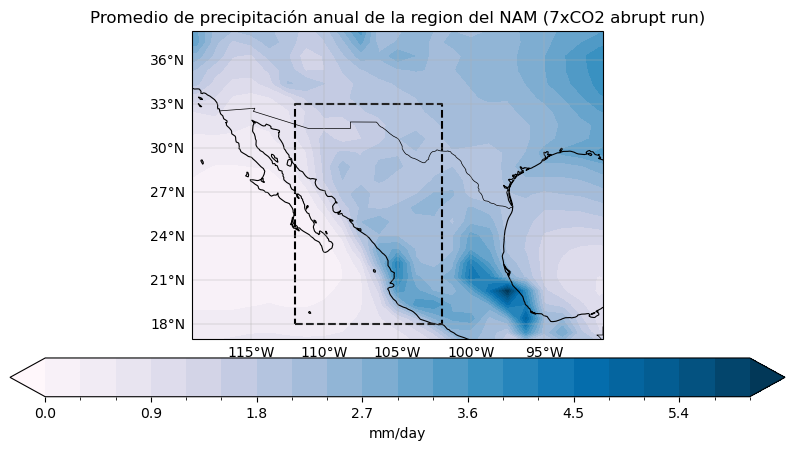

In [30]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = ANUAL7.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip7.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual de la region del NAM (7xCO2 abrupt run)")
plt.show()

In [31]:
pr7['pr_jja'] = pr7['pr_jja'].astype('float32')
precip7_jja=pr7.pr_jja
precip7_jja = precip7_jja.assign_coords(lon=((precip7_jja.lon + 180) % 360) - 180).sortby('lon')


#precip1_jja= precip1_jja.where((year >= 1970) & (year <= 1999), drop=True)
precip7_jja=precip7_jja.sel(year=slice("1969-01-01", "1999-01-01"))
p7_jja = precip7_jja.sel(lon=slice(-120, -90), lat=slice(16, 40))
JJA_7=p7_jja.mean(("year"), skipna= True)

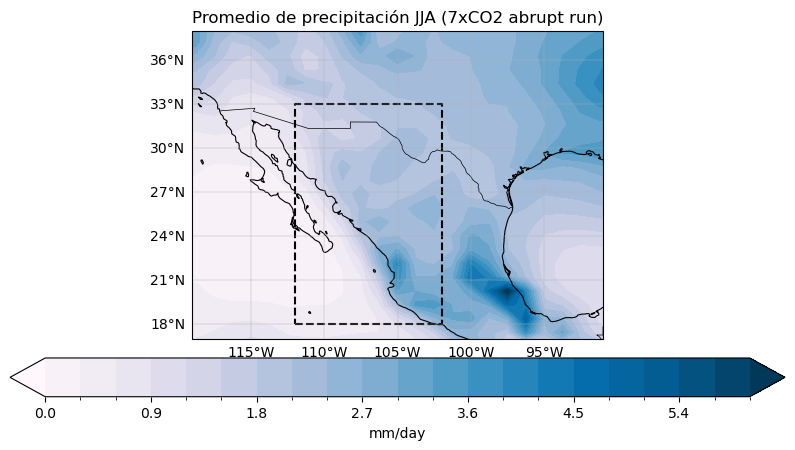

In [32]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = JJA_7.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=p7_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (7xCO2 abrupt run)")
plt.show()

In [33]:
pr8= xr.open_dataset('pr_8xCO2_run_cesm1-lens_1850-1999.nc')
pr8['year'] = [pd.Timestamp(str(t)) for t in pr8['year'].values]
pr8['pr']
##Cambio de float64 a float32 para una mejor lectura de los datos

pr8['pr'] = pr8['pr'].astype('float32')

precip8=pr8.pr

### Cambio de longitud a un formato de -180 a 180
precip8 = precip8.assign_coords(lon=((precip8.lon + 180) % 360) - 180).sortby('lon')

# Delimitación del periodo de estudio
#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
precip8=precip8.sel(year=slice("1969-01-01", "1999-01-01"))
p8 = precip8.sel(lon=slice(-120, -90), lat=slice(16, 40))

ANUAL8=p8.mean(("year"), skipna= True)

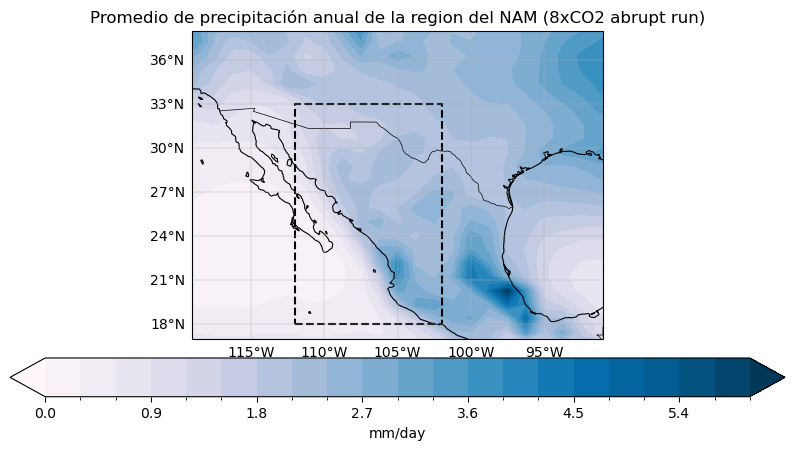

In [34]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = ANUAL8.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip8.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual de la region del NAM (8xCO2 abrupt run)")
plt.show()

In [35]:
pr8['pr_jja'] = pr8['pr_jja'].astype('float32')
precip8_jja=pr8.pr_jja
precip8_jja = precip8_jja.assign_coords(lon=((precip8_jja.lon + 180) % 360) - 180).sortby('lon')


#precip1_jja= precip1_jja.where((year >= 1970) & (year <= 1999), drop=True)
precip8_jja=precip8_jja.sel(year=slice("1969-01-01", "1999-01-01"))
p8_jja = precip8_jja.sel(lon=slice(-120, -90), lat=slice(16, 40))
JJA_8=p8_jja.mean(("year"), skipna= True)

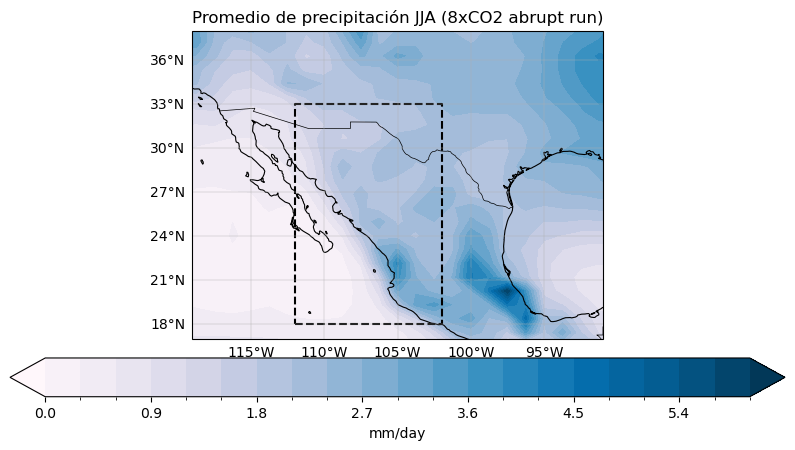

In [36]:
levels = np.linspace(0, 6, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = JJA_8.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=p8_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (8xCO2 abrupt run)")
plt.show()

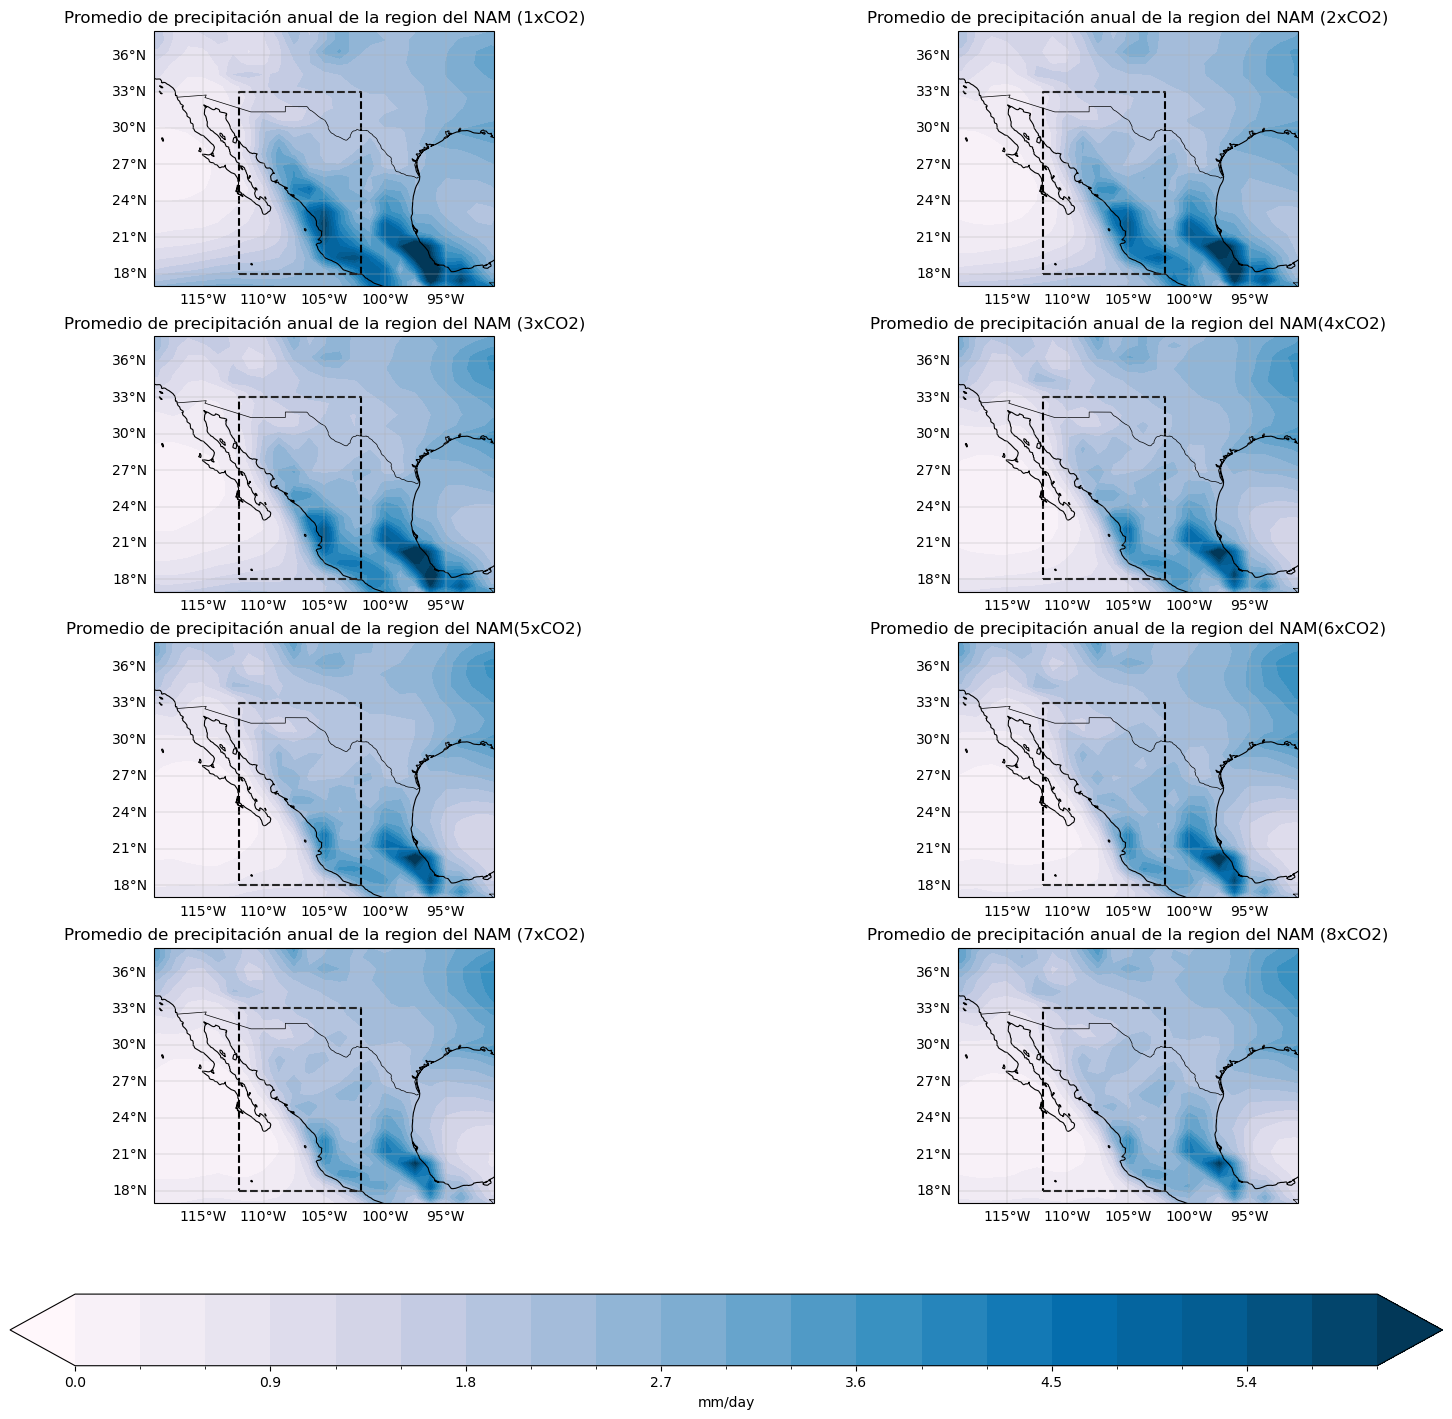

In [37]:
levels = np.linspace(0, 6, 21)

fig, axes = plt.subplots(
    4, 2,
    figsize=(16,14),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

datasets = [ANUAL, ANUAL2, ANUAL3, ANUAL4, ANUAL5, ANUAL6, ANUAL7, ANUAL8]

titles = [
    "Promedio de precipitación anual de la region del NAM (1xCO2)",
    "Promedio de precipitación anual de la region del NAM (2xCO2)",
    "Promedio de precipitación anual de la region del NAM (3xCO2)",
    "Promedio de precipitación anual de la region del NAM(4xCO2)",
    "Promedio de precipitación anual de la region del NAM(5xCO2)",
    "Promedio de precipitación anual de la region del NAM(6xCO2)",
    "Promedio de precipitación anual de la region del NAM (7xCO2)",
    "Promedio de precipitación anual de la region del NAM (8xCO2)"
]

for ax, data, title in zip(axes, datasets, titles):

    ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

    cf = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap="PuBu",
        add_colorbar=False,
        extend="both"
    )

# Rectángulo NAM
    ax.plot(
        [-112, -102, -102, -112, -112],
        [18, 18, 33, 33, 18],
        transform=ccrs.PlateCarree(),
        linestyle="--",
        linewidth=1.5,
        color="k"
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.right_labels = False
    gl.top_labels = False

    ax.set_title(title)


cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation="horizontal",
    shrink=0.9,
    pad=0.05
)

cbar.set_label("mm/day")

plt.show()


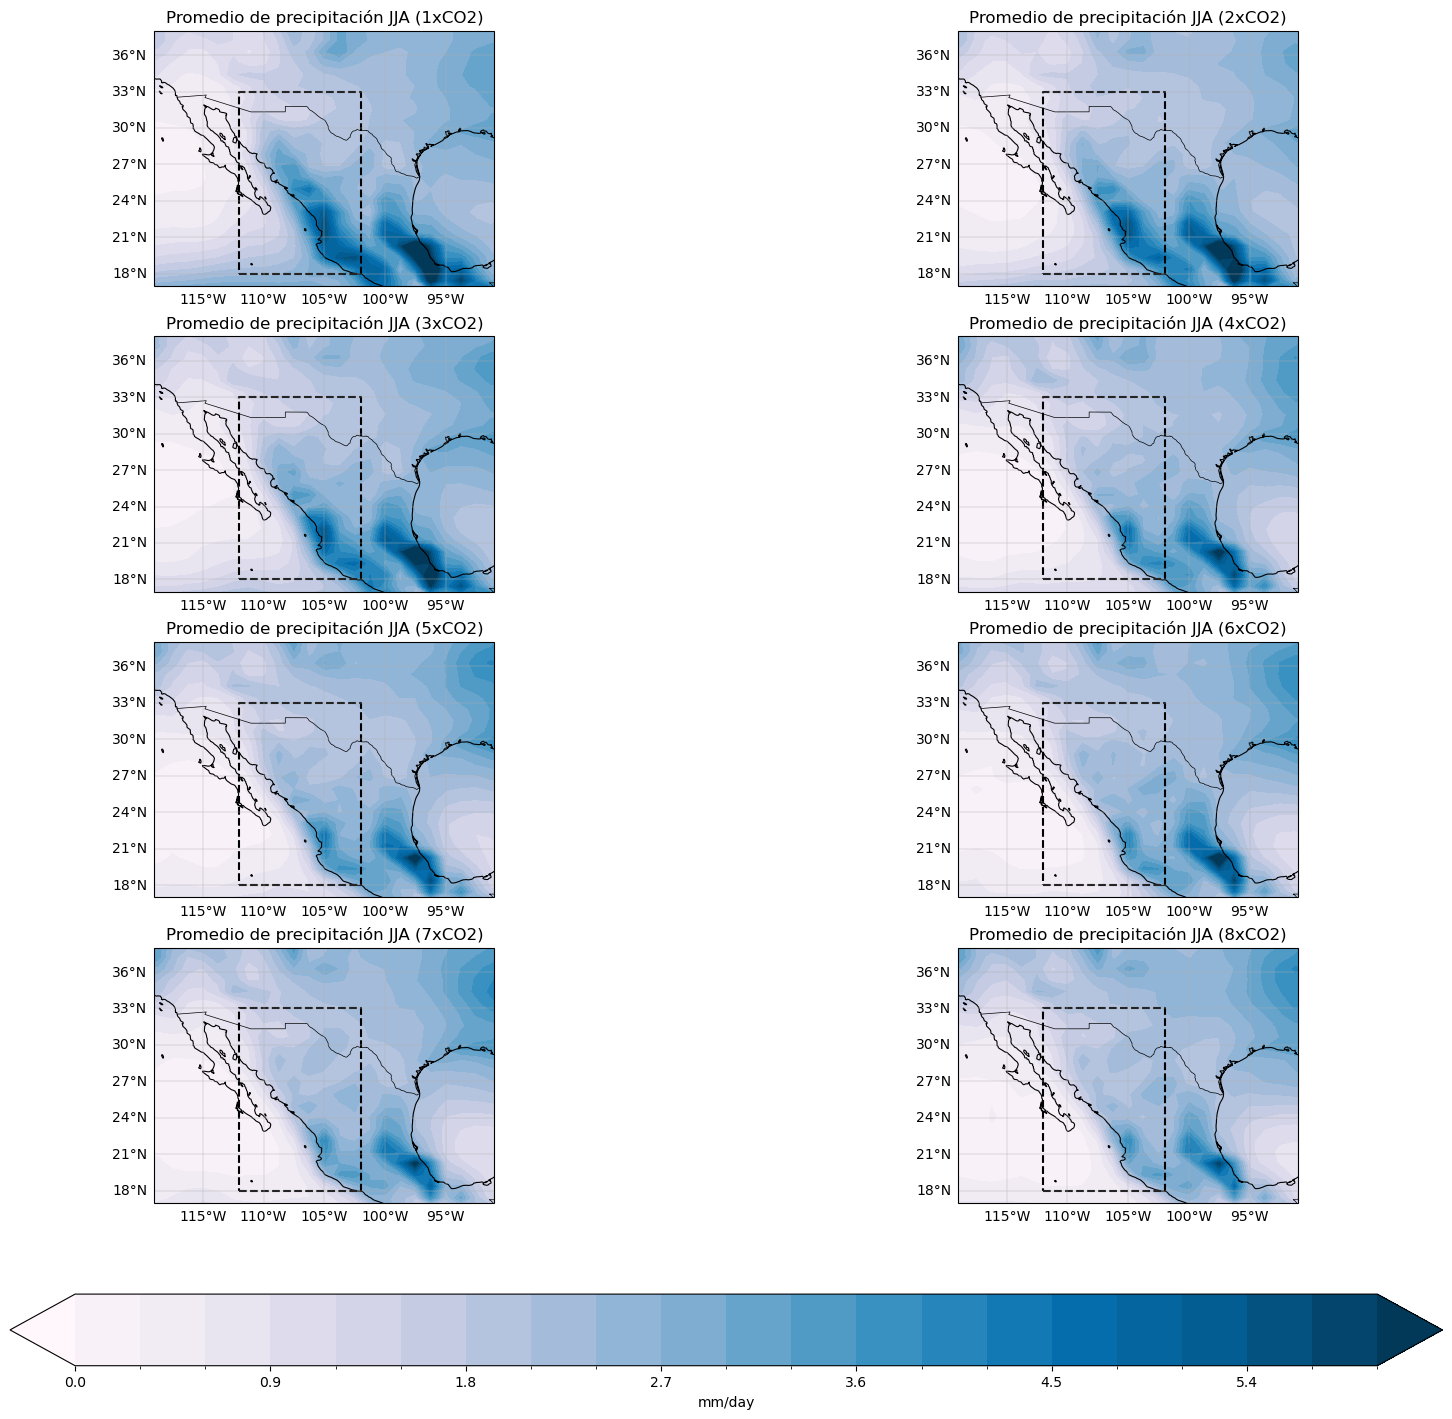

In [38]:
levels = np.linspace(0, 6, 21)

fig, axes = plt.subplots(
    4, 2,
    figsize=(16,14),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

datasets = [JJA_1, JJA_2, JJA_3, JJA_4, JJA_5, JJA_6, JJA_7, JJA_8]

titles = [
    "Promedio de precipitación JJA (1xCO2)",
    "Promedio de precipitación JJA (2xCO2)",
    "Promedio de precipitación JJA (3xCO2)",
    "Promedio de precipitación JJA (4xCO2)",
    "Promedio de precipitación JJA (5xCO2)",
    "Promedio de precipitación JJA (6xCO2)",
    "Promedio de precipitación JJA (7xCO2)",
    "Promedio de precipitación JJA (8xCO2)"
]

for ax, data, title in zip(axes, datasets, titles):

    ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

    cf = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap="PuBu",
        add_colorbar=False,
        extend="both"
    )

# Rectángulo NAM
    ax.plot(
        [-112, -102, -102, -112, -112],
        [18, 18, 33, 33, 18],
        transform=ccrs.PlateCarree(),
        linestyle="--",
        linewidth=1.5,
        color="k"
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.right_labels = False
    gl.top_labels = False

    ax.set_title(title)

cax = fig.add_axes([0.20, 0.05, 0.60, 0.025])
cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation="horizontal",
    shrink=0.9,
    pad=0.05
)

cbar.set_label("mm/day")

plt.show()


In [39]:
ds= xr.open_dataset('precip.monitor.mon.total.1x1.v2020.nc')
dp= xr.open_dataset('pr_Amon_HadGEM3-GC31-LL_amip_r1i1p1f3_gn_197901-201412.nc')

In [40]:
dp['time'] = [pd.Timestamp(str(t)) for t in dp['time'].values]

In [41]:
pr=ds.precip
pr=pr.where(pr.data<1e10,other=np.nan)

In [42]:
##Datos del cmip 5
Pro=dp.pr

In [43]:
## DAtos NOAA
periodo=pr['time'].dt.year

In [44]:
## Datos CMIP5
per1=Pro['time'].dt.year

In [45]:
## Datos NOAA 
# Delimitación del periodo de estudio
ANUAL= pr.where((periodo >= 1982) & (periodo <= 2024), drop=True)
ANUAL = ANUAL.assign_coords(lon=((ANUAL.lon + 180) % 360) - 180).sortby('lon')

In [46]:
## Datos NOAA 
## Eleccion del area de estudio y cambio de las coordendas de latitud
if ANUAL.lat[0] > ANUAL.lat[-1]:
    ANUAL = ANUAL.sortby('lat')
#ANUAL_1 = ANUAL.sel(lon=slice(-112, -102), lat=slice(18, 33))
ANUAL_1 = ANUAL.sel(lon=slice(-120, -90), lat=slice(16, 40))
#ANUAL_1 = ANUAL_1.dropna(dim='lat', how='all').dropna(dim='lon', how='all')
#-120, -90, 16, 40

In [47]:
days = xr.DataArray(ANUAL_1['time'].dt.days_in_month,
                    coords={'time': ANUAL_1['time']}, dims='time')

ANUAL_mmd = ANUAL_1 / days
ANUAL_mmd = ANUAL_mmd.assign_attrs({
    **ANUAL.attrs, 'units': 'mm day-1'
})

(array([6.0121e+04, 1.5007e+04, 4.2910e+03, 1.2860e+03, 3.1000e+02,
        6.9000e+01, 2.5000e+01, 4.0000e+00, 5.0000e+00, 2.0000e+00]),
 array([ 0.        ,  3.53353353,  7.06706706, 10.60060059, 14.13413411,
        17.66766764, 21.20120117, 24.7347347 , 28.26826823, 31.80180176,
        35.33533529]),
 <BarContainer object of 10 artists>)

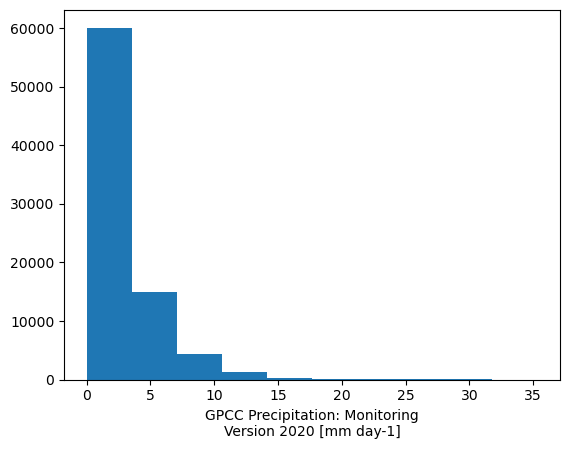

In [48]:
POP=ANUAL_mmd['time'].dt.month
pop= ANUAL_mmd.where((POP>=6) & (POP <= 9), drop=True)

pop.plot()

In [49]:
JJAS_NOAA= pop.mean(("time"), skipna=True)

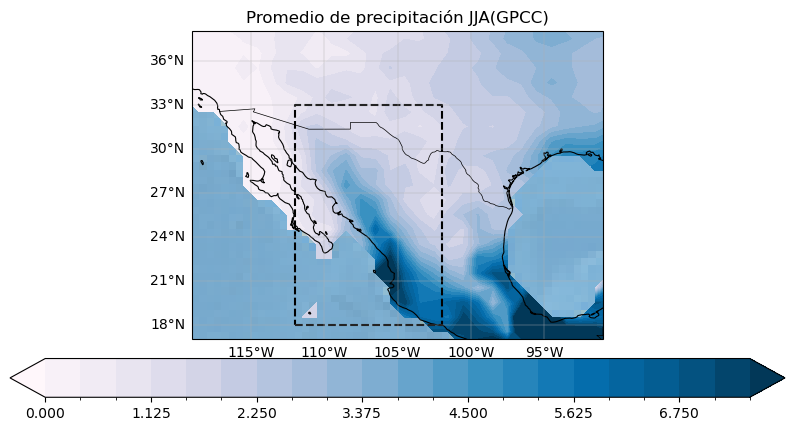

In [50]:

levels = np.linspace(0, 7.5, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = JJAS_NOAA.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=JJAS_NOAA.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA(GPCC)")
plt.show()

In [51]:
AÑOCMIP5= Pro.where((per1 >= 1982) & (per1 <= 2014), drop=True)
AÑOCMIP5 = AÑOCMIP5.assign_coords(lon=((AÑOCMIP5.lon + 180) % 360) - 180).sortby('lon')

if AÑOCMIP5.lat[0] > AÑOCMIP5.lat[-1]:
    AÑOCMIP5=AÑOCMIP5.sortby('lat')
AÑOCMIP5_1= AÑOCMIP5.sel(lon=slice(-120, -90), lat=slice(16, 40))
# Si AÑOCMIP5_1 es un DataArray llamado 'pr' en kg m-2 s-1:
CMIP_anual = AÑOCMIP5_1 * 86400.0
CMIP_anual = CMIP_anual.assign_attrs({
    **AÑOCMIP5_1.attrs,
    "units": "mm day-1",
    "long_name": AÑOCMIP5_1.attrs.get("long_name", "Precipitation") + " (daily rate)"
})

In [52]:
jas=CMIP_anual['time'].dt.month
JJAS= CMIP_anual.where((jas>=6) & (jas <= 8), drop=True)

JJAS

<xarray.DataArray 'pr' (time: 99, lat: 19, lon: 16)> Size: 120kB
array([[[ 0.16702217,  0.04916713,  0.1121572 , ...,  4.1922064 ,
          3.2402368 ,  4.4057903 ],
        [ 0.04360584,  0.07954864,  0.10645611, ...,  2.751757  ,
          4.2602468 ,  2.5177517 ],
        [ 0.16511315,  0.21072187,  0.01732577, ...,  0.7866941 ,
          0.97519696,  1.4558189 ],
        ...,
        [ 0.0483492 ,  0.05241279,  0.08980384, ...,  0.9322224 ,
          1.2922562 ,  0.90126544],
        [ 0.25725994,  0.08529692,  0.2008832 , ...,  0.9506986 ,
          1.1500437 ,  0.857218  ],
        [ 0.6563032 ,  0.235293  ,  0.18667796, ...,  1.0771792 ,
          1.1209767 ,  0.9302501 ]],

       [[ 0.72933435,  0.47831213,  0.9523471 , ...,  3.1027968 ,
          5.1072855 ,  5.4121394 ],
        [ 0.10195061,  0.15896209,  0.73111683, ...,  4.1207814 ,
          7.1860137 ,  3.9248319 ],
        [ 0.37146702,  0.14783284,  0.45947215, ...,  1.7314451 ,
          2.6358645 ,  2.33758   ],
...
        [ 1.0734824 ,  1.1297398 ,  1.1024191 , ...,  0.79583335,
          1.0258542 ,  1.1307455 ],
        [ 1.7220677 ,  2.7622745 ,  1.7554078 , ...,  0.86331594,
          0.64444715,  0.63596696],
        [ 1.7079159 ,  1.55982   ,  1.5275614 , ...,  0.5568064 ,
          0.5691938 ,  0.8683095 ]],

       [[ 1.6731019 ,  1.3588482 ,  0.6037978 , ...,  2.5060716 ,
          4.6123195 ,  5.237615  ],
        [ 0.22087333,  0.4901298 ,  0.4993374 , ...,  6.1057644 ,
         10.554929  ,  6.666505  ],
        [ 0.19194259,  0.37013456,  0.54767483, ...,  5.133787  ,
          5.4979033 ,  2.5055995 ],
        ...,
        [ 0.49716762,  0.5198631 ,  0.5113436 , ...,  2.1314514 ,
          1.5794361 ,  1.2470807 ],
        [ 0.44601628,  0.861323  ,  0.58715   , ...,  2.3806384 ,
          2.073243  ,  1.688883  ],
        [ 0.36184224,  1.1528461 ,  1.0595417 , ...,  2.7351236 ,
          2.6427274 ,  1.9778975 ]]], shape=(99, 19, 16), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 792B 1982-06-16 1982-07-16 ... 2014-08-16
  * lat      (lat) float64 152B 16.88 18.12 19.38 20.62 ... 36.88 38.12 39.38
  * lon      (lon) float64 128B -119.1 -117.2 -115.3 ... -94.69 -92.81 -90.94
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation (daily rate)
    comment:        includes both liquid and solid phases
    units:          mm day-1
    original_name:  mo: (stash: m01s05i216, lbproc: 128)
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-06-13T13:01:28Z altered by CMOR: replaced missing va...

In [53]:
JJAS_p= JJAS.mean(("time"), skipna= True)

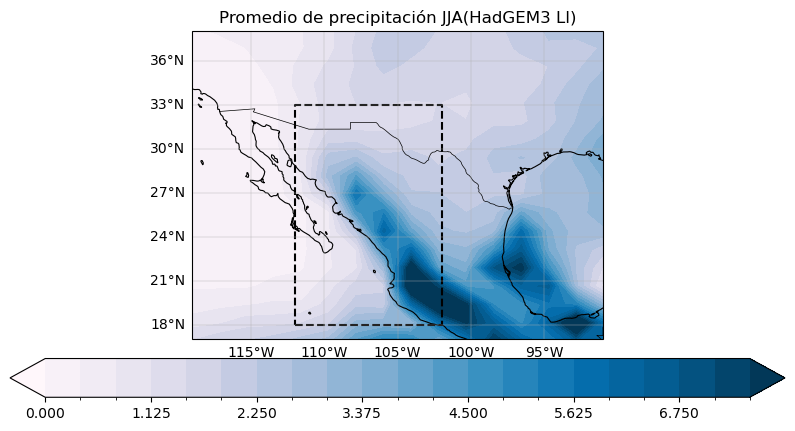

In [54]:
levels = np.linspace(0, 7.5, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = JJAS_p.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=JJAS_p.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA(HadGEM3 Ll)")
plt.show()

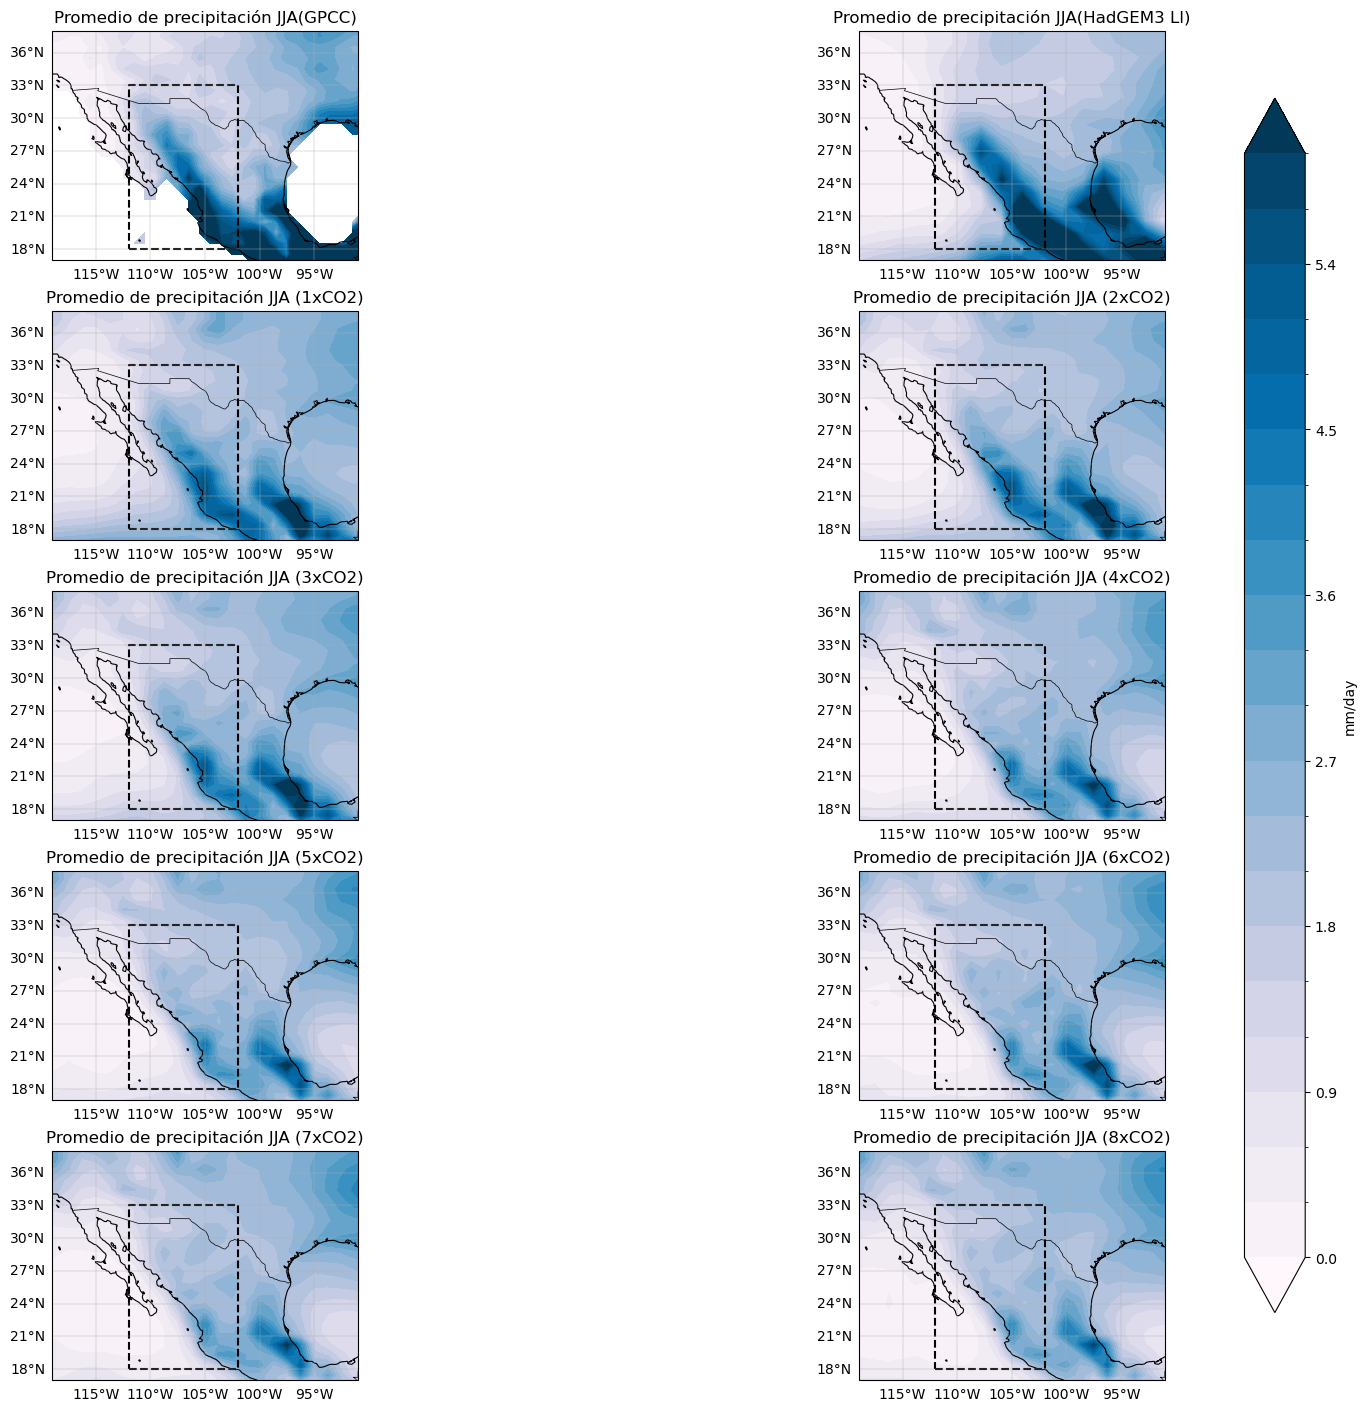

In [55]:
levels = np.linspace(0, 6, 21)

fig, axes = plt.subplots(
    5, 2,
    figsize=(18,14),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

datasets = [JJAS_NOAA,JJAS_p,JJA_1, JJA_2, JJA_3, JJA_4, JJA_5, JJA_6, JJA_7, JJA_8]

titles = [
    "Promedio de precipitación JJA(GPCC)",
    "Promedio de precipitación JJA(HadGEM3 Ll)",
    "Promedio de precipitación JJA (1xCO2)",
    "Promedio de precipitación JJA (2xCO2)",
    "Promedio de precipitación JJA (3xCO2)",
    "Promedio de precipitación JJA (4xCO2)",
    "Promedio de precipitación JJA (5xCO2)",
    "Promedio de precipitación JJA (6xCO2)",
    "Promedio de precipitación JJA (7xCO2)",
    "Promedio de precipitación JJA (8xCO2)"
]

for ax, data, title in zip(axes, datasets, titles):

    ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

    cf = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap="PuBu",
        add_colorbar=False,
        extend="both"
    )


    ax.plot(
        [-112, -102, -102, -112, -112],
        [18, 18, 33, 33, 18],
        transform=ccrs.PlateCarree(),
        linestyle="--",
        linewidth=1.5,
        color="k"
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.right_labels = False
    gl.top_labels = False

    ax.set_title(title)


cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation="vertical",
    shrink=0.9,
    pad=0.05
)


plt.savefig('Imagenes/Promedios JAS.png')

cbar.set_label("mm/day")

plt.show()


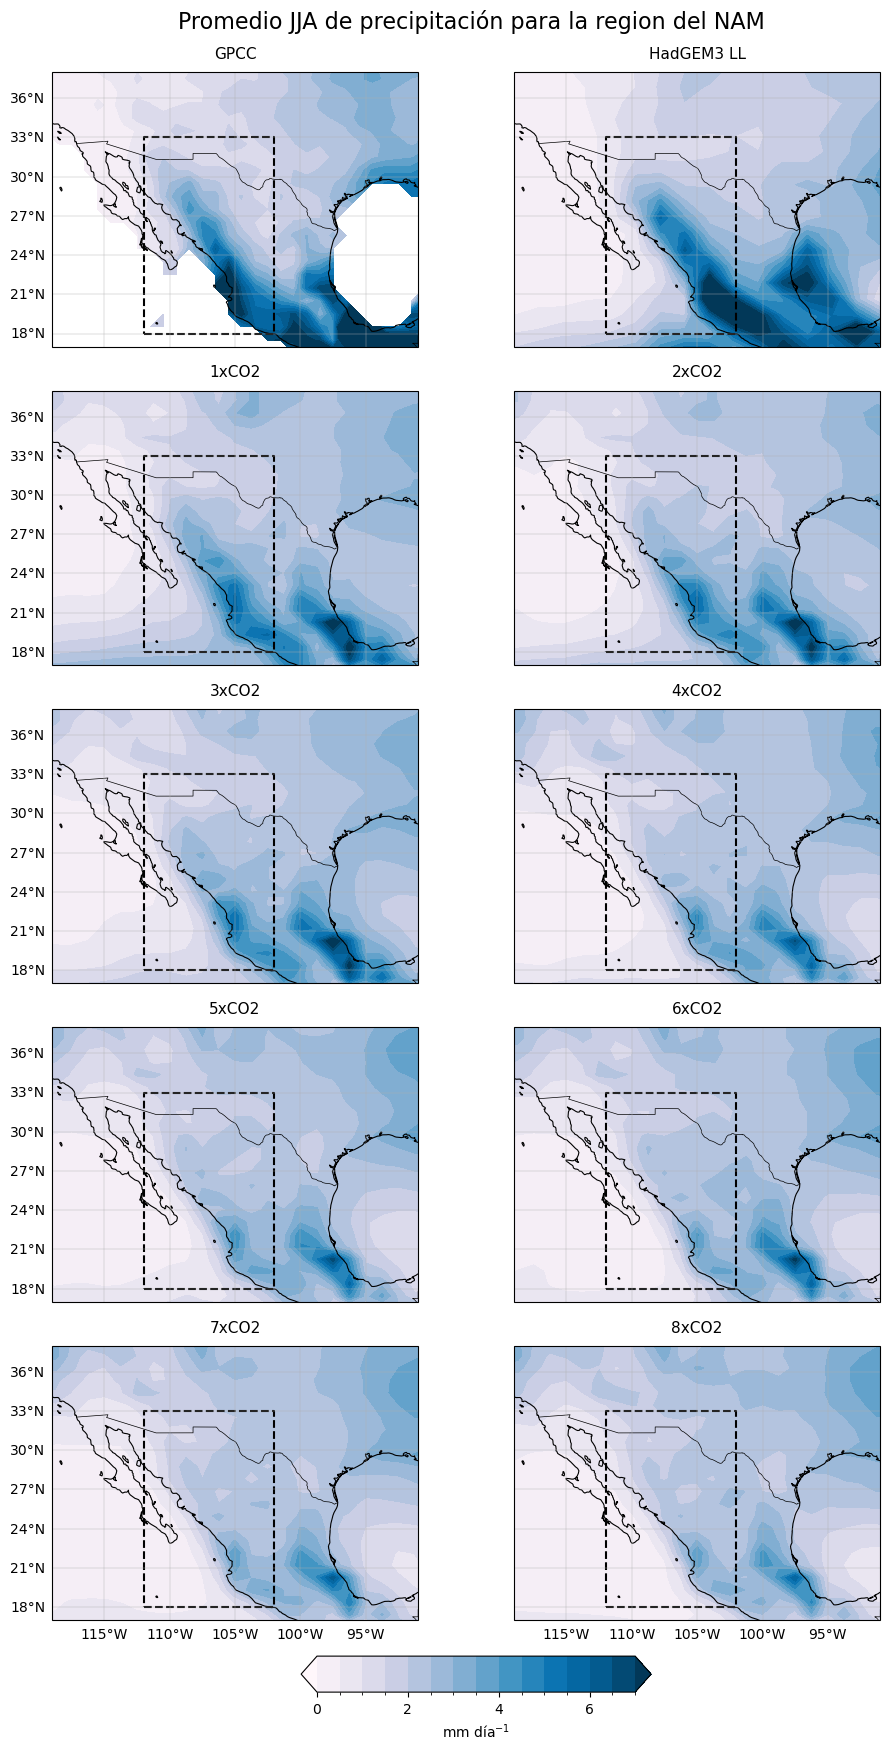

In [56]:
levels = np.arange(0, 7.5, 0.5)

fig, axes = plt.subplots(
    5, 2,
    figsize=(10,18),  
    subplot_kw={"projection": ccrs.PlateCarree()}
)


plt.subplots_adjust(
    left=0.05,
    right=0.94,
    top=.96,
    bottom=0.10,
    wspace=0.08,
    hspace=0.16
)



axes = axes.flatten()

datasets = [JJAS_NOAA, JJAS_p, JJA_1, JJA_2, JJA_3, JJA_4, JJA_5, JJA_6, JJA_7, JJA_8]

titles = [
    "GPCC",
    "HadGEM3 LL",
    "1xCO2",
    "2xCO2",
    "3xCO2",
    "4xCO2",
    "5xCO2",
    "6xCO2",
    "7xCO2",
    "8xCO2"
]

for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):

    ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

    cf = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap="PuBu",
        add_colorbar=False,
        extend="both"
    )


    ax.plot(
        [-112, -102, -102, -112, -112],
        [18, 18, 33, 33, 18],
        transform=ccrs.PlateCarree(),
        linestyle="--",
        linewidth=1.5,
        color="k"
    )


    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)      
    gl.bottom_labels = (i >= 8)        

    ax.set_title(title, fontsize=11, pad=10)



cax = fig.add_axes([0.33, 0.06, 0.35, 0.02])



cbar = fig.colorbar(
    cf,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(0, 7, 2)
)
cbar.set_label("mm día$^{-1}$")
fig.suptitle("Promedio JJA de precipitación para la region del NAM", fontsize=16, y=0.995)
plt.savefig('Imagenes/Promedios_JAS.png', dpi=300, bbox_inches="tight")
plt.show()



In [57]:
Cambio1 = JJA_2 - JJA_1
Cambio2 = JJA_3 - JJA_1
Cambio3 = JJA_4 - JJA_1
Cambio4 = JJA_5 - JJA_1
Cambio5 = JJA_6 - JJA_1
Cambio6 = JJA_7 - JJA_1
Cambio7 = JJA_8 - JJA_1



#Cambio1.plot()

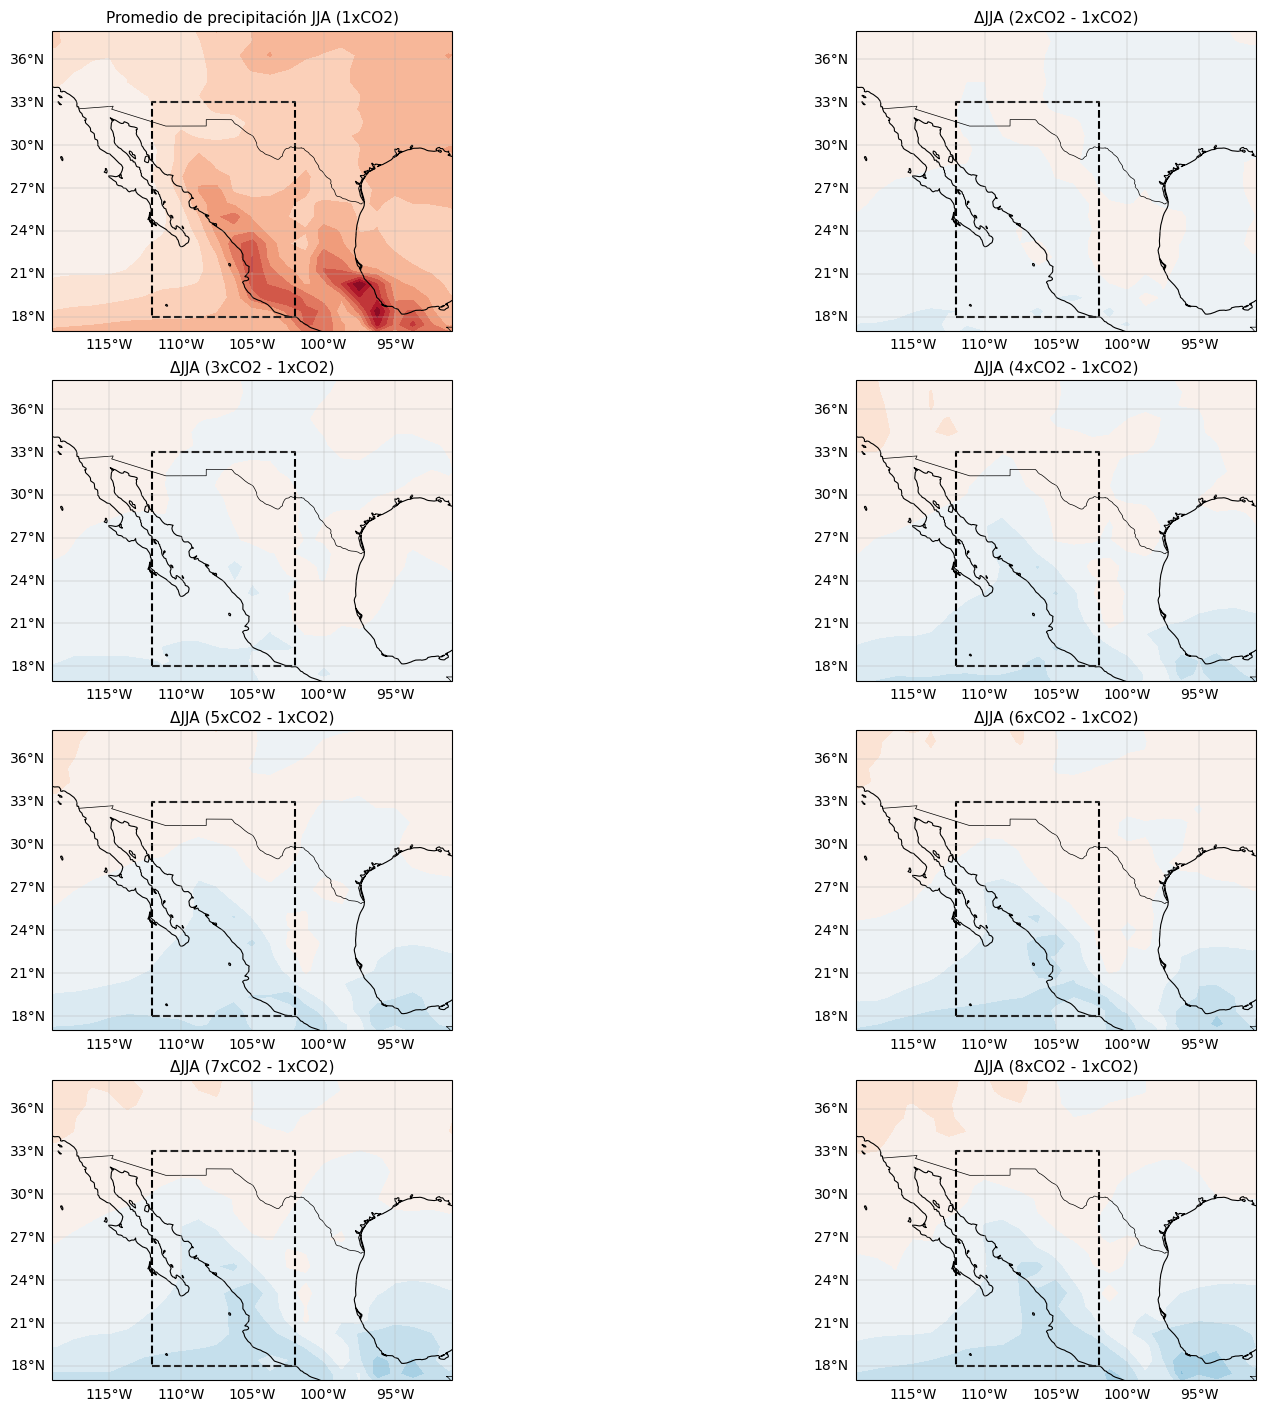

In [58]:


# Lista de cambios
cambios = [JJA_1, Cambio1, Cambio2, Cambio3, Cambio4, Cambio5, Cambio6, Cambio7]

titulos = [
    "Promedio de precipitación JJA (1xCO2)",
    "ΔJJA (2xCO2 - 1xCO2)",
    "ΔJJA (3xCO2 - 1xCO2)",
    "ΔJJA (4xCO2 - 1xCO2)",
    "ΔJJA (5xCO2 - 1xCO2)",
    "ΔJJA (6xCO2 - 1xCO2)",
    "ΔJJA (7xCO2 - 1xCO2)",
    "ΔJJA (8xCO2 - 1xCO2)"
]

# Definir rango simétrico para anomalías
vmax = max([float(c.max()) for c in cambios])
vmin = min([float(c.min()) for c in cambios])
absmax = max(abs(vmin), abs(vmax))

levels = np.linspace(-absmax, absmax, 21)

fig, axes = plt.subplots(
    4, 2,
    figsize=(16,14),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

for ax, data, title in zip(axes, cambios, titulos):

    ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

    cf = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap="RdBu_r",
        add_colorbar=False,
        extend="both"
    )

    ax.plot(
        [-112, -102, -102, -112, -112],
        [18, 18, 33, 33, 18],
        transform=ccrs.PlateCarree(),
        linestyle="--",
        linewidth=1.5,
        color="k"
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.right_labels = False
    gl.top_labels = False

    ax.set_title(title, fontsize=11)


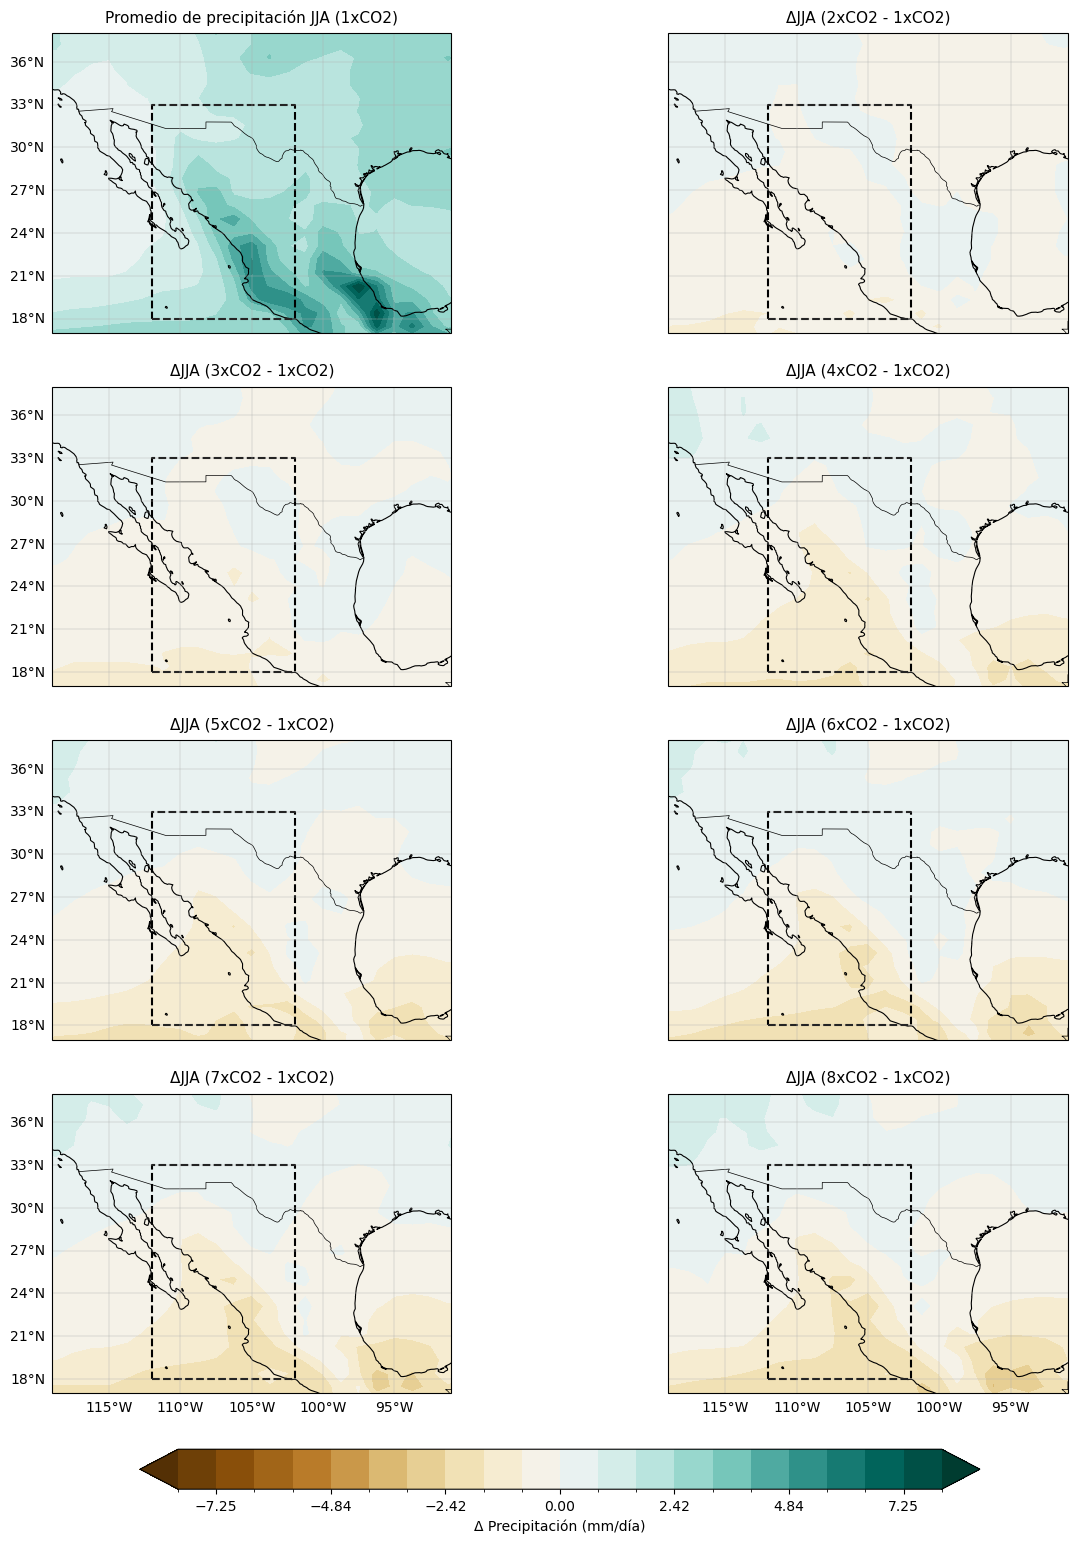

In [59]:
cambios = [JJA_1, Cambio1, Cambio2, Cambio3, Cambio4, Cambio5, Cambio6, Cambio7]

titulos = [
    "Promedio de precipitación JJA (1xCO2)",
    "ΔJJA (2xCO2 - 1xCO2)",
    "ΔJJA (3xCO2 - 1xCO2)",
    "ΔJJA (4xCO2 - 1xCO2)",
    "ΔJJA (5xCO2 - 1xCO2)",
    "ΔJJA (6xCO2 - 1xCO2)",
    "ΔJJA (7xCO2 - 1xCO2)",
    "ΔJJA (8xCO2 - 1xCO2)"
]



vmax = max(float(c.max()) for c in cambios)
vmin = min(float(c.min()) for c in cambios)
absmax = max(abs(vmin), abs(vmax))
levels = np.linspace(-absmax, absmax, 21)

fig, axes = plt.subplots(
    4, 2,
    figsize=(14,16),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

plt.subplots_adjust(
    left=0.06,
    right=0.94,
    top=0.97,
    bottom=0.12,
    wspace=0.001,
    hspace=0.18
)

axes = axes.flatten()

for i, (ax, data, title) in enumerate(zip(axes, cambios, titulos)):

    ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

    cf = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap="BrBG",
        add_colorbar=False,
        extend="both"
    )

    ax.plot(
        [-112, -102, -102, -112, -112],
        [18, 18, 33, 33, 18],
        transform=ccrs.PlateCarree(),
        linestyle="--",
        linewidth=1.5,
        color="k"
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 6)

    ax.set_title(title, fontsize=11, pad=8)



cax = fig.add_axes([0.2, 0.06, 0.6, 0.025])
cbar = fig.colorbar(cf, cax=cax, orientation="horizontal")
cbar.set_label("Δ Precipitación (mm/día)")



plt.savefig('Imagenes/Diferencias de precipitación (1 a 8).png', dpi=300, bbox_inches="tight")
plt.show()


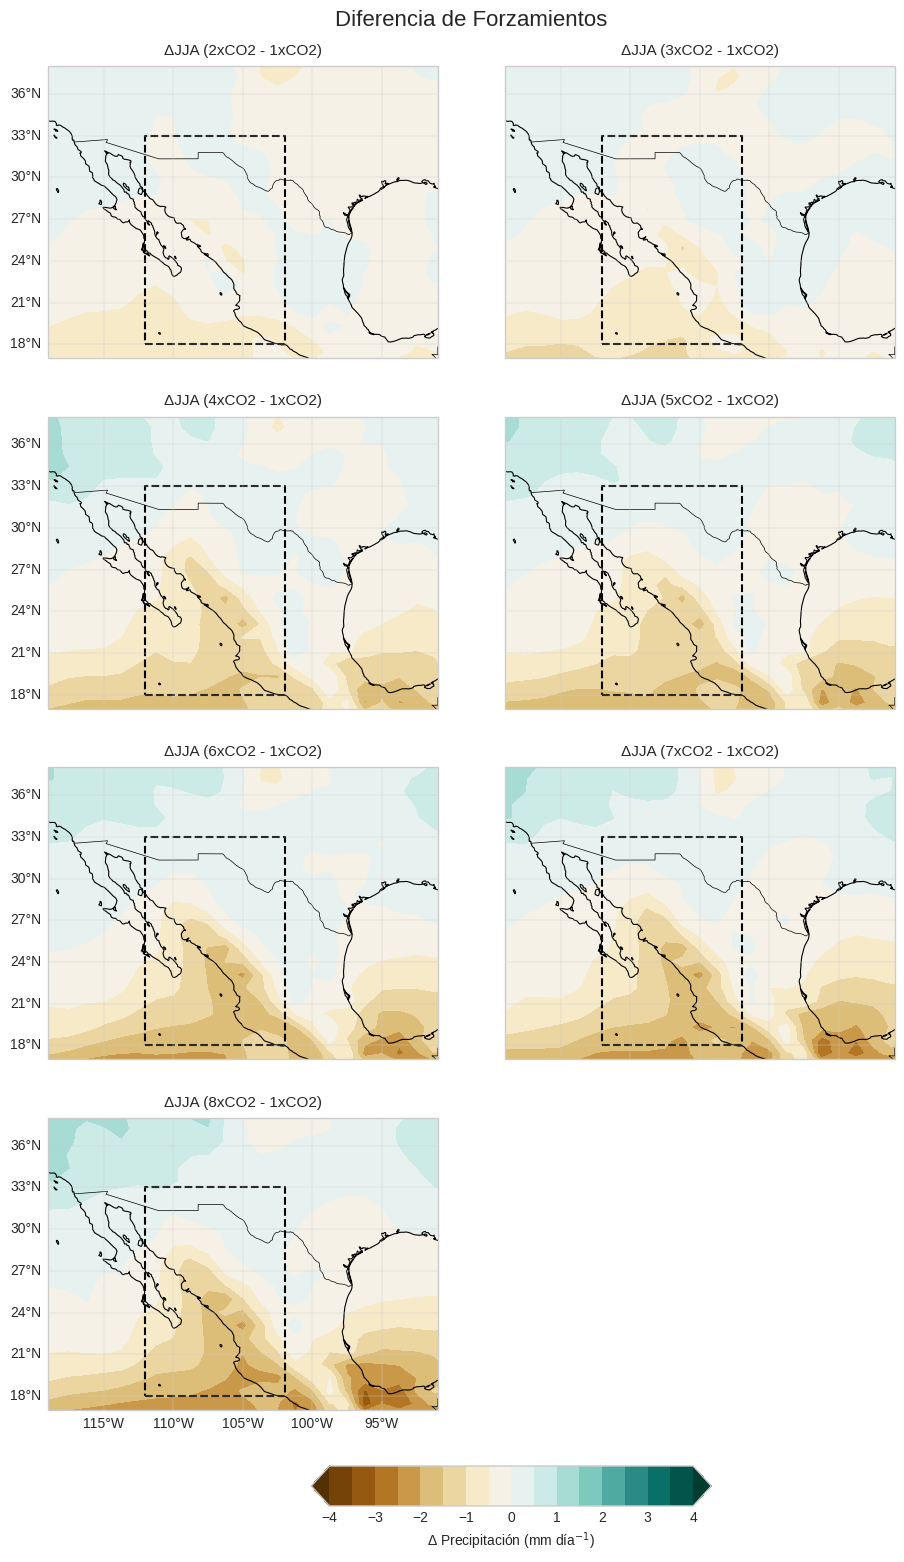

In [211]:
cambios = [Cambio1, Cambio2, Cambio3, Cambio4, Cambio5, Cambio6, Cambio7]

titulos = [
    "ΔJJA (2xCO2 - 1xCO2)",
    "ΔJJA (3xCO2 - 1xCO2)",
    "ΔJJA (4xCO2 - 1xCO2)",
    "ΔJJA (5xCO2 - 1xCO2)",
    "ΔJJA (6xCO2 - 1xCO2)",
    "ΔJJA (7xCO2 - 1xCO2)",
    "ΔJJA (8xCO2 - 1xCO2)"
]

# Rango simétrico
levels = np.linspace(-4, 4, 17)

fig, axes = plt.subplots(
    4, 2,
    figsize=(10,16),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

plt.subplots_adjust(
    left=0.06,
    right=0.94,
    top=0.96,
    bottom=0.12,
    wspace=0.08,
    hspace=0.2
)

axes = axes.flatten()

for i, (ax, data, title) in enumerate(zip(axes, cambios, titulos)):

    ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

    cf = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap="BrBG",
        add_colorbar=False,
        extend="both"
    )

    ax.plot(
        [-112, -102, -102, -112, -112],
        [18, 18, 33, 33, 18],
        transform=ccrs.PlateCarree(),
        linestyle="--",
        linewidth=1.5,
        color="k"
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 6)

    ax.set_title(title, fontsize=11, pad=8)


for j in range(len(cambios), len(axes)):
    fig.delaxes(axes[j])


cax = fig.add_axes([0.34, 0.06, 0.40, 0.025])
cbar = fig.colorbar(cf, cax=cax, orientation="horizontal")
cbar.set_label("Δ Precipitación (mm día$^{-1}$)")
fig.suptitle("Diferencia de Forzamientos", fontsize=16, y=0.995)
plt.savefig('Imagenes/Diferencias 2 a 8.png', dpi=300, bbox_inches="tight")
plt.show()


In [61]:
pr9= xr.open_dataset('pr_1xCO2_run_cesm1-lens_1850-1999.nc')

In [62]:
pr9['year'] = [pd.Timestamp(str(t)) for t in pr9['year'].values]

In [63]:
pr9

<xarray.Dataset> Size: 598MB
Dimensions:     (year: 150, lat: 192, lon: 288)
Coordinates:
  * year        (year) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 1999-01-01
  * lat         (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon         (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables:
    pr          (year, lat, lon) float64 66MB ...
    pr_djf      (year, lat, lon) float64 66MB ...
    pr_jja      (year, lat, lon) float64 66MB ...
    pr_max      (year, lat, lon) float64 66MB ...
    pr_max_djf  (year, lat, lon) float64 66MB ...
    pr_max_jja  (year, lat, lon) float64 66MB ...
    tas         (year, lat, lon) float64 66MB ...
    tas_djf     (year, lat, lon) float64 66MB ...
    tas_jja     (year, lat, lon) float64 66MB ...
    weight      (lat, lon) float64 442kB ...

In [64]:
pr9['pr'] = pr9['pr'].astype('float32')
pr9['pr_jja'] = pr9['pr_jja'].astype('float32')
year=pr9['year']

In [65]:
pr9= pr9.assign_coords(lon=((pr9.lon + 180) % 360) - 180).sortby('lon')


#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
pr9=pr9.sel(year=slice("1949-01-01", "1999-01-01"))

In [66]:
pr9= pr9.sel(lon=slice(-112,-102), lat=slice(18,33))

In [67]:
pr9

<xarray.Dataset> Size: 419kB
Dimensions:     (year: 51, lat: 16, lon: 8)
Coordinates:
  * year        (year) datetime64[ns] 408B 1949-01-01 1950-01-01 ... 1999-01-01
  * lat         (lat) float64 128B 18.38 19.32 20.26 21.2 ... 30.63 31.57 32.51
  * lon         (lon) float64 64B -111.2 -110.0 -108.8 ... -105.0 -103.8 -102.5
Data variables:
    pr          (year, lat, lon) float32 26kB 1.478 1.676 1.903 ... 2.008 2.462
    pr_djf      (year, lat, lon) float64 52kB ...
    pr_jja      (year, lat, lon) float32 26kB 1.391 1.488 1.608 ... 2.037 2.617
    pr_max      (year, lat, lon) float64 52kB ...
    pr_max_djf  (year, lat, lon) float64 52kB ...
    pr_max_jja  (year, lat, lon) float64 52kB ...
    tas         (year, lat, lon) float64 52kB ...
    tas_djf     (year, lat, lon) float64 52kB ...
    tas_jja     (year, lat, lon) float64 52kB ...
    weight      (lat, lon) float64 1kB ...

In [68]:
precip9= pr9.pr

In [69]:
pre9=precip9.mean(('lat','lon'))

In [70]:
df1 = pre9.to_dataframe().reset_index()
df1["CO2"] = "1xCO2"

In [71]:
## dataframe para 2 veces CO2



pr10= xr.open_dataset('pr_2xCO2_run_cesm1-lens_1850-1999.nc')
pr10['year'] = [pd.Timestamp(str(t)) for t in pr10['year'].values]

pr10['pr'] = pr10['pr'].astype('float32')
pr10['pr_jja'] = pr10['pr_jja'].astype('float32')

pr10= pr10.assign_coords(lon=((pr10.lon + 180) % 360) - 180).sortby('lon')


#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
pr10=pr10.sel(year=slice("1949-01-01", "1999-01-01"))

pr10= pr10.sel(lon=slice(-112,-102), lat=slice(18,33))

precip10= pr10.pr

pre10=precip10.mean(('lat','lon'))

df2 = pre10.to_dataframe().reset_index()
df2["CO2"] = "2xCO2"

In [72]:
## dataframe para 3 veces CO2



pr11= xr.open_dataset('pr_3xCO2_run_cesm1-lens_1850-1999.nc')
pr11['year'] = [pd.Timestamp(str(t)) for t in pr11['year'].values]

pr11['pr'] = pr11['pr'].astype('float32')
pr11['pr_jja'] = pr11['pr_jja'].astype('float32')

pr11= pr11.assign_coords(lon=((pr11.lon + 180) % 360) - 180).sortby('lon')


#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
pr11=pr11.sel(year=slice("1949-01-01", "1999-01-01"))

pr11= pr11.sel(lon=slice(-112,-102), lat=slice(18,33))

precip11= pr11.pr

pre11=precip11.mean(('lat','lon'))

df3 = pre11.to_dataframe().reset_index()
df3["CO2"] = "3xCO2"

In [73]:
## dataframe para 4 veces CO2



pr12= xr.open_dataset('pr_4xCO2_run_cesm1-lens_1850-1999.nc')
pr12['year'] = [pd.Timestamp(str(t)) for t in pr12['year'].values]

pr12['pr'] = pr12['pr'].astype('float32')
pr12['pr_jja'] = pr12['pr_jja'].astype('float32')

pr12= pr12.assign_coords(lon=((pr12.lon + 180) % 360) - 180).sortby('lon')


#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
pr12=pr12.sel(year=slice("1949-01-01", "1999-01-01"))

pr12= pr12.sel(lon=slice(-112,-102), lat=slice(18,33))

precip12= pr12.pr

pre12=precip12.mean(('lat','lon'))

df4 = pre12.to_dataframe().reset_index()
df4["CO2"] = "4xCO2"

In [74]:
## dataframe para 5 veces CO2



pr13= xr.open_dataset('pr_5xCO2_run_cesm1-lens_1850-1999.nc')
pr13['year'] = [pd.Timestamp(str(t)) for t in pr13['year'].values]

pr13['pr'] = pr13['pr'].astype('float32')
pr13['pr_jja'] = pr13['pr_jja'].astype('float32')

pr13= pr13.assign_coords(lon=((pr13.lon + 180) % 360) - 180).sortby('lon')


#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
pr13=pr13.sel(year=slice("1949-01-01", "1999-01-01"))

pr13= pr13.sel(lon=slice(-112,-102), lat=slice(18,33))

precip13= pr13.pr

pre13=precip13.mean(('lat','lon'))

df5 = pre13.to_dataframe().reset_index()
df5["CO2"] = "5xCO2"

In [75]:
## dataframe para 6 veces CO2



pr14= xr.open_dataset('pr_6xCO2_run_cesm1-lens_1850-1999.nc')
pr14['year'] = [pd.Timestamp(str(t)) for t in pr14['year'].values]

pr14['pr'] = pr14['pr'].astype('float32')
pr14['pr_jja'] = pr14['pr_jja'].astype('float32')

pr14= pr14.assign_coords(lon=((pr14.lon + 180) % 360) - 180).sortby('lon')


#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
pr14=pr14.sel(year=slice("1949-01-01", "1999-01-01"))

pr14= pr14.sel(lon=slice(-112,-102), lat=slice(18,33))

precip14= pr14.pr

pre14=precip14.mean(('lat','lon'))

df6 = pre14.to_dataframe().reset_index()
df6["CO2"] = "6xCO2"

In [76]:
## dataframe para 6 veces CO2



pr15= xr.open_dataset('pr_7xCO2_run_cesm1-lens_1850-1999.nc')
pr15['year'] = [pd.Timestamp(str(t)) for t in pr15['year'].values]

pr15['pr'] = pr15['pr'].astype('float32')
pr15['pr_jja'] = pr15['pr_jja'].astype('float32')

pr15= pr15.assign_coords(lon=((pr15.lon + 180) % 360) - 180).sortby('lon')


#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
pr15=pr15.sel(year=slice("1949-01-01", "1999-01-01"))

pr15= pr15.sel(lon=slice(-112,-102), lat=slice(18,33))

precip15= pr15.pr

pre15=precip15.mean(('lat','lon'))

df7 = pre15.to_dataframe().reset_index()
df7["CO2"] = "7xCO2"

In [77]:
## dataframe para 6 veces CO2



pr16= xr.open_dataset('pr_8xCO2_run_cesm1-lens_1850-1999.nc')
pr16['year'] = [pd.Timestamp(str(t)) for t in pr16['year'].values]

pr16['pr'] = pr16['pr'].astype('float32')
pr16['pr_jja'] = pr16['pr_jja'].astype('float32')

pr16= pr16.assign_coords(lon=((pr16.lon + 180) % 360) - 180).sortby('lon')


#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
pr16=pr16.sel(year=slice("1949-01-01", "1999-01-01"))

pr16= pr16.sel(lon=slice(-112,-102), lat=slice(18,33))

precip16= pr16.pr

pre16=precip16.mean(('lat','lon'))

df8 = pre16.to_dataframe().reset_index()
df8["CO2"] = "8xCO2"

In [78]:
precipitacion_anual_NAM = pd.concat([df1, df2, df3, df4, df5, df6, df7,df8])

In [79]:
precipitacion_anual_NAM

,year,pr,CO2
0,1949-01-01,2.294140,1xCO2
1,1950-01-01,2.773949,1xCO2
2,1951-01-01,2.266304,1xCO2
3,1952-01-01,2.268788,1xCO2
4,1953-01-01,2.473314,1xCO2
...,...,...,...
46,1995-01-01,1.842872,8xCO2
47,1996-01-01,1.615345,8xCO2
48,1997-01-01,1.557976,8xCO2
49,1998-01-01,2.090735,8xCO2


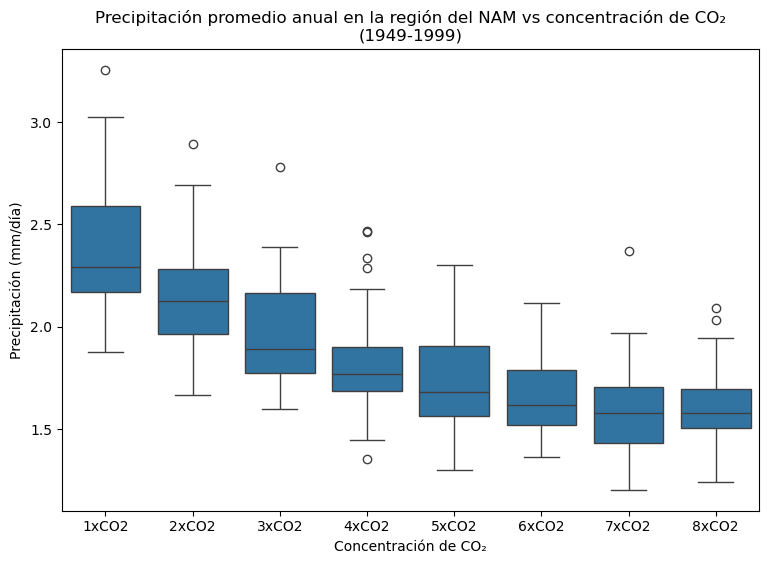

In [80]:
import seaborn as sns

plt.figure(figsize=(9,6))

sns.boxplot(x="CO2", y="pr", data=precipitacion_anual_NAM)

plt.xlabel("Concentración de CO₂")
plt.ylabel("Precipitación (mm/día)")
plt.title("Precipitación promedio anual en la región del NAM vs concentración de CO₂\n(1949-1999)")
plt.savefig('Imagenes/Boxplot CO2.png', dpi=300, bbox_inches="tight")
plt.show()

In [81]:
ANUAL_mmd2= ANUAL_mmd.sel(lon=slice(-112,102), lat= slice(18,33))
anual_gpcc = ANUAL_mmd2.groupby("time.year").mean("time")


In [82]:


GPCC = anual_gpcc.mean(('lat','lon'))

dGPCC = GPCC.to_dataframe(name="pr").reset_index()
dGPCC["CO2"] = "GPCC"


In [83]:
anual_HAD= CMIP_anual.groupby("time.year").mean("time")

In [84]:
HAD = anual_HAD.mean(('lat','lon'))

dHAD = HAD.to_dataframe(name="pr").reset_index()
dHAD["CO2"] = "HADGEM_3"


In [85]:
Boxplot = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, dHAD, dGPCC],ignore_index=True)

In [86]:
print(Boxplot.columns)


Index(['year', 'pr', 'CO2'], dtype='object')


In [87]:
print(df1.columns)
print(dHAD.columns)
print(dGPCC.columns)


Index(['year', 'pr', 'CO2'], dtype='object')
Index(['year', 'pr', 'CO2'], dtype='object')
Index(['year', 'pr', 'CO2'], dtype='object')


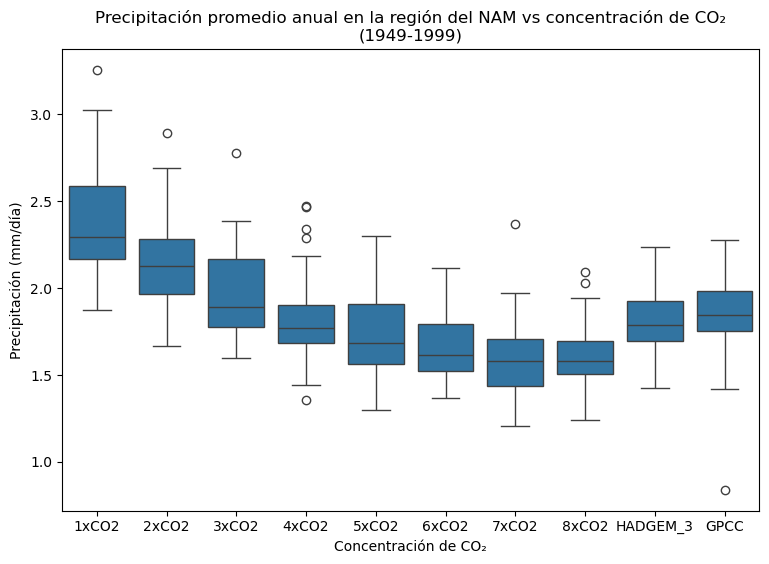

In [88]:

plt.figure(figsize=(9,6))

sns.boxplot(x="CO2", y="pr", data=Boxplot)

plt.xlabel("Concentración de CO₂")
plt.ylabel("Precipitación (mm/día)")
plt.title("Precipitación promedio anual en la región del NAM vs concentración de CO₂\n(1949-1999)")
plt.savefig('Imagenes/Boxplot ANUAL de la región.png', dpi=300, bbox_inches="tight")
plt.show()

In [89]:
precip9_JJA= pr9.pr_jja

pre9_JJA=precip9_JJA.mean(('lat','lon'))

dfJJA = pre9_JJA.to_dataframe().reset_index()
dfJJA["CO2"] = "1xCO2"

In [90]:
precip10_JJA= pr10.pr_jja

pre10_JJA=precip10_JJA.mean(('lat','lon'))

dfJJA1 = pre10_JJA.to_dataframe().reset_index()
dfJJA1["CO2"] = "2xCO2"

In [91]:
precip11_JJA= pr11.pr_jja

pre11_JJA=precip11_JJA.mean(('lat','lon'))

dfJJA2 = pre11_JJA.to_dataframe().reset_index()
dfJJA2["CO2"] = "3xCO2"

In [92]:
precip12_JJA= pr12.pr_jja

pre12_JJA=precip12_JJA.mean(('lat','lon'))

dfJJA3 = pre12_JJA.to_dataframe().reset_index()
dfJJA3["CO2"] = "4xCO2"

In [93]:
precip13_JJA= pr13.pr_jja

pre13_JJA=precip13_JJA.mean(('lat','lon'))

dfJJA4 = pre13_JJA.to_dataframe().reset_index()
dfJJA4["CO2"] = "5xCO2"

In [94]:
precip14_JJA= pr14.pr_jja

pre14_JJA=precip14_JJA.mean(('lat','lon'))

dfJJA5 = pre14_JJA.to_dataframe().reset_index()
dfJJA5["CO2"] = "6xCO2"

In [95]:
precip15_JJA= pr15.pr_jja

pre15_JJA=precip15_JJA.mean(('lat','lon'))

dfJJA6 = pre15_JJA.to_dataframe().reset_index()
dfJJA6["CO2"] = "7xCO2"

In [96]:
precip16_JJA= pr16.pr_jja

pre16_JJA=precip16_JJA.mean(('lat','lon'))

dfJJA7 = pre15_JJA.to_dataframe().reset_index()
dfJJA7["CO2"] = "8xCO2"

In [97]:
pop= ANUAL_mmd.where((POP>=6) & (POP <= 8), drop=True)

In [98]:
HAD_JJAS= CMIP_anual.where((jas>=6) & (jas <= 8), drop=True)

In [99]:
JJA_GPCC= pop.groupby("time.year").mean("time")

In [100]:
GPCCjja = JJA_GPCC.mean(('lat','lon'),skipna= True)

dnoaa = GPCCjja.to_dataframe(name="pr_jja").reset_index()
dnoaa["CO2"] = "GPCC"


In [101]:
HADjja= HAD_JJAS.groupby("time.year").mean("time")

In [102]:
HAdGEM_jja = HADjja.mean(('lat','lon'),skipna= True)

dHADGEM = HAdGEM_jja.to_dataframe(name="pr_jja").reset_index()
dHADGEM["CO2"] = "HADGEM_3"


In [103]:
BOXPLOT_JJA = pd.concat([dnoaa,dfJJA, dfJJA1, dfJJA2, dfJJA3, dfJJA4, dfJJA5, dfJJA6, dfJJA7],ignore_index=True)

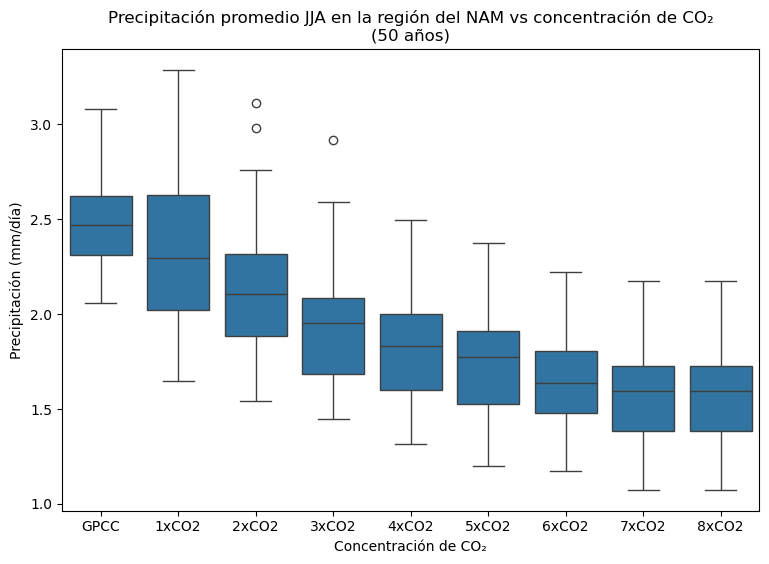

In [104]:



plt.figure(figsize=(9,6))

sns.boxplot(x="CO2", y="pr_jja", data=BOXPLOT_JJA)

plt.xlabel("Concentración de CO₂")
plt.ylabel("Precipitación (mm/día)")
plt.title("Precipitación promedio JJA en la región del NAM vs concentración de CO₂\n(50 años)")

plt.savefig('Imagenes/Boxplot JJA del NAM (CO2).png', dpi=300, bbox_inches="tight")


plt.show()

In [105]:
## Aqui estamos leyendo los datos de GCPP

dl= xr.open_dataset('precip.mon.mean.nc')

In [106]:
dl

<xarray.Dataset> Size: 23MB
Dimensions:    (time: 564, nv: 2, lat: 72, lon: 144)
Coordinates:
  * lat        (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon        (lon) float32 576B 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * time       (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 9kB ...
    lat_bnds   (lat, nv) float32 576B ...
    lon_bnds   (lon, nv) float32 1kB ...
    precip     (time, lat, lon) float32 23MB ...
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2025/11 through latest.

In [107]:
pl= dl.precip
pergcpc=pr['time'].dt.year

anualgcpc= pl.where((periodo >= 1982) & (periodo <= 2024), drop=True)

In [108]:
## Datos GCPC Cambio de las coordendas de longitud
anualgcpc = anualgcpc.assign_coords(lon=((anualgcpc.lon + 180) % 360) - 180).sortby('lon')

if anualgcpc.lat[0] > anualgcpc.lat[-1]:
    anualgcpc= anualgcpc.sortby('lat')
anualgcpc_1 =anualgcpc.sel(lon=slice(-120,90), lat= slice(16,40))

## Seleccionamos los meses de estudio
gcpc_3=anualgcpc_1['time'].dt.month
JJA_GCPC= anualgcpc_1.where((gcpc_3>=6) & (gcpc_3 <= 8), drop=True)




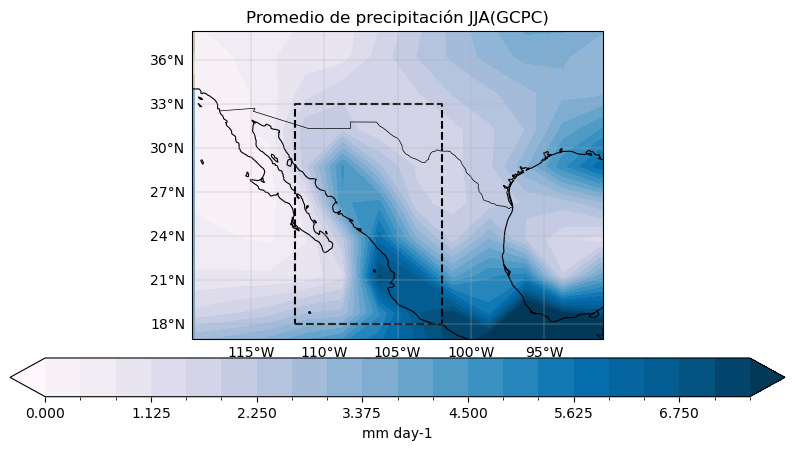

In [109]:
jja_GCPC= JJA_GCPC.mean(("time"), skipna=True)

levels = np.linspace(0, 7.5, 21)

fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = jja_GCPC.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap='PuBu',
    extend="both"
)

lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=pop.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA(GCPC)")
plt.show()

In [110]:
anualgcpc_2=anualgcpc_1.sel(lon=slice(-112,102), lat= slice(18,33))

In [111]:
ANUALGCPC= anualgcpc_2.groupby("time.year").mean("time")


GCPC = anualgcpc_2.mean(('lat','lon'))

dGcpC = GCPC.to_dataframe(name="pr").reset_index()
dGcpC["CO2"] = "GCPC"
Boxplot_ANUAL = pd.concat([dGPCC, dGcpC,df1, df2, df3, df4, df5, df6, df7, df8, ],ignore_index=True)

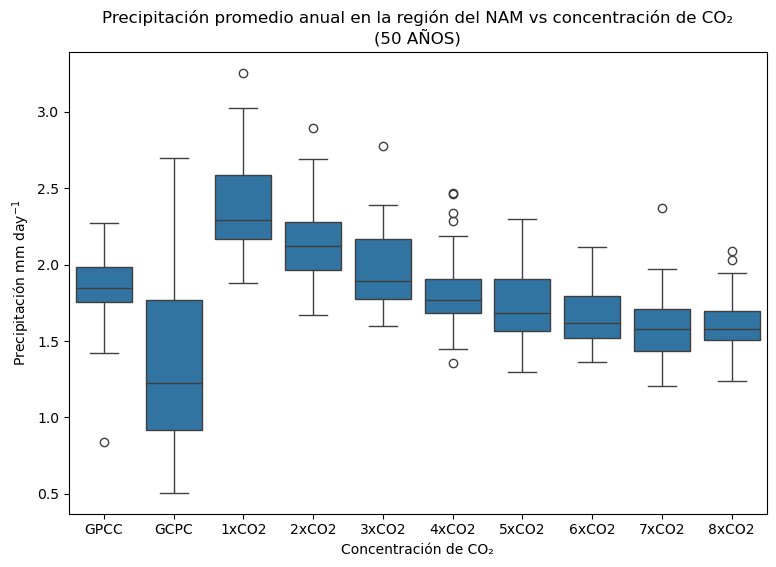

In [112]:

plt.figure(figsize=(9,6))

sns.boxplot(x="CO2", y="pr", data=Boxplot_ANUAL)

plt.xlabel("Concentración de CO₂")
plt.ylabel("Precipitación mm day$^{-1}$")
plt.title("Precipitación promedio anual en la región del NAM vs concentración de CO₂\n(50 AÑOS)")
plt.savefig('Imagenes/Boxplot ANUAL de la región.png', dpi=300, bbox_inches="tight")
plt.show()

In [113]:
gcpc= anualgcpc_1.where((gcpc_3>=6) & (gcpc_3 <= 8), drop=True)
JJA_gcpc= gcpc.groupby("time.year").mean("time")

gcpcjja = JJA_gcpc.mean(('lat','lon'),skipna= True)

dgcpc = gcpcjja.to_dataframe(name="pr_jja").reset_index()
dgcpc["CO2"] = "GPCP"


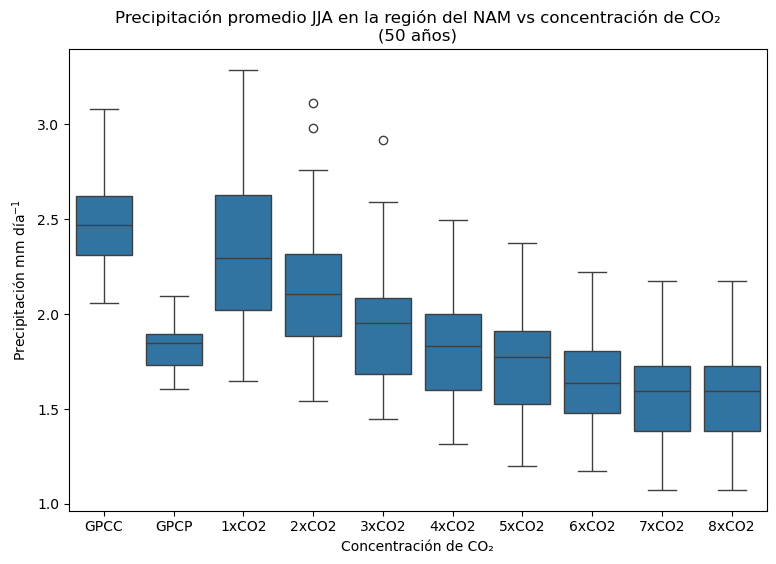

In [114]:
BOXPLOT_JJA_2 = pd.concat([dnoaa, dgcpc,dfJJA, dfJJA1, dfJJA2, dfJJA3, dfJJA4, dfJJA5, dfJJA6, dfJJA7],ignore_index=True)


plt.figure(figsize=(9,6))

sns.boxplot(x="CO2", y="pr_jja", data=BOXPLOT_JJA_2)

plt.xlabel("Concentración de CO₂")
plt.ylabel("Precipitación mm día$^{-1}$")
plt.title("Precipitación promedio JJA en la región del NAM vs concentración de CO₂\n(50 años)")

plt.savefig('Imagenes/Boxplot JJA_1 del NAM (CO2).png', dpi=300, bbox_inches="tight")


plt.show()

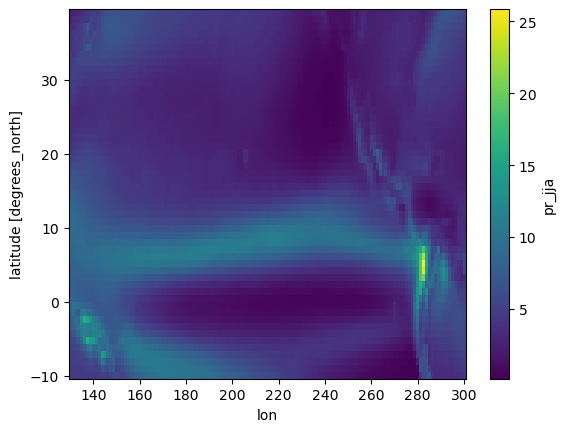

In [115]:
p1_tropical= precip1_jja. assign_coords(lon=(precip1_jja.lon % 360)).sortby("lon")

p1_tropical = p1_tropical.sel(lon=slice(130, 300), lat=slice(-10, 40))
tropical_1=p1_tropical.mean(("year"), skipna= True)
tropical_1.plot()


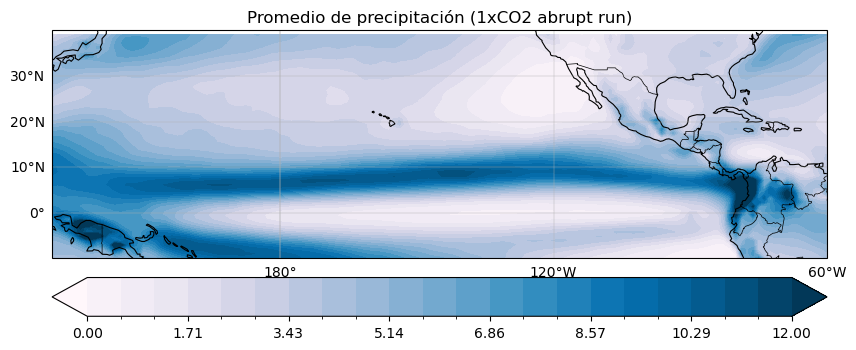

In [116]:
levels = np.linspace(0, 12, 22)

proj = ccrs.PlateCarree(central_longitude=180)
fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": proj})

ax.set_extent([130, 300, -10, 40], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

cf = tropical_1.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=levels,
    add_colorbar=False,
    cmap="PuBu",
    extend="both"
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=tropical_1.attrs.get("units",""))

gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False

ax.set_title("Promedio de precipitación (1xCO2 abrupt run)")
plt.show()

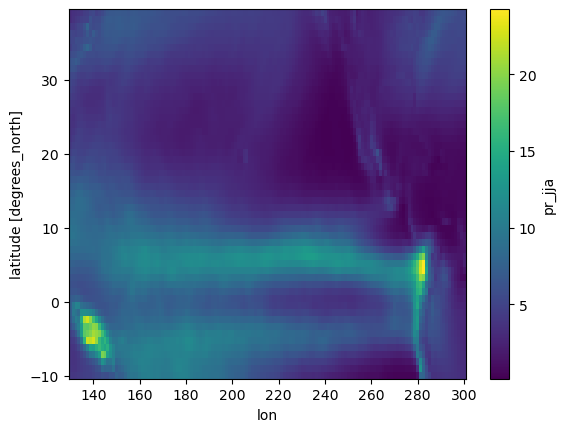

In [117]:



p2_tropical= precip2_jja. assign_coords(lon=(precip2_jja.lon % 360)).sortby("lon")
p2_tropical = p2_tropical.sel(lon=slice(130, 300), lat=slice(-10, 40))
tropical_2=p2_tropical.mean(("year"), skipna= True)


p3_tropical= precip3_jja. assign_coords(lon=(precip3_jja.lon % 360)).sortby("lon")
p3_tropical = p3_tropical.sel(lon=slice(130, 300), lat=slice(-10, 40))
tropical_3=p3_tropical.mean(("year"), skipna= True)



p4_tropical= precip4_jja. assign_coords(lon=(precip4_jja.lon % 360)).sortby("lon")
p4_tropical = p4_tropical.sel(lon=slice(130, 300), lat=slice(-10, 40))
tropical_4=p4_tropical.mean(("year"), skipna= True)



p5_tropical= precip5_jja. assign_coords(lon=(precip5_jja.lon % 360)).sortby("lon")
p5_tropical = p5_tropical.sel(lon=slice(130, 300), lat=slice(-10, 40))
tropical_5=p5_tropical.mean(("year"), skipna= True)




p6_tropical= precip6_jja. assign_coords(lon=(precip6_jja.lon % 360)).sortby("lon")
p6_tropical = p6_tropical.sel(lon=slice(130, 300), lat=slice(-10, 40))
tropical_6=p6_tropical.mean(("year"), skipna= True)




p7_tropical= precip7_jja. assign_coords(lon=(precip7_jja.lon % 360)).sortby("lon")
p7_tropical = p7_tropical.sel(lon=slice(130, 300), lat=slice(-10, 40))
tropical_7=p7_tropical.mean(("year"), skipna= True)




p8_tropical= precip8_jja. assign_coords(lon=(precip8_jja.lon % 360)).sortby("lon")
p8_tropical = p8_tropical.sel(lon=slice(130, 300), lat=slice(-10, 40))
tropical_8=p8_tropical.mean(("year"), skipna= True)
tropical_8.plot()

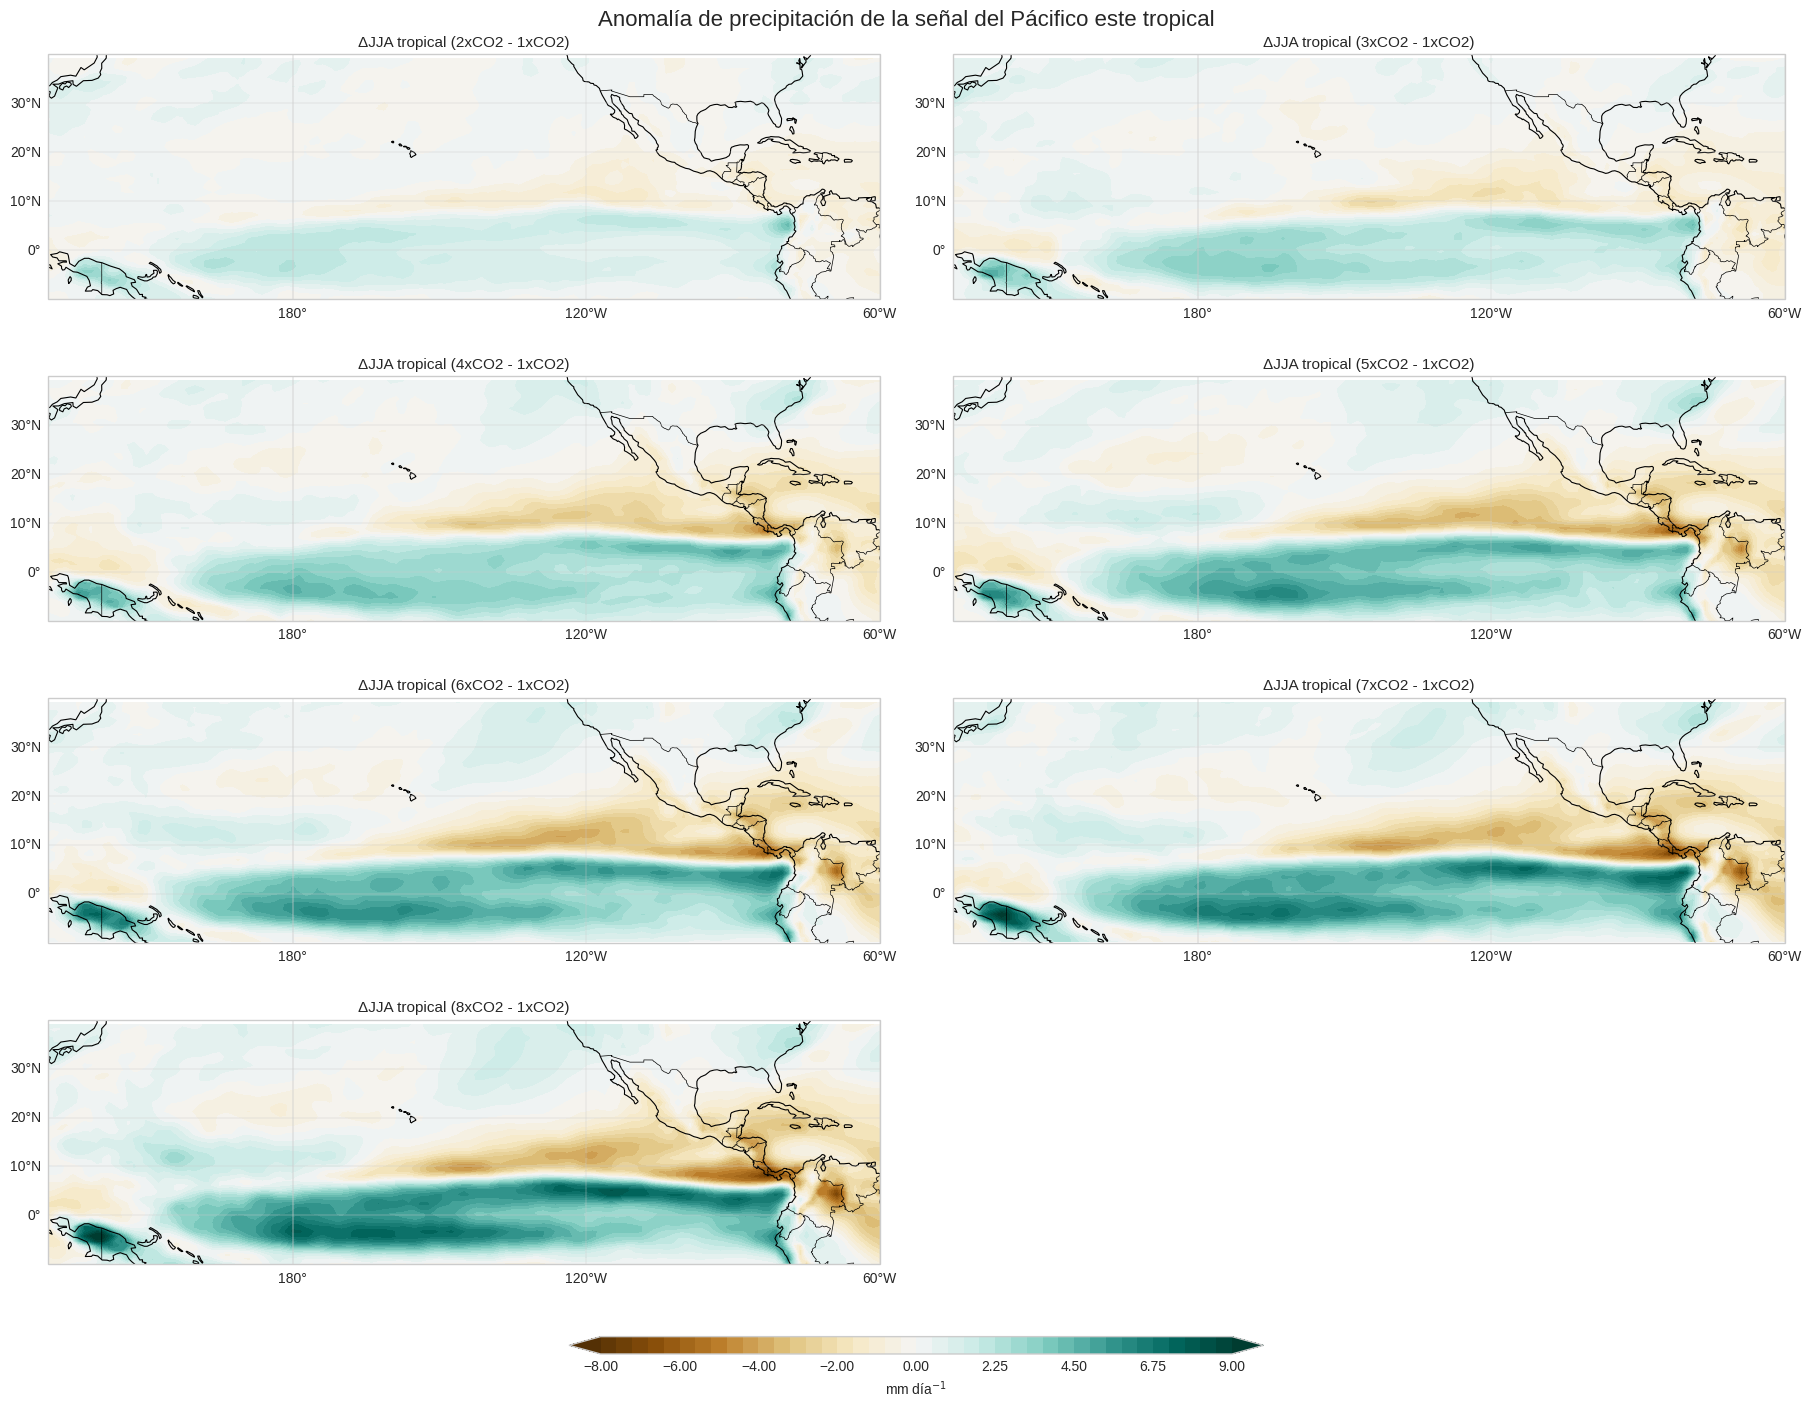

In [223]:
from matplotlib import colors
tropical_cam1 = tropical_2 - tropical_1
tropical_cam2 = tropical_3 - tropical_1
tropical_cam3 = tropical_4 - tropical_1
tropical_cam4 = tropical_5 - tropical_1
tropical_cam5 = tropical_6 - tropical_1
tropical_cam6 = tropical_7 - tropical_1
tropical_cam7 = tropical_8 - tropical_1

cambios_tropical = [tropical_cam1, tropical_cam2, tropical_cam3, tropical_cam4,
                   tropical_cam5, tropical_cam6, tropical_cam7]

titulos = [
    "ΔJJA tropical (2xCO2 - 1xCO2)",
    "ΔJJA tropical (3xCO2 - 1xCO2)",
    "ΔJJA tropical (4xCO2 - 1xCO2)",
    "ΔJJA tropical (5xCO2 - 1xCO2)",
    "ΔJJA tropical (6xCO2 - 1xCO2)",
    "ΔJJA tropical (7xCO2 - 1xCO2)",
    "ΔJJA tropical (8xCO2 - 1xCO2)"
]


levels = np.r_[np.linspace(-8, 0, 21), np.linspace(0, 9, 21)[1:]]
norm = colors.TwoSlopeNorm(vmin=-8, vcenter=0, vmax=9)

# Proyección centrada en 180 para que 130–300 se vea continuo
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    4, 2,
    figsize=(18, 14),
    subplot_kw={"projection": proj},
    constrained_layout=True
)
axes = axes.flatten()

for ax, data, title in zip(axes[:7], cambios_tropical, titulos):

    ax.set_extent([130, 300, -10, 40], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

    cf = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap="BrBG",
        norm=norm,
        add_colorbar=False,
        extend="both"
)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.right_labels = False
    gl.top_labels = False

    ax.set_title(title, fontsize=11)


axes[7].set_visible(False)

cbar = fig.colorbar(
    cf,
    ax=axes[:7],
    orientation="horizontal",
    pad=0.04,
    shrink=0.40,
    fraction=0.02,
    aspect=40
)
cbar.set_label("mm día$^{-1}$")
fig.suptitle("Anomalía de precipitación de la señal del Pácifico este tropical", fontsize=16, y=0.995)

plt.savefig('Imagenes/Diferencias2_8_tropical.png', dpi=300, bbox_inches="tight")
plt.show()

In [119]:
precip16_JJA

<xarray.DataArray 'pr_jja' (year: 51, lat: 16, lon: 8)> Size: 26kB
array([[[0.29062495, 0.36607745, 0.8132153 , ..., 2.386228  ,
         2.7363977 , 3.686999  ],
        [0.22383189, 0.25797996, 0.6840114 , ..., 3.7441268 ,
         4.6054635 , 4.367734  ],
        [0.19060276, 0.22033069, 0.56224215, ..., 4.6486635 ,
         3.1565795 , 2.8666039 ],
        ...,
        [1.0637891 , 1.6851228 , 1.2435626 , ..., 1.5458406 ,
         2.1667926 , 2.4274776 ],
        [1.3438447 , 1.5211694 , 1.3446817 , ..., 1.445802  ,
         2.0382054 , 2.5741549 ],
        [1.5989047 , 1.7952652 , 1.4902235 , ..., 1.519686  ,
         2.0646968 , 2.3685098 ]],

       [[0.10789601, 0.09498885, 0.09616978, ..., 1.3271246 ,
         2.0922499 , 3.300663  ],
        [0.08805004, 0.0869034 , 0.08151429, ..., 2.8903334 ,
         4.5092993 , 4.0817347 ],
        [0.06249089, 0.07043257, 0.0920179 , ..., 3.805595  ,
         3.2616398 , 2.2189481 ],
...
        [1.7649525 , 2.522896  , 2.2316413 , ..., 2.8489823 ,
         3.274362  , 3.1947248 ],
        [2.096407  , 2.4875503 , 2.5368218 , ..., 2.1418982 ,
         2.3874054 , 2.6283414 ],
        [2.1002123 , 3.1912494 , 3.1962564 , ..., 2.1491253 ,
         1.9984983 , 2.2510176 ]],

       [[0.06603272, 0.05370879, 0.06152553, ..., 0.32818326,
         0.75426227, 1.6834196 ],
        [0.03429734, 0.05078259, 0.04555031, ..., 1.0577325 ,
         2.1343365 , 2.5603075 ],
        [0.03813612, 0.03107712, 0.03509412, ..., 2.2454283 ,
         1.8486506 , 1.4638548 ],
        ...,
        [0.66480315, 1.6589216 , 1.1881706 , ..., 1.6576675 ,
         1.8836919 , 2.693515  ],
        [0.9750486 , 1.080652  , 1.0166708 , ..., 1.5128199 ,
         1.5711446 , 3.0647182 ],
        [0.9285863 , 1.2632968 , 1.3144662 , ..., 1.3758534 ,
         1.6797128 , 3.5718086 ]]], shape=(51, 16, 8), dtype=float32)
Coordinates:
  * year     (year) datetime64[ns] 408B 1949-01-01 1950-01-01 ... 1999-01-01
  * lat      (lat) float64 128B 18.38 19.32 20.26 21.2 ... 30.63 31.57 32.51
  * lon      (lon) float64 64B -111.2 -110.0 -108.8 ... -105.0 -103.8 -102.5
Attributes:
    descr:    JJA mean PRECC+PRECCL, convective + large scale precip.
    units:    mm/day
    run::     8xCO2 abrupt run
    model:    CESM1-LENS

In [120]:
precip9_JJA

<xarray.DataArray 'pr_jja' (year: 51, lat: 16, lon: 8)> Size: 26kB
array([[[1.391234  , 1.4880103 , 1.6076605 , ..., 2.6971805 ,
         3.7811177 , 5.2253304 ],
        [1.110335  , 1.1223432 , 1.2747592 , ..., 4.743458  ,
         6.4864664 , 5.8691955 ],
        [0.9602665 , 1.0368196 , 1.1024698 , ..., 5.867056  ,
         5.3002768 , 3.858103  ],
        ...,
        [1.0585625 , 1.172897  , 0.9738318 , ..., 1.0763394 ,
         0.74216557, 0.6305855 ],
        [0.98757535, 0.9196016 , 1.0272056 , ..., 0.97887963,
         0.827234  , 0.6503499 ],
        [0.7233267 , 0.9808912 , 1.3198686 , ..., 0.8063703 ,
         0.80771154, 0.7185412 ]],

       [[0.73796827, 0.99820817, 1.3147564 , ..., 2.5179746 ,
         3.1524773 , 4.5847387 ],
        [0.5171954 , 0.66140944, 1.0167861 , ..., 3.9160068 ,
         5.374324  , 6.046252  ],
        [0.39698893, 0.5437437 , 0.83492583, ..., 5.341019  ,
         5.2356215 , 4.9823885 ],
...
        [0.8745316 , 1.6824456 , 1.1903716 , ..., 0.9430418 ,
         0.87690675, 1.2531496 ],
        [0.7945069 , 1.2437848 , 1.0509117 , ..., 0.71476007,
         0.7016136 , 1.1236755 ],
        [0.5684062 , 1.2598734 , 0.9855996 , ..., 0.81723803,
         0.7548005 , 1.0870165 ]],

       [[2.214892  , 2.0687523 , 1.8675389 , ..., 1.6233138 ,
         1.8686635 , 3.6241102 ],
        [1.7450528 , 1.6784575 , 1.6613533 , ..., 2.7924855 ,
         4.1056795 , 4.9750824 ],
        [1.2826744 , 1.2169253 , 0.9442596 , ..., 4.0199137 ,
         3.8268955 , 3.6883762 ],
        ...,
        [0.3671667 , 0.92502296, 0.90269107, ..., 2.2284315 ,
         2.798255  , 2.9141538 ],
        [0.593831  , 0.7675358 , 0.85734403, ..., 1.8886863 ,
         2.1839347 , 2.6585424 ],
        [0.6088614 , 0.99873066, 1.2103184 , ..., 1.6704282 ,
         2.0374715 , 2.6166358 ]]], shape=(51, 16, 8), dtype=float32)
Coordinates:
  * year     (year) datetime64[ns] 408B 1949-01-01 1950-01-01 ... 1999-01-01
  * lat      (lat) float64 128B 18.38 19.32 20.26 21.2 ... 30.63 31.57 32.51
  * lon      (lon) float64 64B -111.2 -110.0 -108.8 ... -105.0 -103.8 -102.5
Attributes:
    descr:    JJA mean PRECC+PRECCL, convective + large scale precip.
    units:    mm/day
    run::     1xCO2 abrupt run
    model:    CESM1-LENS

In [121]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [122]:
import statsmodels.api as sm

In [123]:
X = precip9_JJA["year"].dt.year.values.astype(float)  


#x = precip9_JJA["year"].dt.year.values.astype(float)
#x0 = x - x.mean()
#X = sm.add_constant(x0)


X=sm.add_constant(X)
Y = precip9_JJA.mean(("lat","lon"), skipna=True)
Y=Y.values.astype(float)
Y

array([1.85408854, 2.39333272, 2.02956009, 2.01937294, 1.94665432,
       2.63093305, 3.28875732, 2.25157046, 1.96248889, 2.84744263,
       3.02987957, 1.94564533, 2.04903412, 1.9625982 , 2.74484897,
       2.80892563, 2.14582348, 1.70810258, 2.42368889, 2.29785252,
       3.0914073 , 2.43925238, 2.05126786, 2.60012341, 1.64764655,
       2.34015036, 3.05283022, 2.1647253 , 1.86351585, 2.63066292,
       2.45257854, 2.94171   , 1.76184034, 1.90368533, 2.90415955,
       2.08539987, 2.39069939, 1.94618976, 2.31127095, 2.47484732,
       2.39198589, 2.23708963, 2.1872766 , 2.58040142, 2.04934263,
       2.77194524, 3.15083504, 2.83817935, 2.20225191, 1.90215635,
       2.13842392])

In [124]:
modelo = sm.OLS(Y, X).fit()

In [125]:
X1 = precip10_JJA["year"].dt.year.values.astype(float)  

X1=sm.add_constant(X1)
Y1 = precip10_JJA.mean(("lat","lon"), skipna=True)
Y1=Y1.values.astype(float)
modelo1 = sm.OLS(Y1, X1).fit()

In [126]:
X2 = precip11_JJA["year"].dt.year.values.astype(float)  

X2=sm.add_constant(X2)
Y2 = precip11_JJA.mean(("lat","lon"), skipna=True)
Y2=Y2.values.astype(float)
modelo2 = sm.OLS(Y2, X2).fit()

In [127]:
X3 = precip12_JJA["year"].dt.year.values.astype(float)  
X3=sm.add_constant(X3)
Y3 = precip12_JJA.mean(("lat","lon"), skipna=True)
Y3=Y3.values.astype(float)
modelo3 = sm.OLS(Y3, X3).fit()

In [128]:
X4 = precip13_JJA["year"].dt.year.values.astype(float)  

X4=sm.add_constant(X4)
Y4 = precip13_JJA.mean(("lat","lon"), skipna=True)
Y4=Y4.values.astype(float)
modelo4 = sm.OLS(Y4, X4).fit()

In [129]:
X5 = precip14_JJA["year"].dt.year.values.astype(float)  

X5=sm.add_constant(X5)
Y5 = precip14_JJA.mean(("lat","lon"), skipna=True)
Y5=Y5.values.astype(float)
modelo5 = sm.OLS(Y5, X5).fit()

In [130]:
X6 = precip15_JJA["year"].dt.year.values.astype(float)  

X6=sm.add_constant(X6)
Y6 = precip15_JJA.mean(("lat","lon"), skipna=True)
Y6=Y6.values.astype(float)
modelo6 = sm.OLS(Y6, X6).fit()

In [131]:
X7 = precip16_JJA["year"].dt.year.values.astype(float)  

X7=sm.add_constant(X7)
Y7 = precip16_JJA.mean(("lat","lon"), skipna=True)
Y7=Y7.values.astype(float)
modelo7 = sm.OLS(Y7, X7).fit()

In [132]:
print(modelo.params)
print(modelo1.params)
print(modelo2.params)
print(modelo3.params)
print(modelo4.params)
print(modelo5.params)
print(modelo6.params)
print(modelo7.params)

[-0.6734342   0.00153157]
[ 8.64252998e+00 -3.29358989e-03]
[-1.40587494e+01  8.10925319e-03]
[ 9.77436572e+00 -4.02578755e-03]
[-1.85886357e+00  1.82340646e-03]
[-6.66208476e+00  4.21035264e-03]
[-6.39534098e+00  4.03939459e-03]
[ 2.00167593e+00 -2.07854008e-04]


In [133]:
pop1 = JJA_GPCC.sel(year=slice("1982", "2020"))

In [134]:
Xgpcc = pop1["year"].year.values.astype(float)  
Xgpcc=sm.add_constant(Xgpcc)
Ygpcc = pop1.mean(("lat","lon"), skipna=True)
Ygpcc=Ygpcc.values.astype(float)
Ygpcc
modelogpcc = sm.OLS(Ygpcc, Xgpcc).fit()

In [135]:
print(modelogpcc.params)

[-9.53734818e+00  6.01693832e-03]


In [136]:
XGPCP = JJA_gcpc["year"].year.values.astype(float) 
XGPCP=sm.add_constant(XGPCP)

In [137]:
YGPCP = JJA_gcpc.mean(("lat","lon"), skipna=True)
YGPCP=YGPCP.values.astype(float)
modeloGPCP = sm.OLS(YGPCP, XGPCP).fit()
print(modeloGPCP.params)

[-0.31333213  0.00106905]


In [138]:

modelos = [modelo, modelo1, modelo2, modelo3, modelo4, modelo5, modelo6, modelo7,
           modelogpcc, modeloGPCP]

simulaciones = ["1xCO2", "2xCO2", "3xCO2", "4xCO2", "5xCO2", "6xCO2", "7xCO2", "8xCO2",
                "GPCC", "GPCP"]


pendientes = [m.params[1] for m in modelos]


Tabla = pd.DataFrame({"Simulación": simulaciones,"Pendiente (mm/día por año) para JJA": pendientes,"Pendiente (mm/día por década) para JJA": [p*10 for p in pendientes]})

Tabla

,Simulación,Pendiente (mm/día por año) para JJA,Pendiente (mm/día por década) para JJA
0,1xCO2,0.001532,0.015316
1,2xCO2,-0.003294,-0.032936
2,3xCO2,0.008109,0.081093
3,4xCO2,-0.004026,-0.040258
4,5xCO2,0.001823,0.018234
5,6xCO2,0.004210,0.042104
6,7xCO2,0.004039,0.040394
7,8xCO2,-0.000208,-0.002079
8,GPCC,0.006017,0.060169
9,GPCP,0.001069,0.010691


In [139]:
precip1_jja

<xarray.DataArray 'pr_jja' (year: 31, lat: 192, lon: 288)> Size: 7MB
array([[[0.13657092, 0.13647382, 0.1364731 , ..., 0.13647574,
         0.13647519, 0.13652153],
        [0.21189103, 0.21130064, 0.21109106, ..., 0.2051883 ,
         0.20808221, 0.21034792],
        [0.17186779, 0.17568474, 0.17879954, ..., 0.15954739,
         0.16310872, 0.16730942],
        ...,
        [0.61577994, 0.6141995 , 0.610339  , ..., 0.6231297 ,
         0.6212686 , 0.61675555],
        [0.7259358 , 0.7235216 , 0.72498256, ..., 0.7212876 ,
         0.722534  , 0.72258884],
        [0.73819774, 0.7387372 , 0.73873997, ..., 0.73822504,
         0.7381351 , 0.73808837]],

       [[0.15835649, 0.15835567, 0.1583554 , ..., 0.15835617,
         0.15835497, 0.1583565 ],
        [0.20971419, 0.20909737, 0.20852648, ..., 0.20429918,
         0.20651361, 0.2077553 ],
        [0.17169239, 0.1766668 , 0.18204214, ..., 0.1572041 ,
         0.16182177, 0.16656789],
...
        [0.5087307 , 0.5036654 , 0.49518758, ..., 0.5228356 ,
         0.5185455 , 0.50993013],
        [0.54769415, 0.5520804 , 0.551023  , ..., 0.5424604 ,
         0.5431513 , 0.54464066],
        [0.46779966, 0.46778762, 0.46779782, ..., 0.4677885 ,
         0.46779686, 0.46779034]],

       [[0.1842833 , 0.1842576 , 0.18427406, ..., 0.1842584 ,
         0.18425786, 0.18428339],
        [0.24340636, 0.24495952, 0.24634   , ..., 0.23819979,
         0.23945639, 0.24131711],
        [0.18813004, 0.19227982, 0.19603443, ..., 0.17542599,
         0.18022794, 0.18429887],
        ...,
        [0.68603724, 0.6835623 , 0.6841013 , ..., 0.6912162 ,
         0.68586665, 0.68346405],
        [0.7556743 , 0.7579824 , 0.7559254 , ..., 0.7501692 ,
         0.74864304, 0.74598026],
        [0.6298154 , 0.6298472 , 0.6298463 , ..., 0.63001287,
         0.6298472 , 0.62987876]]], shape=(31, 192, 288), dtype=float32)
Coordinates:
  * year     (year) datetime64[ns] 248B 1969-01-01 1970-01-01 ... 1999-01-01
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
Attributes:
    descr:    JJA mean PRECC+PRECCL, convective + large scale precip.
    units:    mm/day
    run::     1xCO2 abrupt run
    model:    CESM1-LENS

In [140]:
p1_tropical
NAM1=p1_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))

In [141]:
#p1_tropical
#NAM1

### Parte para las simulaciones de correlacion del pacifico este respecto al NAM, periodo de los ultimos 30 años

In [142]:
## Periodo de estudio 1920 a 1999
p11_jja=pr1.pr_jja
p11_jja = p11_jja.assign_coords(lon=((p11_jja.lon + 180) % 360) - 180).sortby('lon')
p11_jja=p11_jja.sel(year=slice("1920-01-01", "1999-01-01"))


p12_jja=pr2.pr_jja
p12_jja = p12_jja.assign_coords(lon=((p12_jja.lon + 180) % 360) - 180).sortby('lon')
p12_jja=p12_jja.sel(year=slice("1920-01-01", "1999-01-01"))


p13_jja=pr3.pr_jja
p13_jja = p13_jja.assign_coords(lon=((p13_jja.lon + 180) % 360) - 180).sortby('lon')
p13_jja=p13_jja.sel(year=slice("1920-01-01", "1999-01-01"))


p14_jja=pr4.pr_jja
p14_jja = p14_jja.assign_coords(lon=((p14_jja.lon + 180) % 360) - 180).sortby('lon')
p14_jja=p14_jja.sel(year=slice("1920-01-01", "1999-01-01"))


p15_jja=pr5.pr_jja
p15_jja = p15_jja.assign_coords(lon=((p15_jja.lon + 180) % 360) - 180).sortby('lon')
p15_jja=p15_jja.sel(year=slice("1920-01-01", "1999-01-01"))


p16_jja=pr6.pr_jja
p16_jja = p16_jja.assign_coords(lon=((p16_jja.lon + 180) % 360) - 180).sortby('lon')
p16_jja=p16_jja.sel(year=slice("1920-01-01", "1999-01-01"))


p17_jja=pr7.pr_jja
p17_jja = p17_jja.assign_coords(lon=((p17_jja.lon + 180) % 360) - 180).sortby('lon')
p17_jja=p17_jja.sel(year=slice("1920-01-01", "1999-01-01"))


p18_jja=pr8.pr_jja
p18_jja = p18_jja.assign_coords(lon=((p18_jja.lon + 180) % 360) - 180).sortby('lon')
p18_jja=p18_jja.sel(year=slice("1920-01-01", "1999-01-01"))




In [143]:
##Series de tiempo para la region tropical del este para 1920 a 1999

## SIMULACION DE 1 VEZ CO2
pacifico_este_1=p11_jja. assign_coords(lon=(p11_jja.lon % 360)).sortby("lon")
pacifico_este_1=pacifico_este_1.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE1=pacifico_este_1.mean(('lat','lon'))

## SIMULACION DE 2 VECES 

pacifico_este_2=p12_jja. assign_coords(lon=(p12_jja.lon % 360)).sortby("lon")
pacifico_este_2=pacifico_este_2.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE2=pacifico_este_2.mean(('lat','lon'))

## SIMULACION 3 VECES

pacifico_este_3=p13_jja. assign_coords(lon=(p13_jja.lon % 360)).sortby("lon")
pacifico_este_3=pacifico_este_3.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE3=pacifico_este_3.mean(('lat','lon'))

## SIMULACION 4 VECES

pacifico_este_4=p14_jja. assign_coords(lon=(p14_jja.lon % 360)).sortby("lon")
pacifico_este_4=pacifico_este_4.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE4=pacifico_este_4.mean(('lat','lon'))

## SIMULACION 5 VECES

pacifico_este_5=p15_jja. assign_coords(lon=(p15_jja.lon % 360)).sortby("lon")
pacifico_este_5=pacifico_este_5.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE5=pacifico_este_5.mean(('lat','lon'))

## SIMULACION 6 VECES

pacifico_este_6=p16_jja. assign_coords(lon=(p16_jja.lon % 360)).sortby("lon")
pacifico_este_6=pacifico_este_6.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE6=pacifico_este_6.mean(('lat','lon'))

## SIMULACION 7 VECES

pacifico_este_7=p17_jja. assign_coords(lon=(p17_jja.lon % 360)).sortby("lon")
pacifico_este_7=pacifico_este_7.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE7=pacifico_este_7.mean(('lat','lon'))

## SIMULACION 8 VECES

pacifico_este_8=p18_jja. assign_coords(lon=(p18_jja.lon % 360)).sortby("lon")
pacifico_este_8=pacifico_este_8.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE8=pacifico_este_8.mean(('lat','lon'))

In [144]:
NAM1=p11_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON1=NAM1.mean(('lat','lon'))

NAM2=p12_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON2=NAM2.mean(('lat','lon'))

NAM3=p13_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON3=NAM3.mean(('lat','lon'))

NAM4=p14_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON4=NAM4.mean(('lat','lon'))

NAM5=p15_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON5=NAM5.mean(('lat','lon'))

NAM6=p16_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON6=NAM6.mean(('lat','lon'))

NAM7=p17_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON7=NAM7.mean(('lat','lon'))

NAM8=p18_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON8=NAM8.mean(('lat','lon'))


In [145]:
from scipy.stats import pearsonr

##Series de tiempo para la region tropical del este para 30 años

## SIMULACION DE 1 VEZ CO2
pacifico_este_1=precip1_jja. assign_coords(lon=(precip1_jja.lon % 360)).sortby("lon")
pacifico_este_1=pacifico_este_1.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE1=pacifico_este_1.mean(('lat','lon'))

## SIMULACION DE 2 VECES 

pacifico_este_2=precip2_jja. assign_coords(lon=(precip2_jja.lon % 360)).sortby("lon")
pacifico_este_2=pacifico_este_2.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE2=pacifico_este_2.mean(('lat','lon'))

## SIMULACION 3 VECES

pacifico_este_3=precip3_jja. assign_coords(lon=(precip3_jja.lon % 360)).sortby("lon")
pacifico_este_3=pacifico_este_3.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE3=pacifico_este_3.mean(('lat','lon'))

## SIMULACION 4 VECES

pacifico_este_4=precip4_jja. assign_coords(lon=(precip4_jja.lon % 360)).sortby("lon")
pacifico_este_4=pacifico_este_4.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE4=pacifico_este_4.mean(('lat','lon'))

## SIMULACION 5 VECES

pacifico_este_5=precip5_jja. assign_coords(lon=(precip5_jja.lon % 360)).sortby("lon")
pacifico_este_5=pacifico_este_5.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE5=pacifico_este_5.mean(('lat','lon'))

## SIMULACION 6 VECES

pacifico_este_6=precip6_jja. assign_coords(lon=(precip6_jja.lon % 360)).sortby("lon")
pacifico_este_6=pacifico_este_6.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE6=pacifico_este_6.mean(('lat','lon'))

## SIMULACION 7 VECES

pacifico_este_7=precip7_jja. assign_coords(lon=(precip7_jja.lon % 360)).sortby("lon")
pacifico_este_7=pacifico_este_7.sel((lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE7=pacifico_este_7.mean(('lat','lon'))

## SIMULACION 8 VECES

pacifico_este_8=precip8_jja. assign_coords(lon=(precip8_jja.lon % 360)).sortby("lon")
pacifico_este_8=pacifico_este_8.sel(lon=slice(230, 260), lat=slice(0, 8))
PACIFICO_ESTE8=pacifico_este_8.mean(('lat','lon'))

## Simulaciones para la region del NAM (Region que va de -112 a 102 de longitud, y de 18 a 33 de latitud)

NAM1=p1_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON1=NAM1.mean(('lat','lon'))

NAM2=p2_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON2=NAM2.mean(('lat','lon'))

NAM3=p3_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON3=NAM3.mean(('lat','lon'))

NAM4=p4_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON4=NAM4.mean(('lat','lon'))

NAM5=p5_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON5=NAM5.mean(('lat','lon'))

NAM6=p6_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON6=NAM6.mean(('lat','lon'))

NAM7=p7_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON7=NAM7.mean(('lat','lon'))

NAM8=p8_jja.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
MONZON8=NAM8.mean(('lat','lon'))


In [146]:
## Calculo de las correlaciones




lista_pacifico = [PACIFICO_ESTE1, PACIFICO_ESTE2, PACIFICO_ESTE3, PACIFICO_ESTE4,
            PACIFICO_ESTE5, PACIFICO_ESTE6, PACIFICO_ESTE7, PACIFICO_ESTE8]

lista_NAM = [MONZON1, MONZON2, MONZON3, MONZON4,
            MONZON5, MONZON6, MONZON7, MONZON8]

simulacion_CO2 = ["1xCO2","2xCO2","3xCO2","4xCO2","5xCO2","6xCO2","7xCO2","8xCO2"]

rows = []
for CO2,pacifico_lista, NAM_lista in zip(simulacion_CO2, lista_pacifico, lista_NAM):
    # Alinear por año 
    pacifico_lista, NAM_lista= xr.align(pacifico_lista, NAM_lista, join="inner")
    

    pacifico_a = pacifico_lista - pacifico_lista.mean("year")
    NAM_a = NAM_lista - NAM_lista.mean("year")
    
    x = pacifico_a.values.astype(float)
    y = NAM_a.values.astype(float)
    mask = np.isfinite(x) & np.isfinite(y)
    
    r, p = pearsonr(x[mask], y[mask])
    rows.append({"Simulación": CO2, "r": r, "p_value": p, "N": int(mask.sum())})

tabla_correlacion = pd.DataFrame(rows)
tabla_correlacion

,Simulación,r,p_value,N
0,1xCO2,0.263341,0.018268,80
1,2xCO2,0.391535,0.000329,80
2,3xCO2,0.464323,0.000014,80
3,4xCO2,0.119261,0.292031,80
4,5xCO2,0.180947,0.108218,80
5,6xCO2,0.258723,0.020489,80
6,7xCO2,0.420116,0.000105,80
7,8xCO2,0.333016,0.002541,80


In [147]:
precip1_jja

<xarray.DataArray 'pr_jja' (year: 31, lat: 192, lon: 288)> Size: 7MB
array([[[0.13657092, 0.13647382, 0.1364731 , ..., 0.13647574,
         0.13647519, 0.13652153],
        [0.21189103, 0.21130064, 0.21109106, ..., 0.2051883 ,
         0.20808221, 0.21034792],
        [0.17186779, 0.17568474, 0.17879954, ..., 0.15954739,
         0.16310872, 0.16730942],
        ...,
        [0.61577994, 0.6141995 , 0.610339  , ..., 0.6231297 ,
         0.6212686 , 0.61675555],
        [0.7259358 , 0.7235216 , 0.72498256, ..., 0.7212876 ,
         0.722534  , 0.72258884],
        [0.73819774, 0.7387372 , 0.73873997, ..., 0.73822504,
         0.7381351 , 0.73808837]],

       [[0.15835649, 0.15835567, 0.1583554 , ..., 0.15835617,
         0.15835497, 0.1583565 ],
        [0.20971419, 0.20909737, 0.20852648, ..., 0.20429918,
         0.20651361, 0.2077553 ],
        [0.17169239, 0.1766668 , 0.18204214, ..., 0.1572041 ,
         0.16182177, 0.16656789],
...
        [0.5087307 , 0.5036654 , 0.49518758, ..., 0.5228356 ,
         0.5185455 , 0.50993013],
        [0.54769415, 0.5520804 , 0.551023  , ..., 0.5424604 ,
         0.5431513 , 0.54464066],
        [0.46779966, 0.46778762, 0.46779782, ..., 0.4677885 ,
         0.46779686, 0.46779034]],

       [[0.1842833 , 0.1842576 , 0.18427406, ..., 0.1842584 ,
         0.18425786, 0.18428339],
        [0.24340636, 0.24495952, 0.24634   , ..., 0.23819979,
         0.23945639, 0.24131711],
        [0.18813004, 0.19227982, 0.19603443, ..., 0.17542599,
         0.18022794, 0.18429887],
        ...,
        [0.68603724, 0.6835623 , 0.6841013 , ..., 0.6912162 ,
         0.68586665, 0.68346405],
        [0.7556743 , 0.7579824 , 0.7559254 , ..., 0.7501692 ,
         0.74864304, 0.74598026],
        [0.6298154 , 0.6298472 , 0.6298463 , ..., 0.63001287,
         0.6298472 , 0.62987876]]], shape=(31, 192, 288), dtype=float32)
Coordinates:
  * year     (year) datetime64[ns] 248B 1969-01-01 1970-01-01 ... 1999-01-01
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
Attributes:
    descr:    JJA mean PRECC+PRECCL, convective + large scale precip.
    units:    mm/day
    run::     1xCO2 abrupt run
    model:    CESM1-LENS

In [148]:


# Tus nombres ya creados
lista_pacifico = [PACIFICO_ESTE1, PACIFICO_ESTE2, PACIFICO_ESTE3, PACIFICO_ESTE4,
                  PACIFICO_ESTE5, PACIFICO_ESTE6, PACIFICO_ESTE7, PACIFICO_ESTE8]

lista_NAM = [MONZON1, MONZON2, MONZON3, MONZON4,
             MONZON5, MONZON6, MONZON7, MONZON8]

simulacion_CO2 = ["1xCO2","2xCO2","3xCO2","4xCO2","5xCO2","6xCO2","7xCO2","8xCO2"]

def corr_decadas(pac_ts, nam_ts, y0=1920, y1=1999, window=10):


    pac_ts = pac_ts.sel(year=slice(str(y0), str(y1)))
    nam_ts = nam_ts.sel(year=slice(str(y0), str(y1)))
    pac_ts, nam_ts = xr.align(pac_ts, nam_ts, join="inner")

    out = []
    for start in range(y0, y1 + 1, window):
        end = start + window - 1

        pac_w = pac_ts.sel(year=slice(str(start), str(end)))
        nam_w = nam_ts.sel(year=slice(str(start), str(end)))

        pac_w, nam_w = xr.align(pac_w, nam_w, join="inner")

        # anomalías dentro de la década
        pac_a = pac_w - pac_w.mean("year")
        nam_a = nam_w - nam_w.mean("year")

        x = pac_a.values.astype(float)
        y = nam_a.values.astype(float)
        mask = np.isfinite(x) & np.isfinite(y)

        if mask.sum() >= 3:
            r, p = pearsonr(x[mask], y[mask])
        else:
            r, p = np.nan, np.nan

        out.append({
            "Década": f"{start}-{end}",
            "r": r,
            "p_value": p,
            "N": int(mask.sum())
        })
    return out


rows = []
for CO2, pac_ts, nam_ts in zip(simulacion_CO2, lista_pacifico, lista_NAM):
    decs = corr_decadas(pac_ts, nam_ts, y0=1920, y1=1999, window=10)
    for d in decs:
        rows.append({"Simulación": CO2, **d})

tabla_correlacion_decadas = pd.DataFrame(rows)
tabla_correlacion_decadas

,Simulación,Década,r,p_value,N
0,1xCO2,1920-1929,0.470728,0.169717,10
1,1xCO2,1930-1939,-0.160895,0.657012,10
2,1xCO2,1940-1949,0.245976,0.493318,10
3,1xCO2,1950-1959,0.006601,0.985562,10
4,1xCO2,1960-1969,-0.053287,0.883766,10
...,...,...,...,...,...
59,8xCO2,1950-1959,0.337059,0.340894,10
60,8xCO2,1960-1969,-0.220802,0.539863,10
61,8xCO2,1970-1979,0.628916,0.051427,10
62,8xCO2,1980-1989,0.439784,0.203440,10


In [149]:
tabla_correlacion_decadas.to_csv("Imagenes/correlacion_decadas.csv", index=False)

In [150]:


### Calculo para las difeerencias, ya con los promedios dentro de latitud y longitud

norte1=MONZON1.sel(year=slice("1950-01-01", "1999-01-01"))
norte2=MONZON2.sel(year=slice("1950-01-01", "1999-01-01"))
norte3=MONZON3.sel(year=slice("1950-01-01", "1999-01-01"))
norte4=MONZON4.sel(year=slice("1950-01-01", "1999-01-01"))
norte5=MONZON5.sel(year=slice("1950-01-01", "1999-01-01"))
norte6=MONZON6.sel(year=slice("1950-01-01", "1999-01-01"))
norte7=MONZON7.sel(year=slice("1950-01-01", "1999-01-01"))
norte8=MONZON8.sel(year=slice("1950-01-01", "1999-01-01"))

## Calculo para las diferencias del Pacifico este


pacific1= PACIFICO_ESTE1.sel(year=slice("1950-01-01", "1999-01-01"))
pacific2= PACIFICO_ESTE2.sel(year=slice("1950-01-01", "1999-01-01"))
pacific3= PACIFICO_ESTE3.sel(year=slice("1950-01-01", "1999-01-01"))
pacific4= PACIFICO_ESTE4.sel(year=slice("1950-01-01", "1999-01-01"))
pacific5= PACIFICO_ESTE5.sel(year=slice("1950-01-01", "1999-01-01"))
pacific6= PACIFICO_ESTE6.sel(year=slice("1950-01-01", "1999-01-01"))
pacific7= PACIFICO_ESTE7.sel(year=slice("1950-01-01", "1999-01-01"))
pacific8= PACIFICO_ESTE8.sel(year=slice("1950-01-01", "1999-01-01"))


#Diferencias para el NAM

cambio_norte1=norte2-norte1
cambio_norte2= norte3-norte1
cambio_norte3=norte4-norte1
cambio_norte4= norte5-norte1
cambio_norte5=norte6-norte1
cambio_norte6= norte7-norte1
cambio_norte7=norte8-norte1

##Diferencias para el pacifico este

cambio_pac1= pacific2-pacific1
cambio_pac2=pacific3-pacific1
cambio_pac3= pacific4-pacific1
cambio_pac4=pacific5-pacific1
cambio_pac5= pacific6-pacific1
cambio_pac6=pacific7-pacific1
cambio_pac7=pacific8-pacific1


In [151]:
camb_pacifico = [cambio_pac1,cambio_pac2,cambio_pac3, cambio_pac4,cambio_pac5, cambio_pac6, cambio_pac7]

camb_NAM = [cambio_norte1,cambio_norte2,cambio_norte3,cambio_norte4, cambio_norte5, cambio_norte6, cambio_norte7]

sim_CO2 = ["ΔJJA (2xCO2 - 1xCO2)","ΔJJA (3xCO2 - 1xCO2)","ΔJJA (4xCO2 - 1xCO2)",
           "ΔJJA (5xCO2 - 1xCO2)","ΔJJA (6xCO2 - 1xCO2)","ΔJJA (7xCO2 - 1xCO2)","ΔJJA (8xCO2 - 1xCO2)"]

In [152]:
print(camb_pacifico[0].dims, camb_NAM[0].dims)

('year',) ('year',)


In [153]:
cambio_pac1

<xarray.DataArray 'pr_jja' (year: 50)> Size: 200B
array([ 9.2875004e-01,  2.9322772e+00,  1.6273447e+00, -1.1111383e+00,
       -2.0647383e-01,  1.1280711e+00,  2.0881026e+00, -6.7995095e-01,
        4.3578243e+00,  2.8922424e+00, -4.5914793e-01,  1.7442844e+00,
       -2.9777622e-01,  1.1351972e+00,  2.5137346e+00,  1.3018699e+00,
        2.6390700e+00,  1.1131668e+00,  4.8811150e-01, -1.4499664e-01,
       -1.0032036e+00,  4.1568217e+00,  5.6197834e-01,  1.3669565e+00,
        3.9197204e+00,  2.1342716e+00, -6.6034985e-01,  1.2968345e+00,
        1.2512410e+00,  3.1520147e+00,  2.6177835e+00, -3.0195451e-01,
        8.4686041e-01,  9.0582609e-01,  2.3337605e+00,  3.4298656e+00,
        2.5613215e+00,  1.6086102e-03,  1.0377169e-01,  2.8247793e+00,
        2.8944604e+00, -3.2476926e-01,  3.9108872e-01,  2.1568804e+00,
        1.9495196e+00, -9.1778755e-01, -5.0833035e-01,  1.1536727e+00,
        1.4808574e+00, -6.4389992e-01], dtype=float32)
Coordinates:
  * year     (year) datetime64[ns] 400B 1950-01-01 1951-01-01 ... 1999-01-01

In [154]:
cambio_norte1

<xarray.DataArray 'pr_jja' (year: 50)> Size: 200B
array([-0.13808656,  0.5506396 , -0.08079052,  0.11569118, -0.8557086 ,
       -1.5240808 ,  0.06145167, -0.28278577, -0.16516662, -1.2199814 ,
        0.02465844,  0.1737516 ,  0.23113143, -0.67528605, -0.5944028 ,
       -0.34848905,  1.4067513 , -0.3161924 , -0.4610057 , -0.7190671 ,
       -0.3235159 ,  0.36279273, -0.9040481 ,  1.3357307 , -0.12840033,
       -0.71730113, -0.49732327,  0.45586514,  0.12776256, -0.34433842,
       -0.27409554,  0.44940734,  0.21916938, -0.98060894, -0.22261596,
       -0.5620947 , -0.03894866, -0.0654757 , -0.42196846, -0.21481228,
        0.15072966, -0.11563778, -0.72187495, -0.03823233, -0.56033206,
       -1.6064515 , -0.88795435, -0.45114088,  0.07838726,  0.3113892 ],
      dtype=float32)
Coordinates:
  * year     (year) datetime64[ns] 400B 1950-01-01 1951-01-01 ... 1999-01-01

In [155]:


rows = []
for CO_2,este, america in zip(sim_CO2, camb_pacifico, camb_NAM):

    este, america= xr.align(este, america, join="inner")
    

    pacifico_e = este - este.mean("year")
    america_a = america - america.mean("year")
    x = america_a.values.astype(float)
    y = pacifico_e.values.astype(float)
    mask = np.isfinite(x) & np.isfinite(y)
    
    r, p = pearsonr(x[mask], y[mask])
    rows.append({"Simulación": CO_2, "r": r, "p_value": p, "N": int(mask.sum())})

correlacion = pd.DataFrame(rows)
correlacion
    

,Simulación,r,p_value,N
0,ΔJJA (2xCO2 - 1xCO2),0.182163,0.205467,50
1,ΔJJA (3xCO2 - 1xCO2),0.260497,0.067687,50
2,ΔJJA (4xCO2 - 1xCO2),0.367432,0.008666,50
3,ΔJJA (5xCO2 - 1xCO2),0.202291,0.158880,50
4,ΔJJA (6xCO2 - 1xCO2),0.231251,0.106133,50
5,ΔJJA (7xCO2 - 1xCO2),0.403970,0.003622,50
6,ΔJJA (8xCO2 - 1xCO2),0.391821,0.004893,50


## Sacando los promedios para un periodo de 30 años, y depues para un periodo de 50 años

In [156]:
norteamerica1=NAM1.sel(year=slice("1980-01-01", "1999-01-01"))
norteamerica2=NAM2.sel(year=slice("1980-01-01", "1999-01-01"))
norteamerica3=NAM3.sel(year=slice("1980-01-01", "1999-01-01"))
norteamerica4=NAM4.sel(year=slice("1980-01-01", "1999-01-01"))
norteamerica5=NAM5.sel(year=slice("1980-01-01", "1999-01-01"))
norteamerica6=NAM6.sel(year=slice("1980-01-01", "1999-01-01"))
norteamerica7=NAM7.sel(year=slice("1980-01-01", "1999-01-01"))
norteamerica8=NAM8.sel(year=slice("1980-01-01", "1999-01-01"))



In [157]:
señal_pacifico1=pacifico_este_1.sel(year=slice("1980-01-01","1999-01-01"))
señal_pacifico2=pacifico_este_2.sel(year=slice("1980-01-01","1999-01-01"))
señal_pacifico3=pacifico_este_3.sel(year=slice("1980-01-01","1999-01-01"))
señal_pacifico4=pacifico_este_4.sel(year=slice("1980-01-01","1999-01-01"))
señal_pacifico5=pacifico_este_5.sel(year=slice("1980-01-01","1999-01-01"))
señal_pacifico6=pacifico_este_6.sel(year=slice("1980-01-01","1999-01-01"))
señal_pacifico7=pacifico_este_7.sel(year=slice("1980-01-01","1999-01-01"))
señal_pacifico8=pacifico_este_8.sel(year=slice("1980-01-01","1999-01-01"))
                                   

In [158]:
prom_norteamerica1 = float(norteamerica1.mean(skipna=True).values)
prom_norteamerica2 = float(norteamerica2.mean(skipna=True).values)
prom_norteamerica3 = float(norteamerica3.mean(skipna=True).values)
prom_norteamerica4 = float(norteamerica4.mean(skipna=True).values)
prom_norteamerica5 = float(norteamerica5.mean(skipna=True).values)
prom_norteamerica6 = float(norteamerica6.mean(skipna=True).values)
prom_norteamerica7 = float(norteamerica7.mean(skipna=True).values)
prom_norteamerica8 = float(norteamerica8.mean(skipna=True).values)

print("norteamerica1:", prom_norteamerica1)
print("norteamerica2:", prom_norteamerica2)
print("norteamerica3:", prom_norteamerica3)
print("norteamerica4:", prom_norteamerica4)
print("norteamerica5:", prom_norteamerica5)
print("norteamerica6:", prom_norteamerica6)
print("norteamerica7:", prom_norteamerica7)
print("norteamerica8:", prom_norteamerica8)

norteamerica1: 2.358484983444214
norteamerica2: 2.0608255863189697
norteamerica3: 2.0706379413604736
norteamerica4: 1.7689765691757202
norteamerica5: 1.7699825763702393
norteamerica6: 1.7183847427368164
norteamerica7: 1.6630496978759766
norteamerica8: 1.6242313385009766


In [159]:
prom_pacifico1 = float(señal_pacifico1.mean(skipna=True).values)
prom_pacifico2 = float(señal_pacifico2.mean(skipna=True).values)
prom_pacifico3 = float(señal_pacifico3.mean(skipna=True).values)
prom_pacifico4 = float(señal_pacifico4.mean(skipna=True).values)
prom_pacifico5 = float(señal_pacifico5.mean(skipna=True).values)
prom_pacifico6 = float(señal_pacifico6.mean(skipna=True).values)
prom_pacifico7 = float(señal_pacifico7.mean(skipna=True).values)
prom_pacifico8 = float(señal_pacifico8.mean(skipna=True).values)


In [160]:
list_sim_NAM = [prom_norteamerica1,prom_norteamerica2,prom_norteamerica3,prom_norteamerica4,prom_norteamerica5,prom_norteamerica6,prom_norteamerica7,
            prom_norteamerica8]
list_simulaciones = ["1xCO2","2xCO2","3xCO2","4xCO2","5xCO2","6xCO2","7xCO2","8xCO2"]

list_sim_estepacifico=[prom_pacifico1,prom_pacifico2,prom_pacifico3, prom_pacifico4, prom_pacifico5, prom_pacifico6, prom_pacifico7, prom_pacifico8]

In [161]:
puntos = pd.DataFrame({
    "Simulación": list_simulaciones,
    "Pacífico_promedio_30años": list_sim_estepacifico,
    "NAM_promedio_30años": list_sim_NAM
})

puntos

,Simulación,Pacífico_promedio_30años,NAM_promedio_30años
0,1xCO2,3.499300,2.358485
1,2xCO2,4.647065,2.060826
2,3xCO2,5.722812,2.070638
3,4xCO2,6.186832,1.768977
4,5xCO2,6.791306,1.769983
5,6xCO2,7.036786,1.718385
6,7xCO2,8.436631,1.663050
7,8xCO2,8.346086,1.624231


Pearson r (8 puntos) = -0.943, p = 0.000437, N = 8


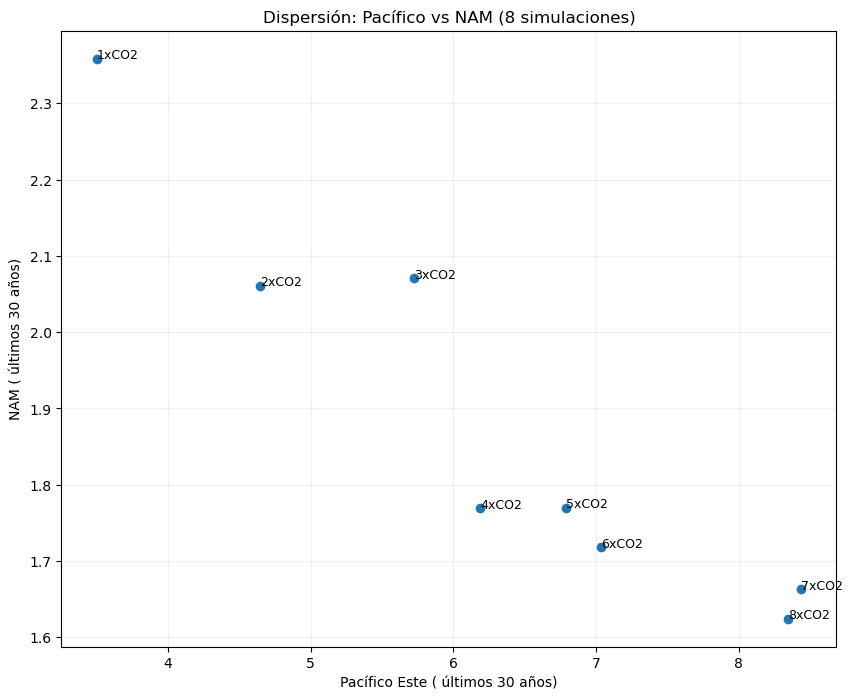

In [162]:
xpac = np.array(list_sim_estepacifico, dtype=float)
ynam = np.array(list_sim_NAM, dtype=float)

mask2 = np.isfinite(xpac) & np.isfinite(ynam)
rl, pl = pearsonr(xpac[mask2], ynam[mask2])

print(f"Pearson r (8 puntos) = {rl:.3f}, p = {pl:.3g}, N = {mask2.sum()}")

plt.figure(figsize=(10,8))
plt.scatter(xpac, ynam)


for name, xi, yi in zip(list_simulaciones, xpac, ynam):
    plt.text(xi, yi, name, fontsize=9)

plt.xlabel("Pacífico Este ( últimos 30 años)")
plt.ylabel("NAM ( últimos 30 años)")
plt.title("Dispersión: Pacífico vs NAM (8 simulaciones)")
plt.grid(True, alpha=0.2)
plt.show()

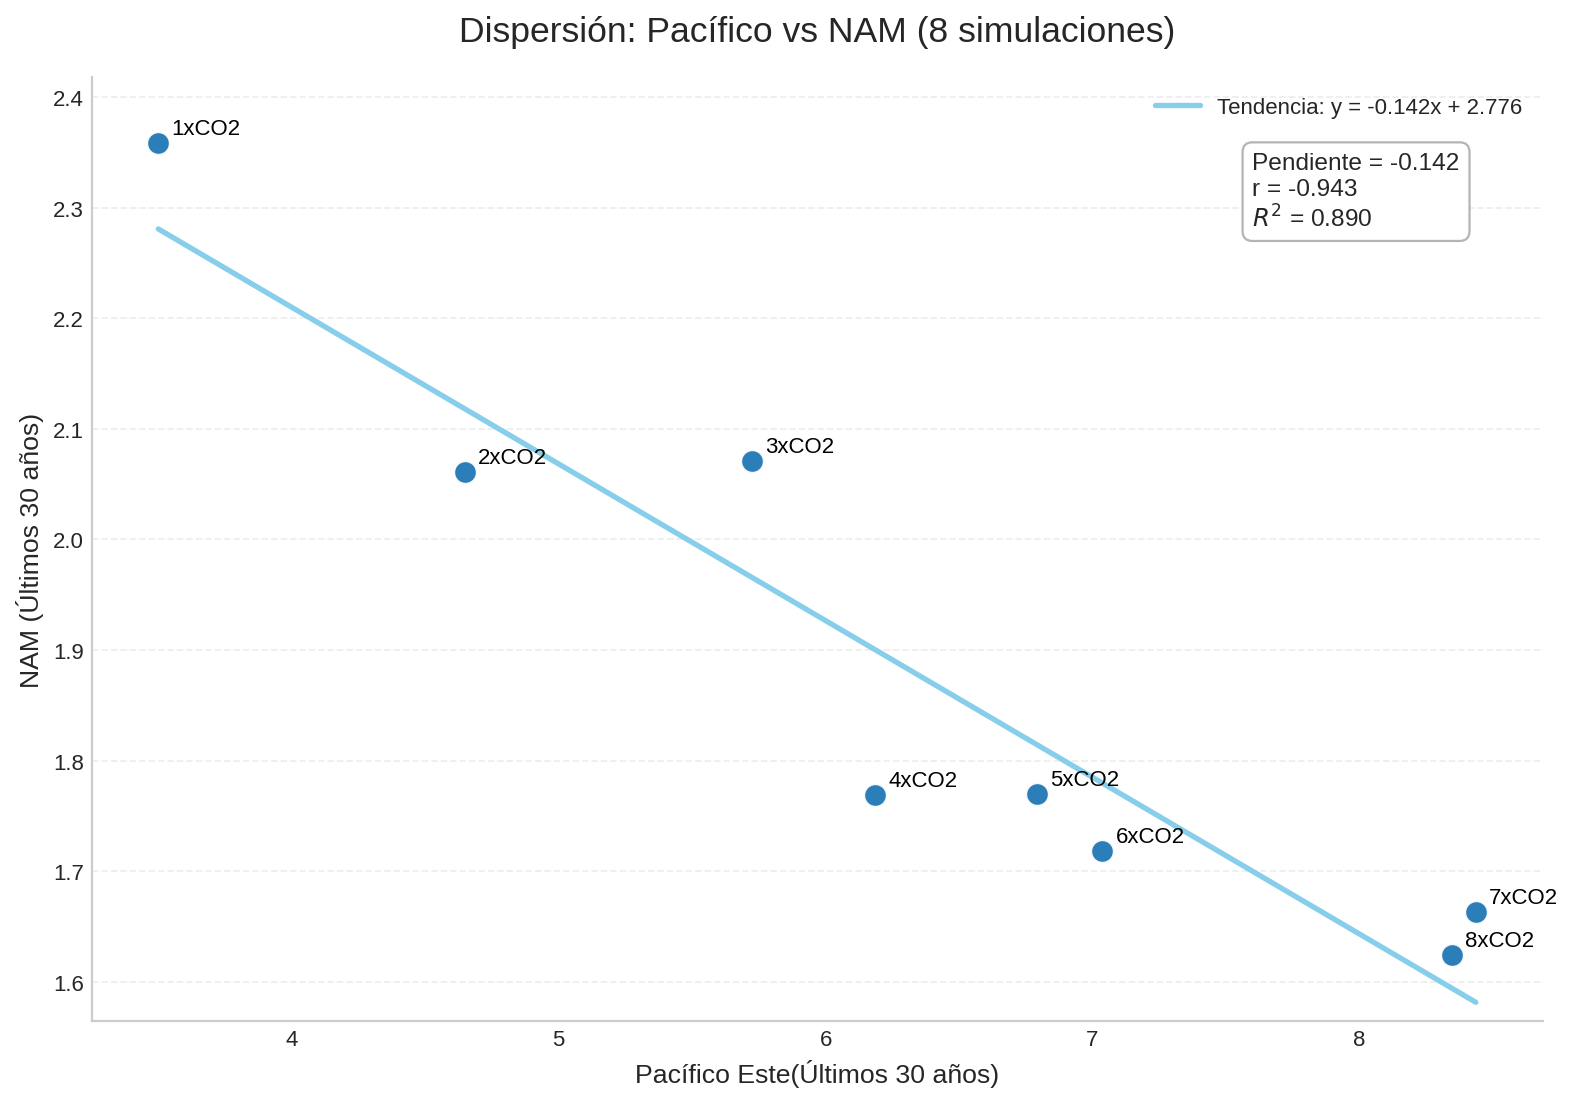

In [163]:


# Convertir a arreglo
xpac_arr = np.array(xpac)
ynam_arr = np.array(ynam)

# Ajuste lineal
m, b = np.polyfit(xpac_arr, ynam_arr, 1)

x_line = np.linspace(min(xpac_arr), max(xpac_arr), 200)
y_line = m * x_line + b

# Predicción y R^2
y_pred = m * xpac_arr + b
ss_res = np.sum((ynam_arr - y_pred)**2)
ss_tot = np.sum((ynam_arr - np.mean(ynam_arr))**2)
r2 = 1 - ss_res / ss_tot

# Coeficiente de correlación de Pearson
r = np.corrcoef(xpac_arr, ynam_arr)[0, 1]

# Estilo
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 7), dpi=160)

# Puntos
ax.scatter(
    xpac_arr, ynam_arr,
    s=110,
    color="#1f77b4",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.95,
    zorder=3
)

# Etiquetas
for name, xi, yi in zip(list_simulaciones, xpac_arr, ynam_arr):
    ax.annotate(
        name,
        (xi, yi),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=10,
        color="black"
    )

# Línea de tendencia
ax.plot(
    x_line, y_line,
    linestyle="-",
    linewidth=2.4,
    color="skyblue",
    label=f"Tendencia: y = {m:.3f}x + {b:.3f}",
    zorder=2
)

# Caja con estadísticas
stats_text = (
    f"Pendiente = {m:.3f}\n"
    f"r = {r:.3f}\n"
    f"$R^2$ = {r2:.3f}"
)
ax.text(
    0.8, 0.92, stats_text,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="#b0b0b0",
        alpha=0.95
    )
)

# Títulos y ejes
ax.set_title(
    "Dispersión: Pacífico vs NAM (8 simulaciones)",
    fontsize=16,
    weight="light",
    pad=16
)
ax.set_xlabel("Pacífico Este(Últimos 30 años)", fontsize=12)
ax.set_ylabel("NAM (Últimos 30 años)", fontsize=12)

# Rejilla y bordes
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Márgenes
x_pad = 0.25
y_pad = 0.06
ax.set_xlim(min(xpac_arr) - x_pad, max(xpac_arr) + x_pad)
ax.set_ylim(min(ynam_arr) - y_pad, max(ynam_arr) + y_pad)

ax.legend(frameon=False, loc="upper right", fontsize=10)

plt.savefig('Imagenes/Grafica_de_dispersion_PacificoVSNAM(30años).png', dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [164]:
X = sm.add_constant(xpac[mask2])
model_2= sm.OLS(ynam[mask2], X).fit()
print(model_2.summary())

m2 = model_2.params[1]  # pendiente
b2 = model_2.params[0]  # intercepto
print("Pendiente m =", m2, "(NAM por unidad de Pacífico)")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     48.44
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           0.000437
Time:                        15:30:54   Log-Likelihood:                 8.8848
No. Observations:                   8   AIC:                            -13.77
Df Residuals:                       6   BIC:                            -13.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7763      0.133     20.886      0.0

In [165]:
model_2.params

array([ 2.77633578, -0.14163338])

### Correlaciones para un periodo de 50 años

In [166]:
norteamerica11=NAM1.sel(year=slice("1950-01-01", "1999-01-01"))
norteamerica21=NAM2.sel(year=slice("1950-01-01", "1999-01-01"))
norteamerica31=NAM3.sel(year=slice("1950-01-01", "1999-01-01"))
norteamerica41=NAM4.sel(year=slice("1950-01-01", "1999-01-01"))
norteamerica51=NAM5.sel(year=slice("1950-01-01", "1999-01-01"))
norteamerica61=NAM6.sel(year=slice("1950-01-01", "1999-01-01"))
norteamerica71=NAM7.sel(year=slice("1950-01-01", "1999-01-01"))
norteamerica81=NAM8.sel(year=slice("1950-01-01", "1999-01-01"))



señal_pacifico11=pacifico_este_1.sel(year=slice("1950-01-01","1999-01-01"))
señal_pacifico21=pacifico_este_2.sel(year=slice("1950-01-01","1999-01-01"))
señal_pacifico31=pacifico_este_3.sel(year=slice("1950-01-01","1999-01-01"))
señal_pacifico41=pacifico_este_4.sel(year=slice("1950-01-01","1999-01-01"))
señal_pacifico51=pacifico_este_5.sel(year=slice("1950-01-01","1999-01-01"))
señal_pacifico61=pacifico_este_6.sel(year=slice("1950-01-01","1999-01-01"))
señal_pacifico71=pacifico_este_7.sel(year=slice("1950-01-01","1999-01-01"))
señal_pacifico81=pacifico_este_8.sel(year=slice("1950-01-01","1999-01-01"))

n_1=float(norteamerica11.mean(("lat","lon"),skipna=True).values)
n_2=float(norteamerica21.mean(("lat","lon"),skipna=True).values)
n_3=float(norteamerica31.mean(("lat","lon"),skipna=True).values)
n_4=float(norteamerica41.mean(("lat","lon"),skipna=True).values)
n_5=float(norteamerica51.mean(("lat","lon"),skipna=True).values)
n_6=float(norteamerica61.mean(("lat","lon"),skipna=True).values)
n_7=float(norteamerica71.mean(("lat","lon"),skipna=True).values)
n_8=float(norteamerica81.mean(("lat","lon"),skipna=True).values)

In [167]:
n_1=norteamerica11.mean(("lat","lon"),skipna=True).values
n_2=norteamerica21.mean(("lat","lon"),skipna=True).values
n_3=norteamerica31.mean(("lat","lon"),skipna=True).values
n_4=norteamerica41.mean(("lat","lon"),skipna=True).values
n_5=norteamerica51.mean(("lat","lon"),skipna=True).values
n_6=norteamerica61.mean(("lat","lon"),skipna=True).values
n_7=norteamerica71.mean(("lat","lon"),skipna=True).values
n_8=norteamerica81.mean(("lat","lon"),skipna=True).values

In [168]:
p_1=señal_pacifico11.mean(("lat","lon"), skipna=True).values
p_2=señal_pacifico21.mean(("lat","lon"), skipna=True).values
p_3=señal_pacifico31.mean(("lat","lon"), skipna=True).values
p_4=señal_pacifico41.mean(("lat","lon"), skipna=True).values
p_5=señal_pacifico51.mean(("lat","lon"), skipna=True).values
p_6=señal_pacifico61.mean(("lat","lon"), skipna=True).values
p_7=señal_pacifico71.mean(("lat","lon"), skipna=True).values
p_8=señal_pacifico81.mean(("lat","lon"), skipna=True).values

In [169]:
n_1

array([2.3933327, 2.02956  , 2.019373 , 1.9466543, 2.630933 , 3.2887573,
       2.2515705, 1.9624889, 2.8474426, 3.0298796, 1.9456453, 2.049034 ,
       1.9625982, 2.744849 , 2.8089256, 2.1458235, 1.7081026, 2.423689 ,
       2.2978525, 3.0914073, 2.4392524, 2.0512679, 2.6001234, 1.6476465,
       2.3401504, 3.0528302, 2.1647253, 1.8635159, 2.630663 , 2.4525785,
       2.94171  , 1.7618403, 1.9036853, 2.9041595, 2.0853999, 2.3906994,
       1.9461898, 2.311271 , 2.4748473, 2.391986 , 2.2370896, 2.1872766,
       2.5804014, 2.0493426, 2.7719452, 3.150835 , 2.8381793, 2.202252 ,
       1.9021564, 2.138424 ], dtype=float32)

In [170]:
n_50 = [n_1, n_2, n_3, n_4, n_5, n_6, n_7, n_8]

p_50 = [p_1, p_2, p_3, p_4, p_5, p_6, p_7, p_8]

N_decada = [arr.reshape(-1, 10).mean(axis=1) for arr in n_50]
P_decada = [arr.reshape(-1, 10).mean(axis=1) for arr in p_50]

In [171]:
filas = []

for sim, p_arr, n_arr in zip(list_simulaciones, P_decada, N_decada):
    for i, (p, n) in enumerate(zip(p_arr, n_arr), start=1):
        filas.append({
            "Simulación": sim,
            "Pacífico_prom": p,
            "NAM_prom": n})

Prom_50 = pd.DataFrame(filas)

Prom_50.to_csv("Imagenes/Datos_CSV/Prom_50.csv",index=False)

In [172]:
Prom_50["Pacífico_prom"].corr(Prom_50["NAM_prom"])

np.float64(-0.8858119879405559)

In [173]:
resumen_corr = Prom_50.groupby("Simulación").apply(lambda df: pd.Series({"Correlación": df["Pacífico_prom"].corr(df["NAM_prom"]),
        "Puntos": len(df)
    })
).reset_index()

resumen_corr.to_csv("Imagenes/Datos_CSV/Correlaciones_50años.csv",index=False)

/tmp/ipykernel_188480/2066507537.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen_corr = Prom_50.groupby("Simulación").apply(lambda df: pd.Series({"Correlación": df["Pacífico_prom"].corr(df["NAM_prom"]),


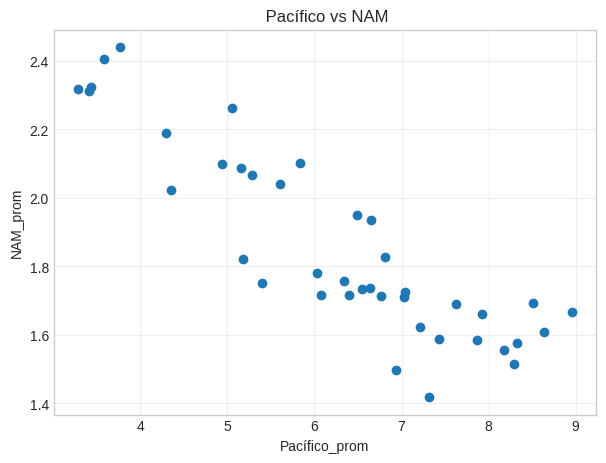

In [174]:
plt.figure(figsize=(7,5))
plt.scatter(Prom_50["Pacífico_prom"], Prom_50["NAM_prom"])

plt.xlabel("Pacífico_prom")
plt.ylabel("NAM_prom")
plt.title(" Pacífico vs NAM")
plt.grid(True, alpha=0.3)
plt.show()

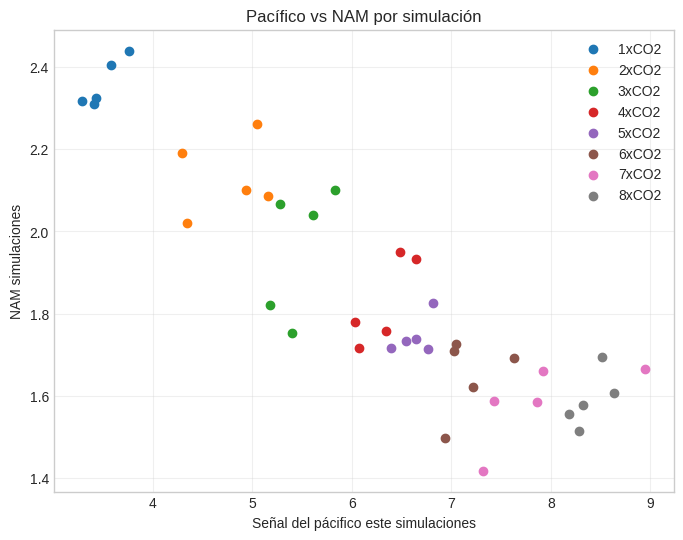

In [175]:
plt.figure(figsize=(8,6))

for sim in Prom_50["Simulación"].unique():
    df = Prom_50[Prom_50["Simulación"] == sim]
    plt.scatter(df["Pacífico_prom"], df["NAM_prom"], label=sim)

plt.xlabel("Señal del pácifico este simulaciones")
plt.ylabel("NAM simulaciones")
plt.title("Pacífico vs NAM por simulación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

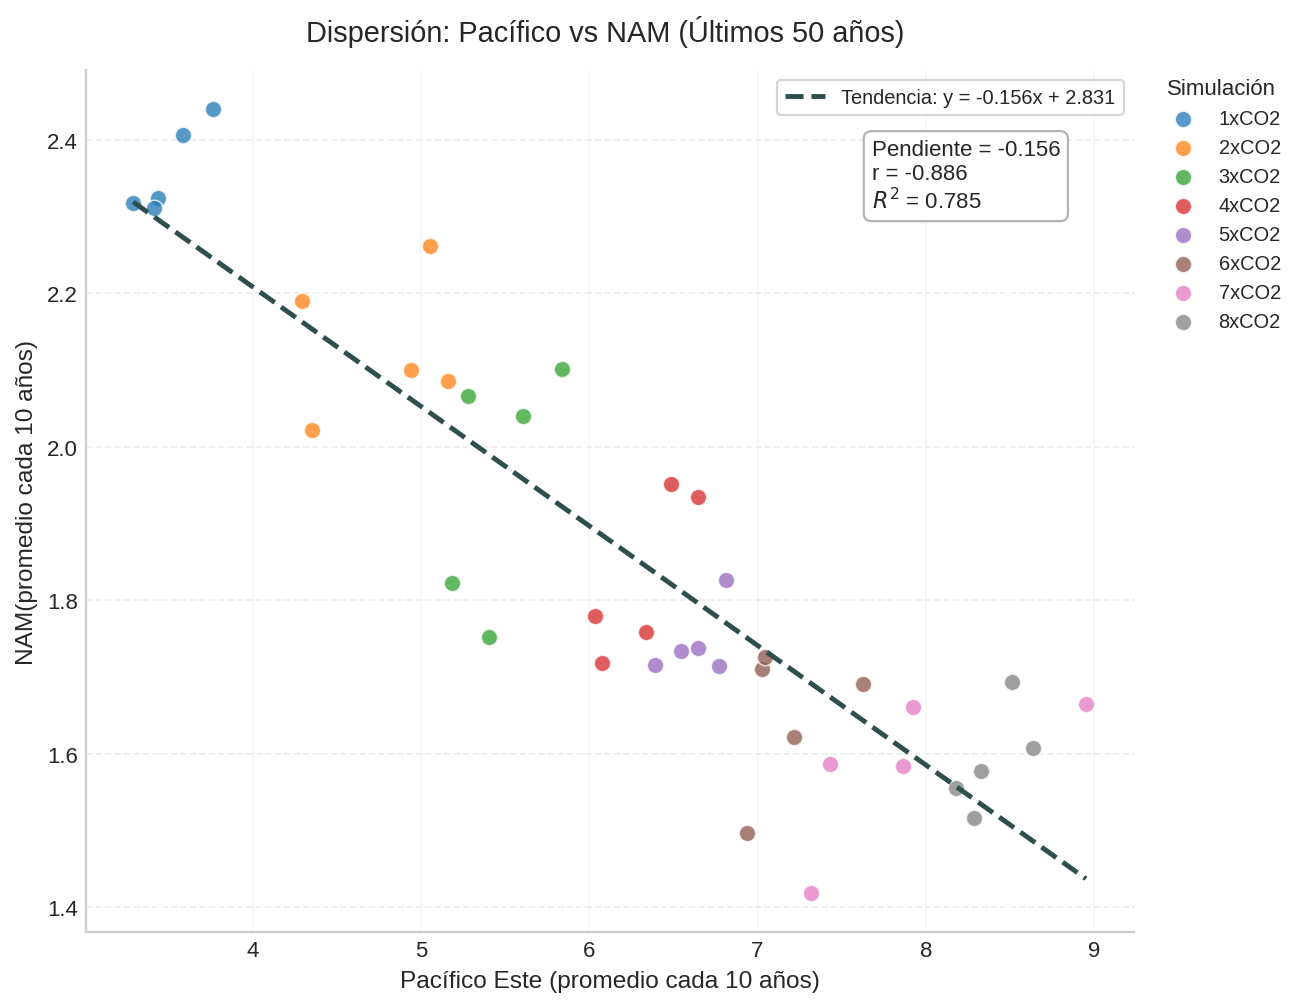

In [176]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 7), dpi=160)


for sim in Prom_50["Simulación"].unique():
    df = Prom_50[Prom_50["Simulación"] == sim]
    ax.scatter(
        df["Pacífico_prom"],
        df["NAM_prom"],
        s=55,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.7,
        label=sim
    )
x = Prom_50["Pacífico_prom"].to_numpy()
y = Prom_50["NAM_prom"].to_numpy()


m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b


r = np.corrcoef(x, y)[0, 1]
y_pred = m * x + b
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot


ax.plot(
    x_line, y_line,
    linestyle="--",
    linewidth=2.2,
    color="darkslategrey",
    label=f"Tendencia: y = {m:.3f}x + {b:.3f}",
    zorder=4
)


ax.set_title("Dispersión: Pacífico vs NAM (Últimos 50 años) ", fontsize=13, weight="light", pad=13)
ax.set_xlabel("Pacífico Este (promedio cada 10 años)", fontsize=11)
ax.set_ylabel("NAM(promedio cada 10 años)", fontsize=11)


ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", alpha=0.15)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


handles, labels = ax.get_legend_handles_labels()
sim_handles = handles[:-1]
sim_labels = labels[:-1]
trend_handle = handles[-1]
trend_label = labels[-1]


legend_sim = ax.legend(
    sim_handles,
    sim_labels,
    title="Simulación",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    fontsize=9,
    title_fontsize=10,
    borderaxespad=0.0
)
ax.add_artist(legend_sim)


ax.legend(
    [trend_handle],
    [trend_label],
    loc="upper right",
    frameon=True,
    fontsize=9
)


stats_text = (
    f"Pendiente = {m:.3f}\n"
    f"r = {r:.3f}\n"
    f"$R^2$ = {r2:.3f}"
)

ax.text(
    0.75, 0.92,
    stats_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="#b0b0b0",
        alpha=0.95
    )
)

plt.subplots_adjust(right=0.78)
plt.savefig(
    'Imagenes/Grafica_de_dispersion_Prom-cada-10años_PacificoVSNAM(50años).png',
    dpi=300,
    bbox_inches="tight",
    bbox_extra_artists=(legend_sim,)
)
plt.show()

### Calculos para la temperatura total y por temporada de JAS

In [177]:
## calculo para jas  1xCO2 abrupt run-CESM1-LENS-mean Surface Temperature


Temperatura1=pr1.astype('float32')


Temperatura1=Temperatura1.assign_coords(lon=(Temperatura1.lon +180)%360-180).sortby('lon')
Temperatura1=Temperatura1.sel(year=slice("1950-01-01", "1999-01-01")) 
Temp1= Temperatura1.sel(lon=slice(-120,-90),lat=slice(15,40))


#Temp1["tas"] = Temp1["tas"] - 273.15
#Temp1["tas"].attrs["units"] = "°C"

#Temp1["tas_jja"]=Temp1["tas_jja"]-273.15
#Temp1["tas_jja"].attrs["units"]= "°C"

tas1=Temp1['tas']
tasjja1= Temp1['tas_jja']

TAS1=tas1.mean(("year"),skipna=True)
TASJJA1= tasjja1.mean(("year"),skipna= True)



In [178]:
## calculo para jas  2xCO2 abrupt run-CESM1-LENS-mean Surface Temperature


Temperatura2=pr2.astype('float32')


Temperatura2=Temperatura2.assign_coords(lon=(Temperatura2.lon +180)%360-180).sortby('lon')
Temperatura2=Temperatura2.sel(year=slice("1950-01-01", "1999-01-01")) 
Temp2= Temperatura2.sel(lon=slice(-120,-90),lat=slice(15,40))


#Temp2["tas"] = Temp2["tas"] - 273.15
#Temp2["tas"].attrs["units"] = "°C"

#Temp2["tas_jja"]=Temp2["tas_jja"]-273.15
#Temp2["tas_jja"].attrs["units"]= "°C"

tas2=Temp2['tas']
tasjja2= Temp2['tas_jja']

TAS2=tas2.mean(("year"),skipna=True)
TASJJA2= tasjja2.mean(("year"),skipna= True)


In [179]:
## calculo para jas  2xCO2 abrupt run-CESM1-LENS-mean Surface Temperature


Temperatura2=pr2.astype('float32')


Temperatura2=Temperatura2.assign_coords(lon=(Temperatura2.lon +180)%360-180).sortby('lon')
Temperatura2=Temperatura2.sel(year=slice("1950-01-01", "1999-01-01")) 
Temp2= Temperatura2.sel(lon=slice(-120,-90),lat=slice(15,40))


#Temp2["tas"] = Temp2["tas"] - 273.15
#Temp2["tas"].attrs["units"] = "°C"

#Temp2["tas_jja"]=Temp2["tas_jja"]-273.15
#Temp2["tas_jja"].attrs["units"]= "°C"

tas2=Temp2['tas']
tasjja2= Temp2['tas_jja']

TAS2=tas2.mean(("year"),skipna=True)
TASJJA2= tasjja2.mean(("year"),skipna= True)


In [180]:
## calculo para jas  3xCO2 abrupt run-CESM1-LENS-mean Surface Temperature


Temperatura3=pr3.astype('float32')


Temperatura3=Temperatura3.assign_coords(lon=(Temperatura3.lon +180)%360-180).sortby('lon')
Temperatura3=Temperatura3.sel(year=slice("1950-01-01", "1999-01-01")) 
Temp3= Temperatura3.sel(lon=slice(-120,-90),lat=slice(15,40))


#Temp3["tas"] = Temp3["tas"] - 273.15
#Temp3["tas"].attrs["units"] = "°C"

#Temp3["tas_jja"]=Temp3["tas_jja"]-273.15
#Temp3["tas_jja"].attrs["units"]= "°C"

tas3=Temp3['tas']
tasjja3= Temp3['tas_jja']

TAS3=tas3.mean(("year"),skipna=True)
TASJJA3= tasjja3.mean(("year"),skipna= True)


In [181]:
## calculo para jas  4xCO2 abrupt run-CESM1-LENS-mean Surface Temperature


Temperatura4=pr4.astype('float32')


Temperatura4=Temperatura4.assign_coords(lon=(Temperatura4.lon +180)%360-180).sortby('lon')
Temperatura4=Temperatura4.sel(year=slice("1950-01-01", "1999-01-01")) 
Temp4= Temperatura4.sel(lon=slice(-120,-90),lat=slice(15,40))


#Temp4["tas"] = Temp4["tas"] - 273.15
#Temp4["tas"].attrs["units"] = "°C"

#Temp4["tas_jja"]=Temp4["tas_jja"]-273.15
#Temp4["tas_jja"].attrs["units"]= "°C"

tas4=Temp4['tas']
tasjja4= Temp4['tas_jja']

TAS4=tas4.mean(("year"),skipna=True)
TASJJA4= tasjja4.mean(("year"),skipna= True)


In [182]:
## calculo para jas  5xCO2 abrupt run-CESM1-LENS-mean Surface Temperature


Temperatura5=pr5.astype('float32')


Temperatura5=Temperatura5.assign_coords(lon=(Temperatura5.lon +180)%360-180).sortby('lon')
Temperatura5=Temperatura5.sel(year=slice("1950-01-01", "1999-01-01")) 
Temp5= Temperatura5.sel(lon=slice(-120,-90),lat=slice(15,40))


#Temp5["tas"] = Temp5["tas"] - 273.15
#Temp5["tas"].attrs["units"] = "°C"

#Temp5["tas_jja"]=Temp5["tas_jja"]-273.15
#Temp5["tas_jja"].attrs["units"]= "°C"

tas5=Temp5['tas']
tasjja5= Temp5['tas_jja']

TAS5=tas5.mean(("year"),skipna=True)
TASJJA5= tasjja5.mean(("year"),skipna= True)


In [183]:
## calculo para jas  6xCO2 abrupt run-CESM1-LENS-mean Surface Temperature


Temperatura6=pr6.astype('float32')


Temperatura6=Temperatura6.assign_coords(lon=(Temperatura6.lon +180)%360-180).sortby('lon')
Temperatura6=Temperatura6.sel(year=slice("1950-01-01", "1999-01-01")) 
Temp6= Temperatura6.sel(lon=slice(-120,-90),lat=slice(15,40))


#Temp6["tas"] = Temp6["tas"] - 273.15
#Temp6["tas"].attrs["units"] = "°C"

#Temp6["tas_jja"]=Temp6["tas_jja"]-273.15
#Temp6["tas_jja"].attrs["units"]= "°C"

tas6=Temp6['tas']
tasjja6= Temp6['tas_jja']

TAS6=tas6.mean(("year"),skipna=True)
TASJJA6= tasjja6.mean(("year"),skipna= True)


In [184]:
## calculo para jas  7xCO2 abrupt run-CESM1-LENS-mean Surface Temperature


Temperatura7=pr7.astype('float32')


Temperatura7=Temperatura7.assign_coords(lon=(Temperatura7.lon +180)%360-180).sortby('lon')
Temperatura7=Temperatura7.sel(year=slice("1950-01-01", "1999-01-01")) 
Temp7= Temperatura7.sel(lon=slice(-120,-90),lat=slice(15,40))


#Temp7["tas"] = Temp7["tas"] - 273.15
#Temp7["tas"].attrs["units"] = "°C"

#Temp7["tas_jja"]=Temp7["tas_jja"]-273.15
#Temp7["tas_jja"].attrs["units"]= "°C"

tas7=Temp7['tas']
tasjja7= Temp7['tas_jja']

TAS7=tas7.mean(("year"),skipna=True)
TASJJA7= tasjja7.mean(("year"),skipna= True)


In [185]:
## calculo para jas  8xCO2 abrupt run-CESM1-LENS-mean Surface Temperature


Temperatura8=pr8.astype('float32')


Temperatura8=Temperatura8.assign_coords(lon=(Temperatura8.lon +180)%360-180).sortby('lon')
Temperatura8=Temperatura8.sel(year=slice("1950-01-01", "1999-01-01")) 
Temp8= Temperatura8.sel(lon=slice(-120,-90),lat=slice(15,40))


#Temp8["tas"] = Temp8["tas"] - 273.15
#Temp8["tas"].attrs["units"] = "°C"

#Temp8["tas_jja"]=Temp8["tas_jja"]-273.15
#Temp8["tas_jja"].attrs["units"]= "°C"

tas8=Temp8['tas']
tasjja8= Temp8['tas_jja']

TAS8=tas8.mean(("year"),skipna=True)
TASJJA8= tasjja8.mean(("year"),skipna= True)


In [186]:
cambiot1=TASJJA2-TASJJA1
cambiot2=TASJJA3-TASJJA1
cambiot3=TASJJA4-TASJJA1
cambiot4=TASJJA5-TASJJA1
cambiot5=TASJJA6-TASJJA1
cambiot6=TASJJA7-TASJJA1
cambiot7=TASJJA8-TASJJA1

In [187]:
## Promedio de temperatura durante 50 años para la region del NAM

JJA1temperatura=tasjja1.mean(('lat','lon'))

JJA2temperatura=tasjja2.mean(('lat','lon'))

JJA3temperatura=tasjja3.mean(('lat','lon'))

JJA4temperatura=tasjja4.mean(('lat','lon'))

JJA5temperatura=tasjja5.mean(('lat','lon'))

JJA6temperatura=tasjja6.mean(('lat','lon'))

JJA7temperatura=tasjja7.mean(('lat','lon'))

JJA8temperatura=tasjja8.mean(('lat','lon'))

In [188]:
JJA5temperatura

<xarray.DataArray 'tas_jja' (year: 50)> Size: 200B
array([298.73535, 298.65042, 298.22015, 298.9624 , 298.62473, 298.38977,
       298.72507, 298.09662, 298.43695, 299.17548, 298.5853 , 299.0339 ,
       298.7069 , 298.72113, 298.76   , 299.17114, 298.48566, 298.8003 ,
       298.896  , 298.80902, 298.83063, 299.33728, 299.3593 , 298.9588 ,
       298.33304, 298.5207 , 299.09314, 298.92618, 299.14526, 299.24255,
       298.78574, 299.00815, 299.2536 , 299.12122, 298.76465, 299.19626,
       298.90558, 298.35117, 298.9794 , 299.16544, 299.00583, 298.78754,
       298.53232, 299.43066, 299.51126, 299.24048, 298.55917, 298.9944 ,
       298.7471 , 298.9688 ], dtype=float32)
Coordinates:
  * year     (year) datetime64[ns] 400B 1950-01-01 1951-01-01 ... 1999-01-01

In [189]:
diferencia1=JJA2temperatura-JJA1temperatura
diferencia2=JJA3temperatura-JJA1temperatura
diferencia3=JJA4temperatura-JJA1temperatura
diferencia4=JJA5temperatura-JJA1temperatura
diferencia5=JJA6temperatura-JJA1temperatura
diferencia6=JJA7temperatura-JJA1temperatura
diferencia7=JJA8temperatura-JJA1temperatura

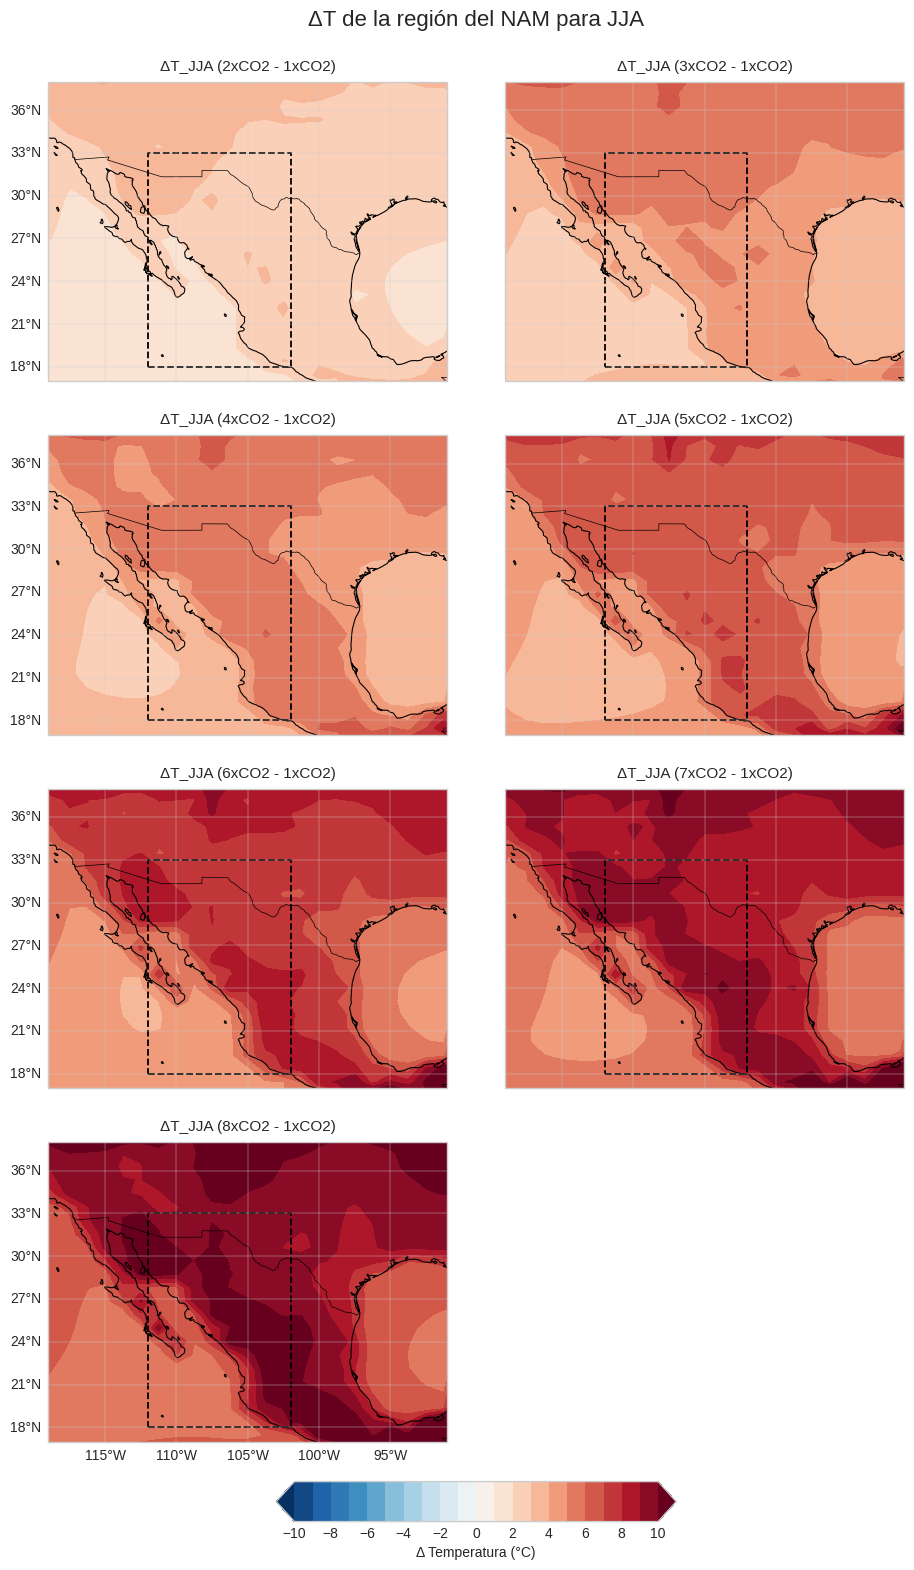

In [206]:
CambiosTemperaturaJAS = [cambiot1, cambiot2, cambiot3, cambiot4, cambiot5, cambiot6, cambiot7]

titulos = [
    "ΔT_JJA (2xCO2 - 1xCO2)",
    "ΔT_JJA (3xCO2 - 1xCO2)",
    "ΔT_JJA (4xCO2 - 1xCO2)",
    "ΔT_JJA (5xCO2 - 1xCO2)",
    "ΔT_JJA (6xCO2 - 1xCO2)",
    "ΔT_JJA (7xCO2 - 1xCO2)",
    "ΔT_JJA (8xCO2 - 1xCO2)"
]


levels = np.linspace(-10, 10, 21)

fig, axes = plt.subplots(
    4, 2,
    figsize=(10, 16),   
    subplot_kw={"projection": ccrs.PlateCarree()}
)

plt.subplots_adjust(
    left=0.06,
    right=0.94,
    top=0.95,
    bottom=0.10,
    wspace=0.08,        
    hspace=0.18
)

axes = axes.flatten()

for i, (ax, data, title) in enumerate(zip(axes, CambiosTemperaturaJAS, titulos)):
    ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

    cf = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap="RdBu_r",
        add_colorbar=False,
        extend="both"
    )

    # Caja de la región NAM
    ax.plot(
        [-112, -102, -102, -112, -112],
        [18, 18, 33, 33, 18],
        transform=ccrs.PlateCarree(),
        linestyle="--",
        linewidth=1.3,
        color="k"
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 6)

    ax.set_title(title, fontsize=11, pad=8)

# Eliminar panel vacío
for j in range(len(CambiosTemperaturaJAS), len(axes)):
    fig.delaxes(axes[j])


cax = fig.add_axes([0.30, 0.05, 0.40, 0.025])
cbar = fig.colorbar(
    cf,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(-10, 11, 2)
)
cbar.set_label("Δ Temperatura (°C)")
fig.suptitle("ΔT de la región del NAM para JJA", fontsize=16, y=0.995)
plt.savefig('Imagenes/Delta_T_repecto_1xCO2.png', dpi=300, bbox_inches="tight")

plt.show()

In [191]:
### Diferencias de temperatura 


diferencia_temperatura=[diferencia1,diferencia2,diferencia3,diferencia4,
                       diferencia5,diferencia6,diferencia7]
camb_NAM

[<xarray.DataArray 'pr_jja' (year: 50)> Size: 200B
 array([-0.13808656,  0.5506396 , -0.08079052,  0.11569118, -0.8557086 ,
        -1.5240808 ,  0.06145167, -0.28278577, -0.16516662, -1.2199814 ,
         0.02465844,  0.1737516 ,  0.23113143, -0.67528605, -0.5944028 ,
        -0.34848905,  1.4067513 , -0.3161924 , -0.4610057 , -0.7190671 ,
        -0.3235159 ,  0.36279273, -0.9040481 ,  1.3357307 , -0.12840033,
        -0.71730113, -0.49732327,  0.45586514,  0.12776256, -0.34433842,
        -0.27409554,  0.44940734,  0.21916938, -0.98060894, -0.22261596,
        -0.5620947 , -0.03894866, -0.0654757 , -0.42196846, -0.21481228,
         0.15072966, -0.11563778, -0.72187495, -0.03823233, -0.56033206,
        -1.6064515 , -0.88795435, -0.45114088,  0.07838726,  0.3113892 ],
       dtype=float32)
 Coordinates:
   * year     (year) datetime64[ns] 400B 1950-01-01 1951-01-01 ... 1999-01-01,
 <xarray.DataArray 'pr_jja' (year: 50)> Size: 200B
 array([-0.9463452 , -0.07441175, -0.50956476, -0.36

In [192]:
tem1=tasjja1.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
tem2=tasjja2.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
tem3=tasjja3.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
tem4=tasjja4.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
tem5=tasjja5.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
tem6=tasjja6.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
tem7=tasjja7.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
tem8=tasjja8.sel(lon=slice(-112, -102 ), lat=slice(18, 33))

In [193]:
TEM1=tem1.mean(('lat','lon'), skipna=True).values
TEM2=tem2.mean(('lat','lon'), skipna=True).values
TEM3=tem3.mean(('lat','lon'),skipna=True).values
TEM4=tem4.mean(('lat','lon'),skipna=True).values
TEM5=tem5.mean(('lat','lon'),skipna=True).values
TEM6=tem6.mean(('lat','lon'),skipna=True).values
TEM7=tem7.mean(('lat','lon'),skipna=True).values
TEM8=tem8.mean(('lat','lon'),skipna=True).values

In [194]:
dif1=TEM2-TEM1
dif2=TEM3-TEM1
dif3=TEM4-TEM1
dif4=TEM5-TEM1
dif5=TEM6-TEM1
dif6=TEM7-TEM1
dif7=TEM8-TEM1

In [195]:
DIF_tem=[dif1,dif2,dif3,dif4,dif5,dif6,dif7]

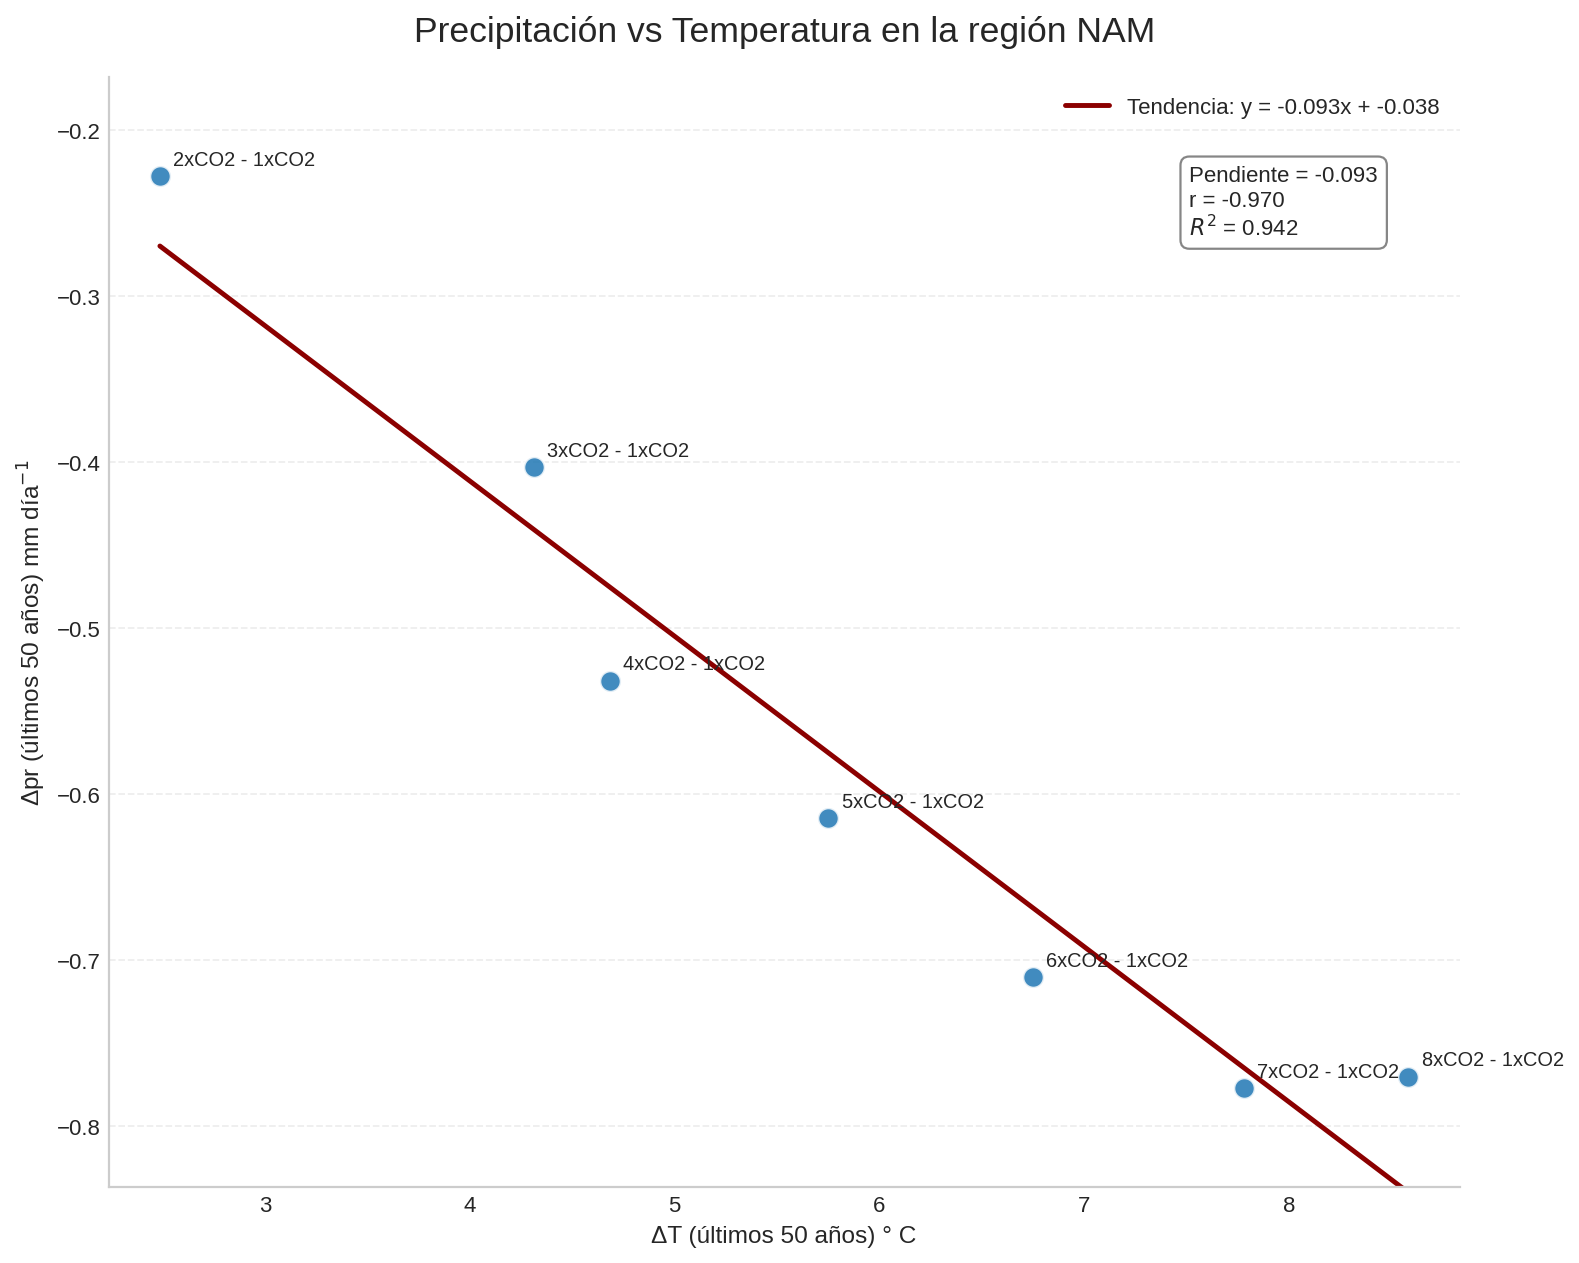

In [196]:
labels = [
    "2xCO2 - 1xCO2",
    "3xCO2 - 1xCO2",
    "4xCO2 - 1xCO2",
    "5xCO2 - 1xCO2",
    "6xCO2 - 1xCO2",
    "7xCO2 - 1xCO2",
    "8xCO2 - 1xCO2"
]

# Convertir cada elemento a un valor escalar
delta_t = np.array([float(d.mean()) for d in DIF_tem])
delta_pr = np.array([float(d.mean()) for d in camb_NAM])

# Ajuste lineal
m, b = np.polyfit(delta_t, delta_pr, 1)
x_line = np.linspace(delta_t.min(), delta_t.max(), 200)
y_line = m * x_line + b

# Correlación
r = np.corrcoef(delta_t, delta_pr)[0, 1]
r2 = r**2

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 8), dpi=160)

ax.scatter(
    delta_t, delta_pr,
    s=90,
    color="#1f77b4",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.85,
    zorder=3
)



for lab, x, y in zip(labels, delta_t, delta_pr):
    ax.annotate(lab, (x, y), xytext=(6, 5), textcoords="offset points", fontsize=9)

ax.plot(
    x_line, y_line,
    "-",
    linewidth=2.2,
    color="darkred",
    label=f"Tendencia: y = {m:.3f}x + {b:.3f}",
    zorder=2
)



ax.text(
    0.8, 0.92,
    f"Pendiente = {m:.3f}\nr = {r:.3f}\n$R^2$ = {r2:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4",facecolor="white", edgecolor="gray", alpha=0.95)
)

ax.set_title("Precipitación vs Temperatura en la región NAM",
                fontsize=16,
    weight="light",
    pad=16)

ax.set_xlabel("ΔT (últimos 50 años) ° C",fontsize=11)
ax.set_ylabel("Δpr (últimos 50 años) mm día$^{-1}$",fontsize=11)


# Rejilla y bordes
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Márgenes
x_pad = 0.25
y_pad = 0.06
ax.set_xlim(delta_t.min() - x_pad, delta_t.max() + x_pad)
ax.set_ylim(delta_pr.min() - y_pad, delta_pr.max() + y_pad)

ax.legend(frameon=False, loc="upper right", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.savefig('Imagenes/Disperison_Diferencia_precipitacion_temperatura.png', dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()

In [197]:
Temp1

<xarray.Dataset> Size: 1MB
Dimensions:     (year: 50, lat: 26, lon: 25)
Coordinates:
  * year        (year) datetime64[ns] 400B 1950-01-01 1951-01-01 ... 1999-01-01
  * lat         (lat) float64 208B 15.55 16.49 17.43 18.38 ... 37.23 38.17 39.11
  * lon         (lon) float64 200B -120.0 -118.8 -117.5 ... -92.5 -91.25 -90.0
Data variables:
    pr          (year, lat, lon) float32 130kB 2.685 2.818 2.909 ... 2.474 2.561
    pr_djf      (year, lat, lon) float32 130kB 2.836 3.127 3.383 ... 2.659 2.617
    pr_jja      (year, lat, lon) float32 130kB 2.401 2.753 3.047 ... 2.928 2.853
    pr_max      (year, lat, lon) float32 130kB 31.12 41.35 39.74 ... 48.36 62.35
    pr_max_djf  (year, lat, lon) float32 130kB 23.78 20.32 38.58 ... 28.85 28.61
    pr_max_jja  (year, lat, lon) float32 130kB 26.73 37.1 39.74 ... 29.82 37.26
    tas         (year, lat, lon) float32 130kB 299.2 299.3 299.4 ... 285.0 285.1
    tas_djf     (year, lat, lon) float32 130kB 299.2 299.3 299.4 ... 284.7 284.8
    tas_jja     (year, lat, lon) float32 130kB 299.2 299.3 299.4 ... 285.1 285.2
    weight      (lat, lon) float32 3kB 1.521 1.521 1.521 ... 1.225 1.225 1.225

In [198]:
precipitacion_max1=Temp1['pr_max_jja']
precipitacion_max2=Temp2['pr_max_jja']
precipitacion_max3=Temp3['pr_max_jja']
precipitacion_max4=Temp4['pr_max_jja']
precipitacion_max5=Temp5['pr_max_jja']
precipitacion_max6=Temp6['pr_max_jja']
precipitacion_max7=Temp7['pr_max_jja']
precipitacion_max8=Temp8['pr_max_jja']

In [199]:
PRECIPITACION_max1=precipitacion_max1.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
PRECIPITACION_max2=precipitacion_max2.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
PRECIPITACION_max3=precipitacion_max3.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
PRECIPITACION_max4=precipitacion_max4.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
PRECIPITACION_max5=precipitacion_max5.sel(lon=slice(-112, -102 ), lat=slice(18, 33))




PRECIPITACION_max6=precipitacion_max6.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
PRECIPITACION_max7=precipitacion_max7.sel(lon=slice(-112, -102 ), lat=slice(18, 33))
PRECIPITACION_max8=precipitacion_max8.sel(lon=slice(-112, -102 ), lat=slice(18, 33))

In [200]:
dif_precip_max1=PRECIPITACION_max1.mean(('lat','lon'), skipna=True).values
dif_precip_max2=PRECIPITACION_max2.mean(('lat','lon'), skipna=True).values
dif_precip_max3=PRECIPITACION_max3.mean(('lat','lon'), skipna=True).values
dif_precip_max4=PRECIPITACION_max4.mean(('lat','lon'), skipna=True).values
dif_precip_max5=PRECIPITACION_max5.mean(('lat','lon'), skipna=True).values

dif_precip_max6=PRECIPITACION_max6.mean(('lat','lon'), skipna=True).values
dif_precip_max7=PRECIPITACION_max7.mean(('lat','lon'), skipna=True).values
dif_precip_max8=PRECIPITACION_max8.mean(('lat','lon'), skipna=True).values

In [201]:
delta_pre_max1=dif_precip_max2-dif_precip_max1
delta_pre_max2=dif_precip_max3-dif_precip_max1
delta_pre_max3=dif_precip_max4-dif_precip_max1
delta_pre_max4=dif_precip_max5-dif_precip_max1
delta_pre_max5=dif_precip_max6-dif_precip_max1
delta_pre_max6=dif_precip_max7-dif_precip_max1
delta_pre_max7=dif_precip_max8-dif_precip_max1


In [202]:
DIFERENCIAS_PRECIP_MAX_jja=[delta_pre_max1,delta_pre_max2,delta_pre_max3,delta_pre_max4,delta_pre_max5
                           ,delta_pre_max6,delta_pre_max7]

In [203]:
DIF_tem

[array([2.3619995, 2.6102905, 2.3970642, 2.1617432, 2.6766052, 2.5147095,
        2.2940674, 2.704712 , 2.7408447, 1.9739075, 2.3486328, 2.195343 ,
        2.1900635, 2.907135 , 2.862152 , 2.5292053, 1.1566772, 2.4557495,
        2.4953613, 2.90979  , 2.7526855, 3.1173706, 3.1460266, 2.566162 ,
        2.3772583, 1.867981 , 2.4618835, 2.4828796, 2.4404297, 1.8620911,
        2.0019836, 2.2320251, 2.8800354, 2.670166 , 1.7176514, 3.0359802,
        2.0610962, 2.388092 , 2.2780151, 3.5540466, 2.2981567, 2.506073 ,
        3.5317078, 2.4832153, 1.7459717, 2.4409485, 3.5321655, 2.4680176,
        2.2326355, 2.6122742], dtype=float32),
 array([4.8724365, 4.871002 , 4.1903076, 4.052704 , 4.030884 , 4.144989 ,
        4.1707764, 4.3800354, 4.251129 , 4.2297974, 4.4034424, 4.4235535,
        4.663574 , 5.3595886, 4.269104 , 4.109955 , 3.5886536, 4.1348877,
        4.170105 , 4.3542786, 4.692871 , 4.42511  , 3.6575623, 4.0706177,
        4.052948 , 4.4432373, 4.466797 , 4.0040894, 4.601227 , 4.

In [204]:
DIFERENCIAS_PRECIP_MAX_jja

[array([-2.42184448e+00,  4.11559296e+00,  7.29586411e+00,  4.03065491e+00,
        -1.74206161e+01, -3.10135612e+01, -3.20301056e-02, -1.64011765e+00,
        -8.60594940e+00, -1.79863853e+01,  2.17606926e+00, -1.42061996e+00,
         1.59934998e-01, -8.87874603e-01, -1.43772888e+01, -1.23286037e+01,
         5.04090500e+01,  7.59156418e+00, -1.50217304e+01, -1.12065392e+01,
        -3.69460297e+00,  9.51724815e+00, -3.26006126e+00,  1.99949818e+01,
        -6.78972816e+00, -1.11560364e+01, -3.77292633e+00,  8.71561623e+00,
         1.18141174e-02, -3.51484108e+00,  4.41287994e+00,  1.42392960e+01,
        -3.18274689e+00, -2.48451061e+01, -3.87032127e+00, -2.00732231e+01,
         8.45613480e-01, -8.76559067e+00, -7.73960114e+00,  1.20412540e+01,
         2.75174332e+01, -4.21625519e+00,  5.00312233e+00, -2.41740036e+00,
        -1.42578964e+01, -2.49026318e+01, -1.12248478e+01, -1.14254265e+01,
         4.74939156e+00, -6.65784836e-01], dtype=float32),
 array([ -7.084402  ,  -2.076

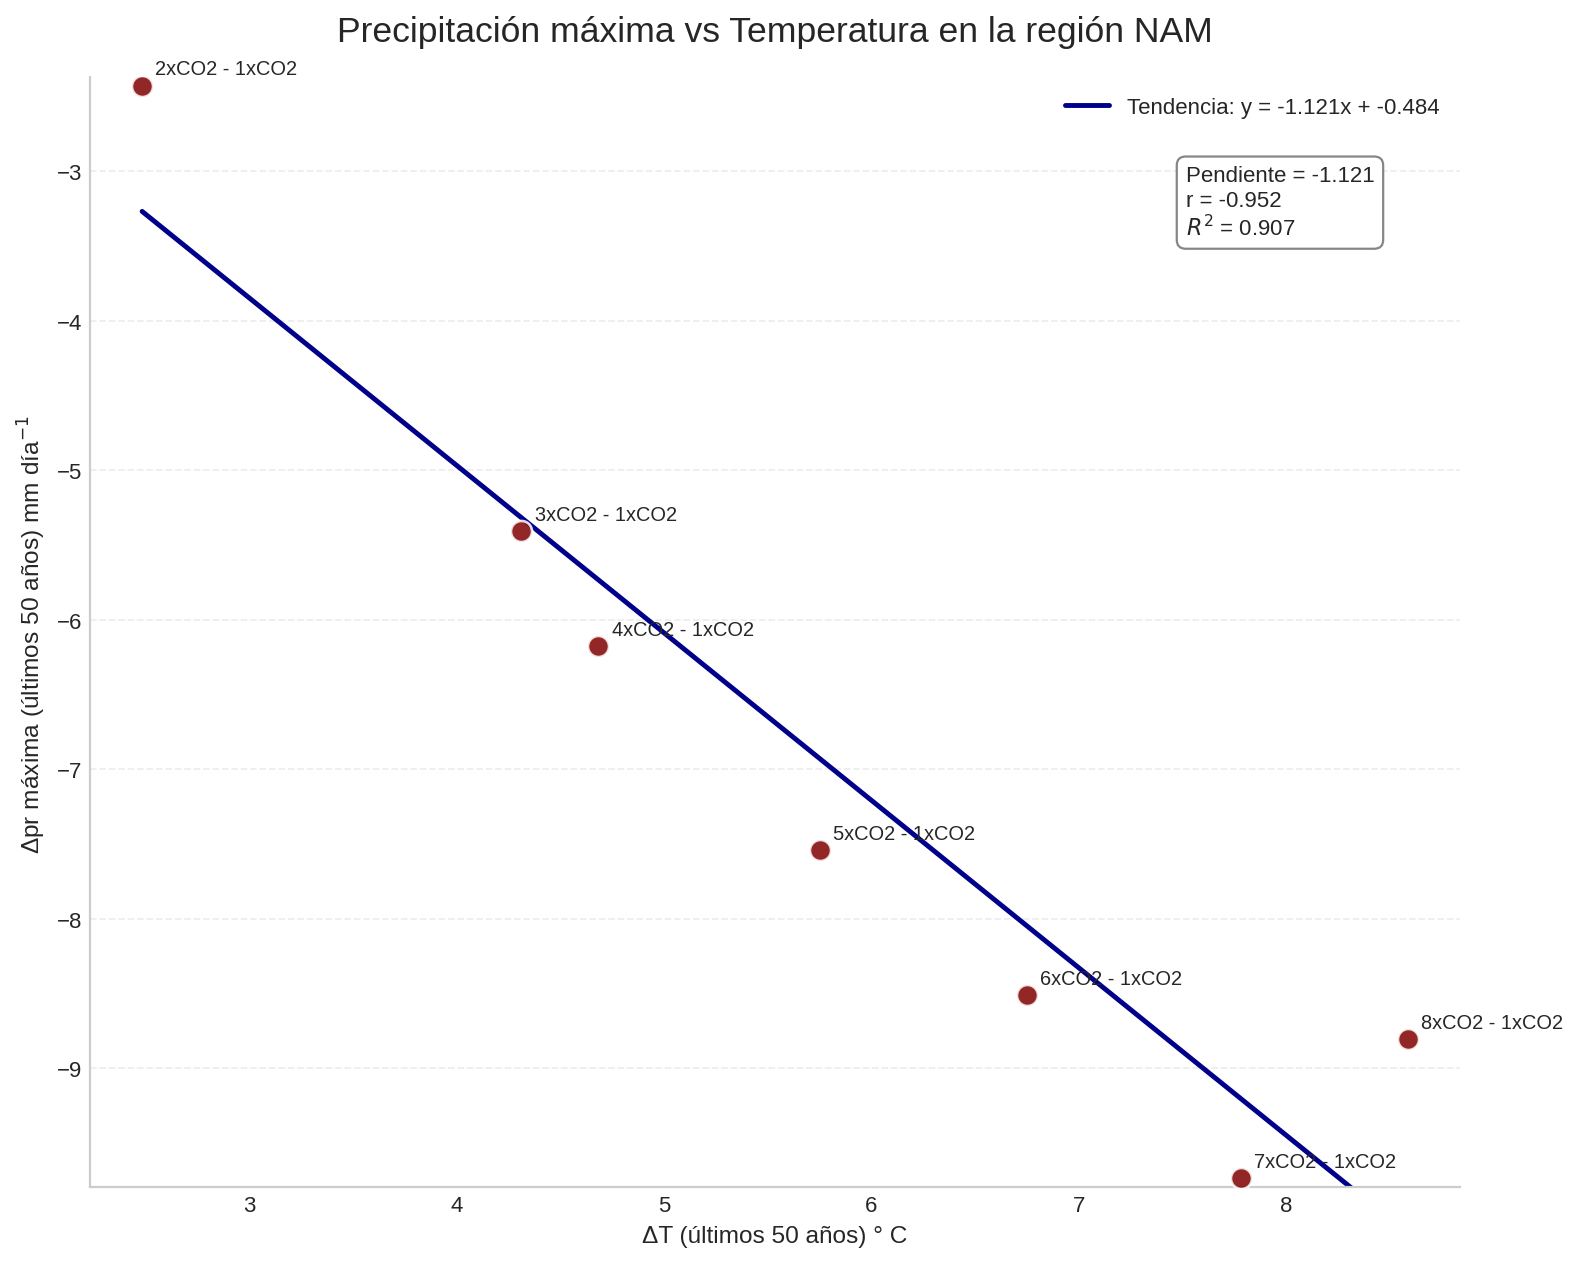

In [205]:
labels = [
    "2xCO2 - 1xCO2",
    "3xCO2 - 1xCO2",
    "4xCO2 - 1xCO2",
    "5xCO2 - 1xCO2",
    "6xCO2 - 1xCO2",
    "7xCO2 - 1xCO2",
    "8xCO2 - 1xCO2"
]

delta_T = np.array([float(d.mean()) for d in DIF_tem])
delta_pr_max = np.array([float(d.mean()) for d in DIFERENCIAS_PRECIP_MAX_jja])

# Ajuste lineal
m, b = np.polyfit(delta_T, delta_pr_max, 1)
x_line = np.linspace(delta_T.min(), delta_T.max(), 200)
y_line = m * x_line + b

# Correlación
r = np.corrcoef(delta_T,delta_pr_max )[0, 1]
r2 = r**2

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 8), dpi=160)

ax.scatter(
    delta_T, delta_pr_max,
    s=90,
    color="maroon",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.85,
    zorder=3
)



for lab, x, y in zip(labels, delta_T, delta_pr_max):
    ax.annotate(lab, (x, y), xytext=(6, 5), textcoords="offset points", fontsize=9)

ax.plot(
    x_line, y_line,
    "-",
    linewidth=2.2,
    color="darkblue",
    label=f"Tendencia: y = {m:.3f}x + {b:.3f}",
    zorder=2
)



ax.text(
    0.8, 0.92,
    f"Pendiente = {m:.3f}\nr = {r:.3f}\n$R^2$ = {r2:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4",facecolor="white", edgecolor="gray", alpha=0.95)
)

ax.set_title("Precipitación máxima vs Temperatura en la región NAM",
                fontsize=16,
    weight="light",
    pad=16)

ax.set_xlabel("ΔT (últimos 50 años) ° C",fontsize=11)
ax.set_ylabel("Δpr máxima (últimos 50 años) mm día$^{-1}$ ",fontsize=11)


# Rejilla y bordes
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Márgenes
x_pad = 0.25
y_pad = 0.06
ax.set_xlim(delta_T.min() - x_pad, delta_T.max() + x_pad)
ax.set_ylim(delta_pr_max.min() - y_pad, delta_pr_max.max() + y_pad)

ax.legend(frameon=False, loc="upper right", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.savefig('Imagenes/GraficaDispersion_precipitacion_max_vs_temperatura_50años.png', dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()